In [ ]:
import os

# --- Local paths: set these env vars, or edit the fallback strings ---
PROJECT_DIR = os.environ.get("PA_FLOOD_PROJECT", r"C:\path\to\PA Flood Risk GIS")
DATA_DIR    = os.environ.get("PA_FLOOD_DATA",    r"C:\path\to\Final Project\Data")

PROJECT_GDB = os.path.join(PROJECT_DIR, "PA Flood Risk GIS.gdb")
OUTPUT_DIR  = PROJECT_DIR


# Setup 

In [1]:
# Core libraries for the current hydrology workflow

import arcpy
import pandas as pd
import numpy as np

from collections import deque, Counter

In [2]:
# Minimal path and dataset setup for the current workflow

gdb_main = PROJECT_GDB
gdb_nhd = os.path.join(DATA_DIR, "nhdplus_epasnapshot2022_pa.gdb")

substations_fc = f"{gdb_main}\\PA_substations_statewide_clean_2272"
substations_nhd_fc = f"{gdb_main}\\substations_with_nhdflowline"

all_gages_2272 = f"{gdb_main}\\all_gages_with_nhdflowline"
peak_gages_fc = f"{gdb_main}\\peak_flow_gages"
peak_gages_dedup8_fc = f"{gdb_main}\\peak_flow_gages_dedup8"

flowline_2272 = f"{gdb_main}\\nhdflowline_pa_2272"
vaa_tbl = f"{gdb_nhd}\\nhdplusflowlinevaa_pa"
plusflow_tbl = f"{gdb_nhd}\\nhdplusflow_pa"

arcpy.env.workspace = gdb_main

print("Workspace:", arcpy.env.workspace)

for dataset_name in [
    substations_fc,
    substations_nhd_fc,
    all_gages_2272,
    peak_gages_fc,
    peak_gages_dedup8_fc,
    flowline_2272,
    vaa_tbl,
    plusflow_tbl
]:
    print(dataset_name, "exists:", arcpy.Exists(dataset_name))

Workspace: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_statewide_clean_2272 exists: True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_nhdflowline exists: True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\all_gages_with_nhdflowline exists: True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\peak_flow_gages exists: True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\peak_flow_gages_dedup8 exists: True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\nhdflowline_pa_2272 exists: True
C:\Users\Owner\Downloads\Geospatial Data Science\Final Project\Data\nhdplus_epasnapshot2022_pa.gdb\nhdplusflowlinevaa_pa exists: True
C:\Users\Owner\Downloads\Geospatial Data Science\Final Proj

In [3]:
# Ensure VAA attributes are available on flowline_2272

flowline_fields_lower = [field.name.lower() for field in arcpy.ListFields(flowline_2272)]

required_flowline_fields = ["nhdplusid", "totdasqkm", "hydroseq", "levelpathi"]

print("Flowline field presence before any repair:")
for field_name in required_flowline_fields:
    print(field_name, field_name.lower() in flowline_fields_lower)

if not all(field_name.lower() in flowline_fields_lower for field_name in required_flowline_fields):
    arcpy.management.JoinField(
        in_data=flowline_2272,
        in_field="nhdplusid",
        join_table=vaa_tbl,
        join_field="nhdplusid",
        fields=["totdasqkm", "hydroseq", "levelpathi"]
    )
    print("Joined VAA fields onto flowline_2272.")

flowline_fields_lower = [field.name.lower() for field in arcpy.ListFields(flowline_2272)]

print("Flowline field presence after repair:")
for field_name in required_flowline_fields:
    print(field_name, field_name.lower() in flowline_fields_lower)

with arcpy.da.SearchCursor(
    flowline_2272,
    ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi"]
) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

Flowline field presence before any repair:
nhdplusid True
totdasqkm True
hydroseq True
levelpathi True
Flowline field presence after repair:
nhdplusid True
totdasqkm True
hydroseq True
levelpathi True
(1, 10000200150839.0, 517.48630003, 10000200014861.0, 10000200014861.0)
(2, 10000200092578.0, 499.80299999000005, 10000200015011.0, 10000200015011.0)
(3, 10000200160627.0, 519.17690001, 10000200014727.0, 10000200014727.0)
(4, 10000200208717.0, 517.1611000500001, 10000200014705.0, 10000200014705.0)
(5, 10000200238163.0, 16159.60299617, 10000200004153.0, 10000200003747.0)
(6, 10000200238163.0, 16159.60299617, 10000200004153.0, 10000200003747.0)
(7, 10000200306365.0, 529.2086000400001, 10000200014260.0, 10000200013658.0)
(8, 10000200267171.0, 2.22909997, 10000200239809.0, 10000200219667.0)
(9, 10000200000072.0, 0.9746999900000001, 10000200229254.0, 10000200123833.0)
(10, 10000200019478.0, 3.8488999899999996, 10000200154754.0, 10000200119293.0)


In [4]:
# Ensure substations_nhd_fc carries the core attached flowline attributes

new_substation_fields = [
    ("flow_nhdpid", "DOUBLE"),
    ("flow_tdas", "DOUBLE"),
    ("flow_hseq", "DOUBLE"),
    ("flow_lpath", "DOUBLE")
]

existing_substation_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

for field_name, field_type in new_substation_fields:
    if field_name.lower() not in existing_substation_fields_lower:
        arcpy.management.AddField(substations_nhd_fc, field_name, field_type)
        print(f"Added field: {field_name}")

flowline_lookup = {}
lookup_fields = ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi"]

with arcpy.da.SearchCursor(flowline_2272, lookup_fields) as cursor:
    for objectid_value, nhdplusid_value, totdasqkm_value, hydroseq_value, levelpathi_value in cursor:
        flowline_lookup[objectid_value] = (
            nhdplusid_value,
            totdasqkm_value,
            hydroseq_value,
            levelpathi_value
        )

update_fields = ["NEAR_FID", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

updated_count = 0
missing_near_count = 0
missing_lookup_count = 0

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        near_fid_value = row[0]

        if near_fid_value in [None, -1]:
            missing_near_count += 1
            continue

        if near_fid_value not in flowline_lookup:
            missing_lookup_count += 1
            continue

        nhdplusid_value, totdasqkm_value, hydroseq_value, levelpathi_value = flowline_lookup[near_fid_value]

        row[1] = nhdplusid_value
        row[2] = totdasqkm_value
        row[3] = hydroseq_value
        row[4] = levelpathi_value
        cursor.updateRow(row)
        updated_count += 1

print("Updated substations:", updated_count)
print("Missing NEAR_FID:", missing_near_count)
print("Missing lookup:", missing_lookup_count)

Updated substations: 2333
Missing NEAR_FID: 0
Missing lookup: 0


In [66]:
# Diagnose which fields actually exist on peak_gages_dedup8_fc

print("Exists:", arcpy.Exists(peak_gages_dedup8_fc))
print("Path:", peak_gages_dedup8_fc)

peak_field_names = [field.name for field in arcpy.ListFields(peak_gages_dedup8_fc)]
print("Number of fields:", len(peak_field_names))

for field in arcpy.ListFields(peak_gages_dedup8_fc):
    print(field.name, "|", field.type, "|", field.length)

required_peak_fields = ["site_no_8", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

print("\nRequired field check:")
for field_name in required_peak_fields:
    print(field_name, "->", field_name in peak_field_names)

Exists: True
Path: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\peak_flow_gages_dedup8
Number of fields: 17
OBJECTID | OID | 8
geom | Geometry | 0
agency_cd | String | 2147483647
site_no | String | 2147483647
station_nm | String | 2147483647
site_tp_cd | String | 2147483647
dec_lat_va | Double | 8
dec_long_va | Double | 8
coord_acy_cd | String | 2147483647
dec_coord_datum_cd | String | 2147483647
alt_va | String | 2147483647
alt_acy_va | String | 2147483647
alt_datum_cd | String | 2147483647
huc_cd | String | 2147483647
NEAR_FID | Integer | 4
NEAR_DIST | Double | 8
site_no_8 | String | 8

Required field check:
site_no_8 -> True
flow_nhdpid -> False
flow_tdas -> False
flow_hseq -> False
flow_lpath -> False


In [15]:
# defining downstream traversal function
from collections import deque

def find_first_peak_downstream(start_nhdpid, downstream_graph, peak_nhdpid_set, stop_ids=None, max_steps=5000):
    if stop_ids is None:
        stop_ids = {0.0}

    if start_nhdpid in [None] or start_nhdpid in stop_ids:
        return None

    visited = {start_nhdpid}
    queue = deque([(start_nhdpid, 0)])

    while queue:
        current_nhdpid, step_count = queue.popleft()

        if step_count > 0 and current_nhdpid in peak_nhdpid_set:
            return {
                "matched_nhdpid": current_nhdpid,
                "steps": step_count
            }

        if step_count >= max_steps:
            continue

        for next_nhdpid in downstream_graph.get(current_nhdpid, []):
            if next_nhdpid in stop_ids:
                continue
            if next_nhdpid not in visited:
                visited.add(next_nhdpid)
                queue.append((next_nhdpid, step_count + 1))

    return None

### Fixing Substation Flowline Attachment

In [10]:
# Rebuild the correct substation -> nearest flowline attachment
# and store it in permanent fields so it cannot be overwritten later

flow_near_fields = [
    ("flow_near_fid", "LONG"),
    ("flow_near_dist", "DOUBLE")
]

existing_substation_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

for field_name, field_type in flow_near_fields:
    if field_name.lower() not in existing_substation_fields_lower:
        arcpy.management.AddField(substations_nhd_fc, field_name, field_type)
        print(f"Added field: {field_name}")
    else:
        print(f"Field already exists: {field_name}")

# Remove volatile NEAR fields before recomputing
volatile_near_fields = ["NEAR_FID", "NEAR_DIST", "NEAR_X", "NEAR_Y", "NEAR_ANGLE"]
existing_field_names = [field.name for field in arcpy.ListFields(substations_nhd_fc)]

for field_name in volatile_near_fields:
    if field_name in existing_field_names:
        arcpy.management.DeleteField(substations_nhd_fc, field_name)
        print(f"Deleted old volatile field: {field_name}")

# Recompute Near from substations to flowlines
arcpy.analysis.Near(
    in_features=substations_nhd_fc,
    near_features=flowline_2272,
    location="NO_LOCATION",
    angle="NO_ANGLE",
    method="PLANAR"
)

print("Recomputed Near from substations to flowline_2272.")

# Copy volatile Near outputs into permanent flow-specific fields
updated_count = 0

with arcpy.da.UpdateCursor(
    substations_nhd_fc,
    ["NEAR_FID", "NEAR_DIST", "flow_near_fid", "flow_near_dist"]
) as cursor:
    for row in cursor:
        row[2] = row[0]
        row[3] = row[1]
        cursor.updateRow(row)
        updated_count += 1

print("Copied Near outputs into flow_near_fid and flow_near_dist for rows:", updated_count)

Added field: flow_near_fid
Added field: flow_near_dist
Deleted old volatile field: NEAR_FID
Deleted old volatile field: NEAR_DIST
Recomputed Near from substations to flowline_2272.
Copied Near outputs into flow_near_fid and flow_near_dist for rows: 2333


In [11]:
check_fields = ["NEAR_FID", "NEAR_DIST", "flow_near_fid", "flow_near_dist"]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

(33649, 1462.0166041986222, 33649, 1462.0166041986222)
(118012, 205.8498762571168, 118012, 205.8498762571168)
(174511, 985.3664732395681, 174511, 985.3664732395681)
(59839, 284.15997219244406, 59839, 284.15997219244406)
(59839, 595.8488149881168, 59839, 595.8488149881168)
(214227, 2402.9431967228797, 214227, 2402.9431967228797)
(106923, 1244.4027031445469, 106923, 1244.4027031445469)
(201902, 1796.850638505034, 201902, 1796.850638505034)
(59839, 1157.3715163393092, 59839, 1157.3715163393092)
(174483, 1650.806556920805, 174483, 1650.806556920805)


In [6]:
# Refresh hydrologic attributes using the permanent flow_near_fid field

flowline_lookup = {}
lookup_fields = ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi"]

with arcpy.da.SearchCursor(flowline_2272, lookup_fields) as cursor:
    for objectid_value, nhdplusid_value, totdasqkm_value, hydroseq_value, levelpathi_value in cursor:
        flowline_lookup[objectid_value] = (
            nhdplusid_value,
            totdasqkm_value,
            hydroseq_value,
            levelpathi_value
        )

update_fields = ["flow_near_fid", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

updated_count = 0
missing_flow_near_count = 0
missing_lookup_count = 0

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        flow_near_fid_value = row[0]

        if flow_near_fid_value in [None, -1]:
            missing_flow_near_count += 1
            continue

        if flow_near_fid_value not in flowline_lookup:
            missing_lookup_count += 1
            continue

        nhdplusid_value, totdasqkm_value, hydroseq_value, levelpathi_value = flowline_lookup[flow_near_fid_value]

        row[1] = nhdplusid_value
        row[2] = totdasqkm_value
        row[3] = hydroseq_value
        row[4] = levelpathi_value
        cursor.updateRow(row)
        updated_count += 1

print("Updated substations:", updated_count)
print("Missing flow_near_fid:", missing_flow_near_count)
print("Missing lookup:", missing_lookup_count)

Updated substations: 2333
Missing flow_near_fid: 0
Missing lookup: 0


In [13]:
check_fields = ["flow_near_fid", "flow_near_dist", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

filled_tdas_count = 0
null_tdas_count = 0

with arcpy.da.SearchCursor(substations_nhd_fc, ["flow_tdas"]) as cursor:
    for (flow_tdas_value,) in cursor:
        if flow_tdas_value is None:
            null_tdas_count += 1
        else:
            filled_tdas_count += 1

print("Substations with flow_tdas:", filled_tdas_count)
print("Substations missing flow_tdas:", null_tdas_count)

(33649, 1462.0166041986222, 10000600064430.0, 3.6288, 10000600059294.0, 10000600010884.0)
(118012, 205.8498762571168, 10000500068904.0, 17.34599992, 10000500016136.0, 10000500009302.0)
(174511, 985.3664732395681, 10000600065093.0, 0.27309998, 10000600098786.0, 10000600068793.0)
(59839, 284.15997219244406, 10000500028084.0, 0.7784000200000001, 10000500083872.0, 10000500043933.0)
(59839, 595.8488149881168, 10000500028084.0, 0.7784000200000001, 10000500083872.0, 10000500043933.0)
(214227, 2402.9431967228797, 10000600109704.0, 14.8526, 10000600027757.0, 10000600025285.0)
(106923, 1244.4027031445469, 10000500092022.0, 0.5100999900000001, 10000500063822.0, 10000500063822.0)
(201902, 1796.850638505034, 10000600050208.0, 0.52520001, 10000600103136.0, 10000600103136.0)
(59839, 1157.3715163393092, 10000500028084.0, 0.7784000200000001, 10000500083872.0, 10000500043933.0)
(174483, 1650.806556920805, 10000600035936.0, 7.83769994, 10000600038512.0, 10000600024947.0)
Substations with flow_tdas: 2328


In [14]:
# Inspect substations whose attached flowline has missing hydrologic attributes

missing_substation_rows = []

check_fields = [
    "OBJECTID",
    "flow_near_fid",
    "flow_near_dist",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath"
]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row in cursor:
        objectid_value, flow_near_fid_value, flow_near_dist_value, flow_nhdpid_value, flow_tdas_value, flow_hseq_value, flow_lpath_value = row

        if flow_tdas_value is None:
            missing_substation_rows.append(row)

print("Number of substations with missing flow_tdas:", len(missing_substation_rows))

for row in missing_substation_rows:
    print(row)

Number of substations with missing flow_tdas: 5
(342, 214587, 70.20222777431489, 10000200233504.0, None, None, None)
(835, 204857, 2250.6368903319562, 10000600080252.0, None, None, None)
(920, 208726, 215.7891003547179, 10000600022697.0, None, None, None)
(1372, 207820, 815.6915325737033, 10000200097607.0, None, None, None)
(1934, 15387, 99.74922430351221, 10000200092151.0, None, None, None)


In [15]:
# Check the attached flowline records themselves for the missing cases

missing_flowline_ids = set()

with arcpy.da.SearchCursor(substations_nhd_fc, ["flow_near_fid", "flow_tdas"]) as cursor:
    for flow_near_fid_value, flow_tdas_value in cursor:
        if flow_tdas_value is None and flow_near_fid_value not in [None, -1]:
            missing_flowline_ids.add(flow_near_fid_value)

print("Missing flowline OBJECTIDs:", sorted(missing_flowline_ids))

flowline_check_fields = ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi"]

with arcpy.da.SearchCursor(flowline_2272, flowline_check_fields) as cursor:
    for row in cursor:
        if row[0] in missing_flowline_ids:
            print(row)

Missing flowline OBJECTIDs: [15387, 204857, 207820, 208726, 214587]
(15387, 10000200092151.0, None, None, None)
(204857, 10000600080252.0, None, None, None)
(207820, 10000200097607.0, None, None, None)
(208726, 10000600022697.0, None, None, None)
(214587, 10000200233504.0, None, None, None)


5 flowlines are missing key VAA-derived attributes. The substations attached to these flowlines will not be used in the branch logic

### Flowline and Summary Statistics

In [7]:
# Summarize the corrected flowline snap distance and usable drainage area

flow_near_dist_values = []
flow_tdas_values = []

with arcpy.da.SearchCursor(substations_nhd_fc, ["flow_near_dist", "flow_tdas"]) as cursor:
    for flow_near_dist_value, flow_tdas_value in cursor:
        if flow_near_dist_value is not None:
            flow_near_dist_values.append(flow_near_dist_value)
        if flow_tdas_value is not None:
            flow_tdas_values.append(flow_tdas_value)

print("flow_near_dist count:", len(flow_near_dist_values))
print("flow_near_dist min:", min(flow_near_dist_values))
print("flow_near_dist max:", max(flow_near_dist_values))
print("flow_near_dist mean:", sum(flow_near_dist_values) / len(flow_near_dist_values))

print("flow_tdas usable count:", len(flow_tdas_values))
print("flow_tdas min:", min(flow_tdas_values))
print("flow_tdas max:", max(flow_tdas_values))
print("flow_tdas mean:", sum(flow_tdas_values) / len(flow_tdas_values))

flow_near_dist count: 2333
flow_near_dist min: 3.9086003132550915
flow_near_dist max: 10171.33140771754
flow_near_dist mean: 1131.2020571209166
flow_tdas usable count: 2328
flow_tdas min: 0.0
flow_tdas max: 66747.09929476
flow_tdas mean: 1829.3852195674526


In [11]:
# Build clean substation records for the downstream-matching branch only

substation_records = []

fields = ["OBJECTID", "flow_near_dist", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

excluded_missing_hydro_count = 0

with arcpy.da.SearchCursor(substations_nhd_fc, fields) as cursor:
    for objectid_value, flow_near_dist_value, flow_nhdpid_value, flow_tdas_value, flow_hseq_value, flow_lpath_value in cursor:
        if (
            flow_nhdpid_value is None
            or flow_tdas_value is None
            or flow_hseq_value is None
            or flow_lpath_value is None
        ):
            excluded_missing_hydro_count += 1
            continue

        substation_records.append({
            "substation_oid": objectid_value,
            "flow_near_dist": flow_near_dist_value,
            "flow_nhdpid": flow_nhdpid_value,
            "flow_tdas": flow_tdas_value,
            "flow_hseq": flow_hseq_value,
            "flow_lpath": flow_lpath_value
        })

print("Substation records loaded:", len(substation_records))
print("Excluded for missing hydrologic fields:", excluded_missing_hydro_count)

for row_index, record in enumerate(substation_records, start=1):
    print(record)
    if row_index >= 10:
        break

Substation records loaded: 2328
Excluded for missing hydrologic fields: 5
{'substation_oid': 1, 'flow_near_dist': 1462.0166041986222, 'flow_nhdpid': 10000600064430.0, 'flow_tdas': 3.6288, 'flow_hseq': 10000600059294.0, 'flow_lpath': 10000600010884.0}
{'substation_oid': 2, 'flow_near_dist': 205.8498762571168, 'flow_nhdpid': 10000500068904.0, 'flow_tdas': 17.34599992, 'flow_hseq': 10000500016136.0, 'flow_lpath': 10000500009302.0}
{'substation_oid': 3, 'flow_near_dist': 985.3664732395681, 'flow_nhdpid': 10000600065093.0, 'flow_tdas': 0.27309998, 'flow_hseq': 10000600098786.0, 'flow_lpath': 10000600068793.0}
{'substation_oid': 4, 'flow_near_dist': 284.15997219244406, 'flow_nhdpid': 10000500028084.0, 'flow_tdas': 0.7784000200000001, 'flow_hseq': 10000500083872.0, 'flow_lpath': 10000500043933.0}
{'substation_oid': 5, 'flow_near_dist': 595.8488149881168, 'flow_nhdpid': 10000500028084.0, 'flow_tdas': 0.7784000200000001, 'flow_hseq': 10000500083872.0, 'flow_lpath': 10000500043933.0}
{'substatio

### Attach Peak Gages to Flowlines

In [12]:
# Rebuild the correct peak_gages_dedup8_fc -> nearest flowline attachment
# and store it in permanent fields

peak_flow_near_fields = [
    ("peak_flow_near_fid", "LONG"),
    ("peak_flow_near_dist", "DOUBLE")
]

existing_peak_fields_lower = [field.name.lower() for field in arcpy.ListFields(peak_gages_dedup8_fc)]

for field_name, field_type in peak_flow_near_fields:
    if field_name.lower() not in existing_peak_fields_lower:
        arcpy.management.AddField(peak_gages_dedup8_fc, field_name, field_type)
        print(f"Added field: {field_name}")
    else:
        print(f"Field already exists: {field_name}")

# Remove volatile Near fields before recomputing
volatile_near_fields = ["NEAR_FID", "NEAR_DIST", "NEAR_X", "NEAR_Y", "NEAR_ANGLE"]
existing_field_names = [field.name for field in arcpy.ListFields(peak_gages_dedup8_fc)]

for field_name in volatile_near_fields:
    if field_name in existing_field_names:
        arcpy.management.DeleteField(peak_gages_dedup8_fc, field_name)
        print(f"Deleted old volatile field: {field_name}")

# Recompute Near from peak gages to flowlines
arcpy.analysis.Near(
    in_features=peak_gages_dedup8_fc,
    near_features=flowline_2272,
    location="NO_LOCATION",
    angle="NO_ANGLE",
    method="PLANAR"
)

print("Recomputed Near from peak_gages_dedup8_fc to flowline_2272.")

# Copy volatile Near outputs into permanent peak-flow-specific fields
updated_count = 0

with arcpy.da.UpdateCursor(
    peak_gages_dedup8_fc,
    ["NEAR_FID", "NEAR_DIST", "peak_flow_near_fid", "peak_flow_near_dist"]
) as cursor:
    for row in cursor:
        row[2] = row[0]
        row[3] = row[1]
        cursor.updateRow(row)
        updated_count += 1

print("Copied Near outputs into peak_flow_near_fid and peak_flow_near_dist for rows:", updated_count)

Field already exists: peak_flow_near_fid
Field already exists: peak_flow_near_dist
Deleted old volatile field: NEAR_FID
Deleted old volatile field: NEAR_DIST
Recomputed Near from peak_gages_dedup8_fc to flowline_2272.
Copied Near outputs into peak_flow_near_fid and peak_flow_near_dist for rows: 209


In [13]:
#Previous Cell Check

check_fields = ["NEAR_FID", "NEAR_DIST", "peak_flow_near_fid", "peak_flow_near_dist"]

with arcpy.da.SearchCursor(peak_gages_dedup8_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

(20231, 17.612564360973746, 20231, 17.612564360973746)
(59723, 277.2480287407884, 59723, 277.2480287407884)
(26093, 32.8079313256035, 26093, 32.8079313256035)
(15196, 119.35703880100155, 15196, 119.35703880100155)
(26456, 327.9188707519647, 26456, 327.9188707519647)
(20661, 256.83681567563934, 20661, 256.83681567563934)
(29015, 2268.3571955780817, 29015, 2268.3571955780817)
(208038, 48.39039565288455, 208038, 48.39039565288455)
(53824, 100.2586054818808, 53824, 100.2586054818808)
(47228, 100.22141234429252, 47228, 100.22141234429252)


In [8]:
# Refresh hydrologic attributes on peak_gages_dedup8_fc
# using the permanent peak_flow_near_fid field

flowline_lookup = {}
lookup_fields = ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi"]

with arcpy.da.SearchCursor(flowline_2272, lookup_fields) as cursor:
    for objectid_value, nhdplusid_value, totdasqkm_value, hydroseq_value, levelpathi_value in cursor:
        flowline_lookup[objectid_value] = (
            nhdplusid_value,
            totdasqkm_value,
            hydroseq_value,
            levelpathi_value
        )

update_fields = ["peak_flow_near_fid", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

updated_count = 0
missing_peak_flow_near_count = 0
missing_lookup_count = 0

with arcpy.da.UpdateCursor(peak_gages_dedup8_fc, update_fields) as cursor:
    for row in cursor:
        peak_flow_near_fid_value = row[0]

        if peak_flow_near_fid_value in [None, -1]:
            missing_peak_flow_near_count += 1
            continue

        if peak_flow_near_fid_value not in flowline_lookup:
            missing_lookup_count += 1
            continue

        nhdplusid_value, totdasqkm_value, hydroseq_value, levelpathi_value = flowline_lookup[peak_flow_near_fid_value]

        row[1] = nhdplusid_value
        row[2] = totdasqkm_value
        row[3] = hydroseq_value
        row[4] = levelpathi_value
        cursor.updateRow(row)
        updated_count += 1

print("Updated peak gages:", updated_count)
print("Missing peak_flow_near_fid:", missing_peak_flow_near_count)
print("Missing lookup:", missing_lookup_count)

Updated peak gages: 209
Missing peak_flow_near_fid: 0
Missing lookup: 0


In [28]:
# previous cell check
check_fields = [
    "site_no_8",
    "peak_flow_near_fid",
    "peak_flow_near_dist",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath"
]

with arcpy.da.SearchCursor(peak_gages_dedup8_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

filled_tdas_count = 0
null_tdas_count = 0

with arcpy.da.SearchCursor(peak_gages_dedup8_fc, ["flow_tdas"]) as cursor:
    for (flow_tdas_value,) in cursor:
        if flow_tdas_value is None:
            null_tdas_count += 1
        else:
            filled_tdas_count += 1

print("Peak gages with flow_tdas:", filled_tdas_count)
print("Peak gages missing flow_tdas:", null_tdas_count)

('01427650', 20231, 17.612564360973746, 10000200246982.0, 17.59749999, 10000200075700.0, 10000200035646.0)
('01430000', 59723, 277.2480287407884, 10000200265480.0, 395.59530007, 10000200019069.0, 10000200010090.0)
('01431000', 26093, 32.8079313256035, 10000200110711.0, 178.76599991999998, 10000200019920.0, 10000200018848.0)
('01431500', 15196, 119.35703880100155, 10000200237077.0, 684.3096999, 10000200015718.0, 10000200010090.0)
('01431680', 26456, 327.9188707519647, 10000200022544.0, 12.172899970000001, 10000200082467.0, 10000200077084.0)
('01432110', 20661, 256.83681567563934, 10000200160586.0, 1425.11520015, 10000200010274.0, 10000200010090.0)
('01434000', 29015, 2268.3571955780817, 10000200288683.0, 7730.720198499999, 10000200005041.0, 10000200003747.0)
('01440485', 208038, 48.39039565288455, 10000200255399.0, 17.51080009, 10000200107438.0, 10000200074700.0)
('01441495', 53824, 100.2586054818808, 10000200058194.0, 97.83489977, 10000200036333.0, 10000200030841.0)
('01446600', 47228,

In [9]:
# Rebuild corrected peak-gage records and lookup objects
# from the refreshed peak_gages_dedup8_fc branch

peak_gage_records = []
peak_nhdpid_set = set()
peak_nhdpid_to_record = {}

peak_fields = [
    "site_no_8",
    "peak_flow_near_dist",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath"
]

with arcpy.da.SearchCursor(peak_gages_dedup8_fc, peak_fields) as cursor:
    for site_no_8_value, peak_flow_near_dist_value, flow_nhdpid_value, flow_tdas_value, flow_hseq_value, flow_lpath_value in cursor:
        if site_no_8_value in [None, ""]:
            continue

        record = {
            "site_no_8": site_no_8_value,
            "peak_flow_near_dist": peak_flow_near_dist_value,
            "flow_nhdpid": flow_nhdpid_value,
            "flow_tdas": flow_tdas_value,
            "flow_hseq": flow_hseq_value,
            "flow_lpath": flow_lpath_value
        }

        peak_gage_records.append(record)

        if flow_nhdpid_value is not None:
            peak_nhdpid_set.add(flow_nhdpid_value)
            peak_nhdpid_to_record[flow_nhdpid_value] = record

print("Peak gage records rebuilt:", len(peak_gage_records))
print("Unique peak nhdplusid values:", len(peak_nhdpid_set))

for row_index, record in enumerate(peak_gage_records, start=1):
    print(record)
    if row_index >= 10:
        break

Peak gage records rebuilt: 209
Unique peak nhdplusid values: 209
{'site_no_8': '01427650', 'peak_flow_near_dist': 17.612564360973746, 'flow_nhdpid': 10000200246982.0, 'flow_tdas': 17.59749999, 'flow_hseq': 10000200075700.0, 'flow_lpath': 10000200035646.0}
{'site_no_8': '01430000', 'peak_flow_near_dist': 277.2480287407884, 'flow_nhdpid': 10000200265480.0, 'flow_tdas': 395.59530007, 'flow_hseq': 10000200019069.0, 'flow_lpath': 10000200010090.0}
{'site_no_8': '01431000', 'peak_flow_near_dist': 32.8079313256035, 'flow_nhdpid': 10000200110711.0, 'flow_tdas': 178.76599991999998, 'flow_hseq': 10000200019920.0, 'flow_lpath': 10000200018848.0}
{'site_no_8': '01431500', 'peak_flow_near_dist': 119.35703880100155, 'flow_nhdpid': 10000200237077.0, 'flow_tdas': 684.3096999, 'flow_hseq': 10000200015718.0, 'flow_lpath': 10000200010090.0}
{'site_no_8': '01431680', 'peak_flow_near_dist': 327.9188707519647, 'flow_nhdpid': 10000200022544.0, 'flow_tdas': 12.172899970000001, 'flow_hseq': 10000200082467.0, '

### Downstream Matching

In [17]:
# Rebuild minimal in-memory objects for the corrected workflow

downstream_graph = {}

with arcpy.da.SearchCursor(plusflow_tbl, ["fromnhdpid", "tonhdpid"]) as cursor:
    for from_id, to_id in cursor:
        if from_id is None or to_id is None:
            continue

        if from_id not in downstream_graph:
            downstream_graph[from_id] = []
        downstream_graph[from_id].append(to_id)

peak_gage_records = []
peak_nhdpid_set = set()
peak_nhdpid_to_record = {}

peak_fields = [
    "site_no_8",
    "peak_flow_near_dist",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath"
]

with arcpy.da.SearchCursor(peak_gages_dedup8_fc, peak_fields) as cursor:
    for site_no_8_value, peak_flow_near_dist_value, flow_nhdpid_value, flow_tdas_value, flow_hseq_value, flow_lpath_value in cursor:
        if site_no_8_value in [None, ""]:
            continue

        record = {
            "site_no_8": site_no_8_value,
            "peak_flow_near_dist": peak_flow_near_dist_value,
            "flow_nhdpid": flow_nhdpid_value,
            "flow_tdas": flow_tdas_value,
            "flow_hseq": flow_hseq_value,
            "flow_lpath": flow_lpath_value
        }

        peak_gage_records.append(record)

        if flow_nhdpid_value is not None:
            peak_nhdpid_set.add(flow_nhdpid_value)
            peak_nhdpid_to_record[flow_nhdpid_value] = record

print("Downstream graph nodes:", len(downstream_graph))
print("Peak gage records rebuilt:", len(peak_gage_records))
print("Unique peak nhdplusid values:", len(peak_nhdpid_set))

Downstream graph nodes: 215658
Peak gage records rebuilt: 209
Unique peak nhdplusid values: 209


In [18]:
# Rerun downstream matching using the corrected peak-gage lookup

substation_match_results = []

matched_count = 0
unmatched_count = 0

for sub_record in substation_records:
    start_nhdpid = sub_record["flow_nhdpid"]

    result = find_first_peak_downstream(
        start_nhdpid=start_nhdpid,
        downstream_graph=downstream_graph,
        peak_nhdpid_set=peak_nhdpid_set,
        stop_ids={0.0},
        max_steps=5000
    )

    result_record = {
        "substation_oid": sub_record["substation_oid"],
        "flow_near_dist": sub_record["flow_near_dist"],
        "flow_nhdpid": sub_record["flow_nhdpid"],
        "flow_tdas": sub_record["flow_tdas"],
        "flow_hseq": sub_record["flow_hseq"],
        "flow_lpath": sub_record["flow_lpath"],
        "matched_nhdpid": None,
        "matched_site_no_8": None,
        "matched_flow_tdas": None,
        "matched_flow_hseq": None,
        "matched_flow_lpath": None,
        "steps_downstream": None
    }

    if result is not None:
        matched_nhdpid = result["matched_nhdpid"]
        peak_record = peak_nhdpid_to_record.get(matched_nhdpid)

        result_record["matched_nhdpid"] = matched_nhdpid
        result_record["steps_downstream"] = result["steps"]

        if peak_record is not None:
            result_record["matched_site_no_8"] = peak_record["site_no_8"]
            result_record["matched_flow_tdas"] = peak_record["flow_tdas"]
            result_record["matched_flow_hseq"] = peak_record["flow_hseq"]
            result_record["matched_flow_lpath"] = peak_record["flow_lpath"]

        matched_count += 1
    else:
        unmatched_count += 1

    substation_match_results.append(result_record)

print("Usable substations processed:", len(substation_match_results))
print("Matched downstream:", matched_count)
print("Unmatched downstream:", unmatched_count)

for row_index, result_record in enumerate(substation_match_results, start=1):
    print(result_record)
    if row_index >= 10:
        break

matched_step_values = [
    result_record["steps_downstream"]
    for result_record in substation_match_results
    if result_record["steps_downstream"] is not None
]

if matched_step_values:
    print("Minimum downstream steps:", min(matched_step_values))
    print("Maximum downstream steps:", max(matched_step_values))
    print("Mean downstream steps:", sum(matched_step_values) / len(matched_step_values))
else:
    print("No downstream matches found.")

Usable substations processed: 2328
Matched downstream: 1504
Unmatched downstream: 824
{'substation_oid': 1, 'flow_near_dist': 1462.0166041986222, 'flow_nhdpid': 10000600064430.0, 'flow_tdas': 3.6288, 'flow_hseq': 10000600059294.0, 'flow_lpath': 10000600010884.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None}
{'substation_oid': 2, 'flow_near_dist': 205.8498762571168, 'flow_nhdpid': 10000500068904.0, 'flow_tdas': 17.34599992, 'flow_hseq': 10000500016136.0, 'flow_lpath': 10000500009302.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None}
{'substation_oid': 3, 'flow_near_dist': 985.3664732395681, 'flow_nhdpid': 10000600065093.0, 'flow_tdas': 0.27309998, 'flow_hseq': 10000600098786.0, 'flow_lpath': 10000600068793.0, 'matched_nhdpid': 10000600094990.0, 'matched_site_no_8': '

In [19]:
# Build usable substation records from the corrected flowline attachment

substation_records = []

fields = ["OBJECTID", "flow_near_dist", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath"]

excluded_missing_hydro_count = 0

with arcpy.da.SearchCursor(substations_nhd_fc, fields) as cursor:
    for objectid_value, flow_near_dist_value, flow_nhdpid_value, flow_tdas_value, flow_hseq_value, flow_lpath_value in cursor:
        if (
            flow_nhdpid_value is None
            or flow_tdas_value is None
            or flow_hseq_value is None
            or flow_lpath_value is None
        ):
            excluded_missing_hydro_count += 1
            continue

        substation_records.append({
            "substation_oid": objectid_value,
            "flow_near_dist": flow_near_dist_value,
            "flow_nhdpid": flow_nhdpid_value,
            "flow_tdas": flow_tdas_value,
            "flow_hseq": flow_hseq_value,
            "flow_lpath": flow_lpath_value
        })

print("Substation records loaded:", len(substation_records))
print("Excluded for missing hydrologic fields:", excluded_missing_hydro_count)

Substation records loaded: 2328
Excluded for missing hydrologic fields: 5


In [20]:
# Match each usable substation to the first downstream peak-flow gage

substation_match_results = []

matched_count = 0
unmatched_count = 0

for sub_record in substation_records:
    start_nhdpid = sub_record["flow_nhdpid"]

    result = find_first_peak_downstream(
        start_nhdpid=start_nhdpid,
        downstream_graph=downstream_graph,
        peak_nhdpid_set=peak_nhdpid_set,
        stop_ids={0.0},
        max_steps=5000
    )

    result_record = {
        "substation_oid": sub_record["substation_oid"],
        "flow_near_dist": sub_record["flow_near_dist"],
        "flow_nhdpid": sub_record["flow_nhdpid"],
        "flow_tdas": sub_record["flow_tdas"],
        "flow_hseq": sub_record["flow_hseq"],
        "flow_lpath": sub_record["flow_lpath"],
        "matched_nhdpid": None,
        "matched_site_no_8": None,
        "matched_flow_tdas": None,
        "matched_flow_hseq": None,
        "matched_flow_lpath": None,
        "steps_downstream": None
    }

    if result is not None:
        matched_nhdpid = result["matched_nhdpid"]
        peak_record = peak_nhdpid_to_record.get(matched_nhdpid)

        result_record["matched_nhdpid"] = matched_nhdpid
        result_record["steps_downstream"] = result["steps"]

        if peak_record is not None:
            result_record["matched_site_no_8"] = peak_record["site_no_8"]
            result_record["matched_flow_tdas"] = peak_record["flow_tdas"]
            result_record["matched_flow_hseq"] = peak_record["flow_hseq"]
            result_record["matched_flow_lpath"] = peak_record["flow_lpath"]

        matched_count += 1
    else:
        unmatched_count += 1

    substation_match_results.append(result_record)

print("Usable substations processed:", len(substation_match_results))
print("Matched downstream:", matched_count)
print("Unmatched downstream:", unmatched_count)

matched_step_values = [
    result_record["steps_downstream"]
    for result_record in substation_match_results
    if result_record["steps_downstream"] is not None
]

if matched_step_values:
    print("Minimum downstream steps:", min(matched_step_values))
    print("Maximum downstream steps:", max(matched_step_values))
    print("Mean downstream steps:", sum(matched_step_values) / len(matched_step_values))
else:
    print("No downstream matches found.")

Usable substations processed: 2328
Matched downstream: 1504
Unmatched downstream: 824
Minimum downstream steps: 1
Maximum downstream steps: 340
Mean downstream steps: 45.00066489361702


In [34]:
# Quick inspection of matching output

for row_index, result_record in enumerate(substation_match_results, start=1):
    print(result_record)
    if row_index >= 10:
        break

{'substation_oid': 1, 'flow_near_dist': 1462.0166041986222, 'flow_nhdpid': 10000600064430.0, 'flow_tdas': 3.6288, 'flow_hseq': 10000600059294.0, 'flow_lpath': 10000600010884.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None}
{'substation_oid': 2, 'flow_near_dist': 205.8498762571168, 'flow_nhdpid': 10000500068904.0, 'flow_tdas': 17.34599992, 'flow_hseq': 10000500016136.0, 'flow_lpath': 10000500009302.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None}
{'substation_oid': 3, 'flow_near_dist': 985.3664732395681, 'flow_nhdpid': 10000600065093.0, 'flow_tdas': 0.27309998, 'flow_hseq': 10000600098786.0, 'flow_lpath': 10000600068793.0, 'matched_nhdpid': 10000600094990.0, 'matched_site_no_8': '01573825', 'matched_flow_tdas': 537.82159996, 'matched_flow_hseq': 10000600006942.0, '

In [21]:
# Write corrected matching results back to substations_nhd_fc

match_fields_to_add = [
    ("match_site8", "TEXT", 8),
    ("match_nhdpid", "DOUBLE", None),
    ("match_steps", "LONG", None),
    ("match_type", "TEXT", 20)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

for field_name, field_type, field_length in match_fields_to_add:
    if field_name.lower() not in existing_fields_lower:
        if field_type == "TEXT":
            arcpy.management.AddField(substations_nhd_fc, field_name, field_type, field_length=field_length)
        else:
            arcpy.management.AddField(substations_nhd_fc, field_name, field_type)

substation_match_lookup = {
    record["substation_oid"]: record
    for record in substation_match_results
}

update_fields = [
    "OBJECTID",
    "flow_tdas",
    "match_site8",
    "match_nhdpid",
    "match_steps",
    "match_type"
]

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        objectid_value = row[0]
        flow_tdas_value = row[1]
        match_record = substation_match_lookup.get(objectid_value)

        row[2] = None
        row[3] = None
        row[4] = None
        row[5] = None

        if flow_tdas_value is None:
            row[5] = "missing_hydro"
        elif match_record is not None and match_record["matched_nhdpid"] is not None:
            row[2] = match_record["matched_site_no_8"]
            row[3] = match_record["matched_nhdpid"]
            row[4] = match_record["steps_downstream"]
            row[5] = "downstream_peak"
        else:
            row[5] = "unmatched"

        cursor.updateRow(row)

print("Finished writing corrected match results back to substations_nhd_fc.")

Finished writing corrected match results back to substations_nhd_fc.


In [22]:
from collections import Counter

match_type_counter = Counter()

with arcpy.da.SearchCursor(substations_nhd_fc, ["match_type"]) as cursor:
    for (match_type_value,) in cursor:
        match_type_counter[match_type_value] += 1

print("Match type counts:")
for key, value in match_type_counter.items():
    print(key, value)

check_fields = [
    "OBJECTID",
    "flow_near_dist",
    "flow_tdas",
    "match_site8",
    "match_nhdpid",
    "match_steps",
    "match_type"
]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

Match type counts:
unmatched 824
downstream_peak 1504
missing_hydro 5
(1, 1462.0166041986222, 3.6288, None, None, None, 'unmatched')
(2, 205.8498762571168, 17.34599992, None, None, None, 'unmatched')
(3, 985.3664732395681, 0.27309998, '01573825', 10000600094990.0, 35, 'downstream_peak')
(4, 284.15997219244406, 0.7784000200000001, None, None, None, 'unmatched')
(5, 595.8488149881168, 0.7784000200000001, None, None, None, 'unmatched')
(6, 2402.9431967228797, 14.8526, None, None, None, 'unmatched')
(7, 1244.4027031445469, 0.5100999900000001, None, None, None, 'unmatched')
(8, 1796.850638505034, 0.52520001, '01573825', 10000600094990.0, 40, 'downstream_peak')
(9, 1157.3715163393092, 0.7784000200000001, None, None, None, 'unmatched')
(10, 1650.806556920805, 7.83769994, '01573825', 10000600094990.0, 64, 'downstream_peak')
(11, 5.278489498386498, 1.83810001, None, None, None, 'unmatched')
(12, 458.49058316471167, 0.9927000100000001, None, None, None, 'unmatched')
(13, 288.94504272126284, 1.65

In [23]:
# Check whether peak_gages_dedup8_fc already contains a usable discharge field

for field in arcpy.ListFields(peak_gages_dedup8_fc):
    field_name_lower = field.name.lower()
    if (
        "peak" in field_name_lower
        or "flow" in field_name_lower
        or "discharge" in field_name_lower
        or "q" == field_name_lower
        or field_name_lower.startswith("q")
    ):
        print(field.name, "|", field.type, "|", field.length)

print("\nFirst 5 rows of all fields containing peak/flow/discharge/q:")
candidate_fields = [
    field.name
    for field in arcpy.ListFields(peak_gages_dedup8_fc)
    if (
        "peak" in field.name.lower()
        or "flow" in field.name.lower()
        or "discharge" in field.name.lower()
        or "q" == field.name.lower()
        or field.name.lower().startswith("q")
    )
]

print(candidate_fields)

if candidate_fields:
    with arcpy.da.SearchCursor(peak_gages_dedup8_fc, candidate_fields) as cursor:
        for row_index, row in enumerate(cursor, start=1):
            print(row)
            if row_index >= 5:
                break

flow_nhdpid | Double | 8
flow_tdas | Double | 8
flow_hseq | Double | 8
flow_lpath | Double | 8
peak_flow_near_fid | Integer | 4
peak_flow_near_dist | Double | 8

First 5 rows of all fields containing peak/flow/discharge/q:
['flow_nhdpid', 'flow_tdas', 'flow_hseq', 'flow_lpath', 'peak_flow_near_fid', 'peak_flow_near_dist']
(10000200246982.0, 17.59749999, 10000200075700.0, 10000200035646.0, 20231, 17.612564360973746)
(10000200265480.0, 395.59530007, 10000200019069.0, 10000200010090.0, 59723, 277.2480287407884)
(10000200110711.0, 178.76599991999998, 10000200019920.0, 10000200018848.0, 26093, 32.8079313256035)
(10000200237077.0, 684.3096999, 10000200015718.0, 10000200010090.0, 15196, 119.35703880100155)
(10000200022544.0, 12.172899970000001, 10000200082467.0, 10000200077084.0, 26456, 327.9188707519647)


In [24]:
# Load the peak-flow CSV and recreate peak_df_clean in this notebook

peak_csv_path = os.path.join(OUTPUT_DIR, "PA_peak_flow_data.csv")

peak_data = pd.read_csv(peak_csv_path, dtype={"site_no": str})

peak_data["site_no"] = peak_data["site_no"].astype(str).str.strip()
peak_data["peak_va"] = pd.to_numeric(peak_data["peak_va"], errors="coerce")

peak_df_clean = peak_data.dropna(subset=["peak_va"]).copy()
peak_df_clean = peak_df_clean[peak_df_clean["peak_va"] > 0].copy()

print("Rows in peak_data:", len(peak_data))
print("Rows in peak_df_clean:", len(peak_df_clean))
print("Unique gages in peak_df_clean:", peak_df_clean["site_no"].nunique())
print("Columns:")
print(list(peak_df_clean.columns))

Rows in peak_data: 9421
Rows in peak_df_clean: 9297
Unique gages in peak_df_clean: 209
Columns:
['agency_cd', 'site_no', 'peak_dt', 'peak_tm', 'peak_va', 'peak_cd', 'gage_ht', 'gage_ht_cd', 'year_last_pk', 'ag_dt', 'ag_tm', 'ag_gage_ht', 'ag_gage_ht_cd']


In [25]:
# Build a peak-flow lookup from the existing peak_df_clean dataframe
# using the maximum observed peak_va for each site_no_8

required_columns = ["site_no", "peak_va"]
missing_columns = [column_name for column_name in required_columns if column_name not in peak_df_clean.columns]

print("Missing required columns:", missing_columns)

peak_flow_df = peak_df_clean.copy()

peak_flow_df["site_no_8"] = (
    peak_flow_df["site_no"]
    .astype(str)
    .str.strip()
    .str[:8]
)

peak_flow_df["peak_va"] = pd.to_numeric(peak_flow_df["peak_va"], errors="coerce")

peak_flow_df = peak_flow_df.dropna(subset=["site_no_8", "peak_va"]).copy()
peak_flow_df = peak_flow_df[peak_flow_df["peak_va"] > 0].copy()

peak_flow_summary = (
    peak_flow_df
    .groupby("site_no_8", as_index=False)
    .agg(
        n_peak_records=("peak_va", "size"),
        peak_q_max=("peak_va", "max"),
        peak_q_mean=("peak_va", "mean")
    )
)

peak_flow_lookup = dict(
    zip(peak_flow_summary["site_no_8"], peak_flow_summary["peak_q_max"])
)

print("Unique site_no_8 in peak_flow_summary:", len(peak_flow_summary))
print("Lookup size:", len(peak_flow_lookup))

duplicate_site_count = int((peak_flow_summary["n_peak_records"] > 1).sum())
print("Sites with multiple peak records:", duplicate_site_count)

print("\nSample peak_flow_summary rows:")
print(peak_flow_summary.head(10))

Missing required columns: []
Unique site_no_8 in peak_flow_summary: 209
Lookup size: 209
Sites with multiple peak records: 204

Sample peak_flow_summary rows:
  site_no_8  n_peak_records  peak_q_max   peak_q_mean
0  01427650              20      1260.0    578.200000
1  01430000              72     34000.0   5165.416667
2  01431000              43     12000.0   3149.116279
3  01431500              97     51900.0   9274.742268
4  01431680              20       553.0    247.500000
5  01432110              18     25100.0  11142.222222
6  01434000             121    233000.0  65876.033058
7  01440485              24      3780.0   1185.583333
8  01441495              23      7120.0   2134.695652
9  01446600              26      1620.0    597.961538


In [26]:
# Check how many matched substations have a usable Q_gage value

matched_site8_values = []
missing_q_site8_values = []

for result_record in substation_match_results:
    matched_site_no_8_value = result_record["matched_site_no_8"]

    if matched_site_no_8_value is None:
        continue

    matched_site8_values.append(matched_site_no_8_value)

    if matched_site_no_8_value not in peak_flow_lookup:
        missing_q_site8_values.append(matched_site_no_8_value)

print("Matched substations with site_no_8 assigned:", len(matched_site8_values))
print("Matched site_no_8 values missing from peak_flow_lookup:", len(missing_q_site8_values))
print("Unique missing site_no_8 values:", len(set(missing_q_site8_values)))

print("\nFirst few missing site_no_8 values:")
print(sorted(set(missing_q_site8_values))[:20])

Matched substations with site_no_8 assigned: 1504
Matched site_no_8 values missing from peak_flow_lookup: 0
Unique missing site_no_8 values: 0

First few missing site_no_8 values:
[]


## Computing Scaled Discharge

Q_gage = peak_q_max \
A_sub = flow_tdas\
A_gage = matched_flow_tdas\
b = 0.8

In [27]:
# Compute drainage-area-scaled discharge for matched substations

b_exponent = 0.8

scaled_results = []

missing_q_count = 0
invalid_area_count = 0
scaled_count = 0

for result_record in substation_match_results:
    matched_site_no_8_value = result_record["matched_site_no_8"]
    a_sub_value = result_record["flow_tdas"]
    a_gage_value = result_record["matched_flow_tdas"]

    scaled_record = result_record.copy()
    scaled_record["q_gage"] = None
    scaled_record["a_sub"] = a_sub_value
    scaled_record["a_gage"] = a_gage_value
    scaled_record["b_exponent"] = b_exponent
    scaled_record["q_sub_scaled"] = None
    scaled_record["scale_ratio"] = None
    scaled_record["scaling_status"] = None

    if matched_site_no_8_value is None:
        scaled_record["scaling_status"] = "unmatched"
        scaled_results.append(scaled_record)
        continue

    if matched_site_no_8_value not in peak_flow_lookup:
        scaled_record["scaling_status"] = "missing_q"
        missing_q_count += 1
        scaled_results.append(scaled_record)
        continue

    q_gage_value = peak_flow_lookup[matched_site_no_8_value]
    scaled_record["q_gage"] = q_gage_value

    if (
        a_sub_value is None
        or a_gage_value is None
        or a_gage_value <= 0
        or a_sub_value < 0
    ):
        scaled_record["scaling_status"] = "invalid_area"
        invalid_area_count += 1
        scaled_results.append(scaled_record)
        continue

    scale_ratio_value = a_sub_value / a_gage_value
    q_sub_scaled_value = q_gage_value * (scale_ratio_value ** b_exponent)

    scaled_record["scale_ratio"] = scale_ratio_value
    scaled_record["q_sub_scaled"] = q_sub_scaled_value
    scaled_record["scaling_status"] = "scaled"

    scaled_count += 1
    scaled_results.append(scaled_record)

print("Total records in scaled_results:", len(scaled_results))
print("Scaled successfully:", scaled_count)
print("Missing q_gage:", missing_q_count)
print("Invalid area:", invalid_area_count)

for row_index, scaled_record in enumerate(scaled_results, start=1):
    print(scaled_record)
    if row_index >= 10:
        break

Total records in scaled_results: 2328
Scaled successfully: 1504
Missing q_gage: 0
Invalid area: 0
{'substation_oid': 1, 'flow_near_dist': 1462.0166041986222, 'flow_nhdpid': 10000600064430.0, 'flow_tdas': 3.6288, 'flow_hseq': 10000600059294.0, 'flow_lpath': 10000600010884.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None, 'q_gage': None, 'a_sub': 3.6288, 'a_gage': None, 'b_exponent': 0.8, 'q_sub_scaled': None, 'scale_ratio': None, 'scaling_status': 'unmatched'}
{'substation_oid': 2, 'flow_near_dist': 205.8498762571168, 'flow_nhdpid': 10000500068904.0, 'flow_tdas': 17.34599992, 'flow_hseq': 10000500016136.0, 'flow_lpath': 10000500009302.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None, 'q_gage': None, 'a_sub': 17.34599992, 'a_gage': None, 'b_exponent': 0.8, 'q_sub_scal

In [28]:
# Summarize the scaled subset only

q_sub_scaled_values = []
scale_ratio_values = []
q_gage_values = []

for scaled_record in scaled_results:
    if scaled_record["scaling_status"] == "scaled":
        q_sub_scaled_values.append(scaled_record["q_sub_scaled"])
        scale_ratio_values.append(scaled_record["scale_ratio"])
        q_gage_values.append(scaled_record["q_gage"])

print("Scaled records:", len(q_sub_scaled_values))

print("\nq_gage summary")
print("min:", min(q_gage_values))
print("max:", max(q_gage_values))
print("mean:", sum(q_gage_values) / len(q_gage_values))

print("\nscale_ratio = A_sub / A_gage summary")
print("min:", min(scale_ratio_values))
print("max:", max(scale_ratio_values))
print("mean:", sum(scale_ratio_values) / len(scale_ratio_values))

print("\nq_sub_scaled summary")
print("min:", min(q_sub_scaled_values))
print("max:", max(q_sub_scaled_values))
print("mean:", sum(q_sub_scaled_values) / len(q_sub_scaled_values))

Scaled records: 1504

q_gage summary
min: 28.0
max: 1080000.0
mean: 123102.37367021276

scale_ratio = A_sub / A_gage summary
min: 9.06339649609648e-07
max: 0.9998042601216685
mean: 0.14258012299705325

q_sub_scaled summary
min: 4.292402152029634
max: 616036.8556780734
mean: 18035.33198204458


### Identifying Likely Flooding Source for Q-Sub Scaled

In [31]:
# Attach likely flooding source waterbody fields from flowline_2272 to substations_nhd_fc

source_fields_to_add = [
    ("source_gnis", "TEXT", 255),
    ("source_reach", "TEXT", 20),
    ("source_ftype", "LONG", None),
    ("source_fcode", "LONG", None)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

for field_name, field_type, field_length in source_fields_to_add:
    if field_name.lower() not in existing_fields_lower:
        if field_type == "TEXT":
            arcpy.management.AddField(substations_nhd_fc, field_name, field_type, field_length=field_length)
        else:
            arcpy.management.AddField(substations_nhd_fc, field_name, field_type)
        print(f"Added field: {field_name}")
    else:
        print(f"Field already exists: {field_name}")

flowline_source_lookup = {}

lookup_fields = ["OBJECTID", "gnis_name", "reachcode", "ftype", "fcode"]

with arcpy.da.SearchCursor(flowline_2272, lookup_fields) as cursor:
    for objectid_value, gnis_name_value, reachcode_value, ftype_value, fcode_value in cursor:
        flowline_source_lookup[objectid_value] = (
            gnis_name_value,
            reachcode_value,
            ftype_value,
            fcode_value
        )

update_fields = [
    "flow_near_fid",
    "source_gnis",
    "source_reach",
    "source_ftype",
    "source_fcode"
]

updated_count = 0
missing_flow_near_count = 0
missing_lookup_count = 0

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        flow_near_fid_value = row[0]

        row[1] = None
        row[2] = None
        row[3] = None
        row[4] = None

        if flow_near_fid_value in [None, -1]:
            missing_flow_near_count += 1
            cursor.updateRow(row)
            continue

        if flow_near_fid_value not in flowline_source_lookup:
            missing_lookup_count += 1
            cursor.updateRow(row)
            continue

        gnis_name_value, reachcode_value, ftype_value, fcode_value = flowline_source_lookup[flow_near_fid_value]

        row[1] = gnis_name_value
        row[2] = reachcode_value
        row[3] = ftype_value
        row[4] = fcode_value

        cursor.updateRow(row)
        updated_count += 1

print("Updated substations with source waterbody fields:", updated_count)
print("Missing flow_near_fid:", missing_flow_near_count)
print("Missing lookup:", missing_lookup_count)

Added field: source_gnis
Added field: source_reach
Added field: source_ftype
Added field: source_fcode
Updated substations with source waterbody fields: 2333
Missing flow_near_fid: 0
Missing lookup: 0


In [33]:
# Quick verification of likely flooding source fields

check_fields = [
    "OBJECTID",
    "flow_near_fid",
    "source_gnis",
    "source_reach",
    "source_ftype",
    "source_fcode"
]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

named_count = 0
unnamed_count = 0

with arcpy.da.SearchCursor(substations_nhd_fc, ["source_gnis"]) as cursor:
    for (source_gnis_value,) in cursor:
        if source_gnis_value in [None, "", " "]:
            unnamed_count += 1
        else:
            named_count += 1

print("Substations attached to named flowlines:", named_count)
print("Substations attached to unnamed flowlines:", unnamed_count)

(1, 33649, 'Bermudian Creek', '02050306002107', 460, 46006)
(2, 118012, 'Alloway Creek', '02070009000218', 460, 46006)
(3, 174511, None, '02050306012397', 334, 33400)
(4, 59839, None, '02070009000805', 460, 46006)
(5, 59839, None, '02070009000805', 460, 46006)
(6, 214227, 'Beaver Creek', '02050306002098', 460, 46006)
(7, 106923, None, '02070009001265', 460, 46003)
(8, 201902, None, '02050306005580', 460, 46003)
(9, 59839, None, '02070009000805', 460, 46006)
(10, 174483, None, '02050306002048', 460, 46003)
(11, 211257, None, '02050306000709', 460, 46006)
(12, 32494, None, '02070009001626', 460, 46006)
(13, 151407, None, '02050306000599', 460, 46003)
(14, 107015, None, '02070009001311', 460, 46003)
(15, 116977, None, '02070009000793', 460, 46006)
Substations attached to named flowlines: 1214
Substations attached to unnamed flowlines: 1119


### Empirical Rarirty Context

In [34]:
# Build empirical rarity context for each scaled substation
# by comparing q_sub_scaled to the matched gage's peak-flow record

flood_analysis_valid = peak_df_clean.copy()

flood_analysis_valid["site_no_8"] = (
    flood_analysis_valid["site_no"]
    .astype(str)
    .str.strip()
    .str[:8]
)

flood_analysis_valid["peak_va"] = pd.to_numeric(flood_analysis_valid["peak_va"], errors="coerce")
flood_analysis_valid = flood_analysis_valid.dropna(subset=["site_no_8", "peak_va"]).copy()
flood_analysis_valid = flood_analysis_valid[flood_analysis_valid["peak_va"] > 0].copy()

# Store sorted peak series for each gage
gage_peak_series_lookup = {}

for site_no_8_value, group_df in flood_analysis_valid.groupby("site_no_8"):
    peak_values = sorted(group_df["peak_va"].tolist(), reverse=True)
    gage_peak_series_lookup[site_no_8_value] = peak_values

print("Gages in gage_peak_series_lookup:", len(gage_peak_series_lookup))

def empirical_rarity_context(q_value, peak_value_list):
    """
    Compare q_value to a gage's observed peak series.
    Returns empirical exceedance and return-period context.
    """
    n_obs_value = len(peak_value_list)

    if n_obs_value == 0 or q_value is None:
        return {
            "emp_exceed_prob": None,
            "emp_return_period": None,
            "rarity_status": "missing_series"
        }

    # Count how many observed peaks are >= q_value
    exceed_count_value = sum(1 for peak_value in peak_value_list if peak_value >= q_value)

    # If q_value exceeds all observed peaks, assign the rarest empirical category
    if exceed_count_value == 0:
        exceed_count_value = 1
        rarity_status_value = "above_observed_max"
    else:
        rarity_status_value = "within_observed_range"

    emp_exceed_prob_value = exceed_count_value / (n_obs_value + 1)
    emp_return_period_value = 1 / emp_exceed_prob_value

    return {
        "emp_exceed_prob": emp_exceed_prob_value,
        "emp_return_period": emp_return_period_value,
        "rarity_status": rarity_status_value
    }

rarity_results = []

rarity_computed_count = 0
rarity_missing_series_count = 0

for record in scaled_results:
    updated_record = record.copy()
    updated_record["emp_exceed_prob"] = None
    updated_record["emp_return_period"] = None
    updated_record["rarity_status"] = None

    matched_site_no_8_value = record["matched_site_no_8"]

    if record["scaling_status"] != "scaled":
        updated_record["rarity_status"] = "not_scaled"
        rarity_results.append(updated_record)
        continue

    if matched_site_no_8_value not in gage_peak_series_lookup:
        updated_record["rarity_status"] = "missing_series"
        rarity_missing_series_count += 1
        rarity_results.append(updated_record)
        continue

    rarity_output = empirical_rarity_context(
        q_value=record["q_sub_scaled"],
        peak_value_list=gage_peak_series_lookup[matched_site_no_8_value]
    )

    updated_record["emp_exceed_prob"] = rarity_output["emp_exceed_prob"]
    updated_record["emp_return_period"] = rarity_output["emp_return_period"]
    updated_record["rarity_status"] = rarity_output["rarity_status"]

    rarity_results.append(updated_record)
    rarity_computed_count += 1

print("Total records in rarity_results:", len(rarity_results))
print("Rarity computed:", rarity_computed_count)
print("Missing series:", rarity_missing_series_count)

for row_index, record in enumerate(rarity_results, start=1):
    print(record)
    if row_index >= 10:
        break

Gages in gage_peak_series_lookup: 209
Total records in rarity_results: 2328
Rarity computed: 1504
Missing series: 0
{'substation_oid': 1, 'flow_near_dist': 1462.0166041986222, 'flow_nhdpid': 10000600064430.0, 'flow_tdas': 3.6288, 'flow_hseq': 10000600059294.0, 'flow_lpath': 10000600010884.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_downstream': None, 'q_gage': None, 'a_sub': 3.6288, 'a_gage': None, 'b_exponent': 0.8, 'q_sub_scaled': None, 'scale_ratio': None, 'scaling_status': 'unmatched', 'emp_exceed_prob': None, 'emp_return_period': None, 'rarity_status': 'not_scaled'}
{'substation_oid': 2, 'flow_near_dist': 205.8498762571168, 'flow_nhdpid': 10000500068904.0, 'flow_tdas': 17.34599992, 'flow_hseq': 10000500016136.0, 'flow_lpath': 10000500009302.0, 'matched_nhdpid': None, 'matched_site_no_8': None, 'matched_flow_tdas': None, 'matched_flow_hseq': None, 'matched_flow_lpath': None, 'steps_do

In [36]:
# Summarize empirical rarity context for scaled substations only

emp_exceed_prob_values = [
    record["emp_exceed_prob"]
    for record in rarity_results
    if record["emp_exceed_prob"] is not None
]

emp_return_period_values = [
    record["emp_return_period"]
    for record in rarity_results
    if record["emp_return_period"] is not None
]

print("Empirical rarity count:", len(emp_exceed_prob_values))

print("\nemp_exceed_prob summary")
print("min:", min(emp_exceed_prob_values))
print("max:", max(emp_exceed_prob_values))
print("mean:", sum(emp_exceed_prob_values) / len(emp_exceed_prob_values))

print("\nemp_return_period summary")
print("min:", min(emp_return_period_values))
print("max:", max(emp_return_period_values))
print("mean:", sum(emp_return_period_values) / len(emp_return_period_values))

top_rare_records = sorted(
    [record for record in rarity_results if record["emp_return_period"] is not None],
    key=lambda record: record["emp_return_period"],
    reverse=True
)

print("\nTop 10 rare-context records:")
for record in top_rare_records[:10]:
    print(
        record["substation_oid"],
        record["q_sub_scaled"],
        record["emp_exceed_prob"],
        record["emp_return_period"],
        record["matched_site_no_8"],
        record["steps_downstream"],
        record["flow_near_dist"]
    )

Empirical rarity count: 1504

emp_exceed_prob summary
min: 0.007142857142857143
max: 0.9928571428571429
mean: 0.7967415313967763

emp_return_period summary
min: 1.0071942446043165
max: 140.0
mean: 6.727688738720962

Top 10 rare-context records:
1453 333634.92661509255 0.007142857142857143 140.0 01536500 9 1331.769992193645
1466 333662.51628524 0.007142857142857143 140.0 01536500 8 1571.5964036224811
1470 343469.1508862772 0.007142857142857143 140.0 01536500 3 3929.4245627690134
2249 315806.4893641667 0.007142857142857143 140.0 01536500 52 2031.2196502335319
2250 315806.4893641667 0.007142857142857143 140.0 01536500 52 2054.5665146370475
2251 315806.4893641667 0.007142857142857143 140.0 01536500 52 694.2266511531764
438 319896.3988232753 0.007462686567164179 134.0 01531500 9 350.3244410429376
458 319896.3988232753 0.007462686567164179 134.0 01531500 9 508.5561140396616
1449 340761.1941200235 0.007874015748031496 127.0 01540500 34 1613.1616306183905
1474 333133.7565583743 0.0078740157480

### Write back to Substations_nhd_fc

In [37]:
# Write core modeled results back to substations_nhd_fc
# Do not write any confidence/linkage-quality field yet

result_fields_to_add = [
    ("q_sub_scaled", "DOUBLE", None),
    ("emp_exceed", "DOUBLE", None),
    ("emp_retper", "DOUBLE", None),
    ("rarity_stat", "TEXT", 30)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

for field_name, field_type, field_length in result_fields_to_add:
    if field_name.lower() not in existing_fields_lower:
        if field_type == "TEXT":
            arcpy.management.AddField(substations_nhd_fc, field_name, field_type, field_length=field_length)
        else:
            arcpy.management.AddField(substations_nhd_fc, field_name, field_type)
        print(f"Added field: {field_name}")
    else:
        print(f"Field already exists: {field_name}")

rarity_lookup = {
    record["substation_oid"]: record
    for record in rarity_results
}

update_fields = [
    "OBJECTID",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "rarity_stat"
]

updated_count = 0

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        objectid_value = row[0]
        rarity_record = rarity_lookup.get(objectid_value)

        row[1] = None
        row[2] = None
        row[3] = None
        row[4] = None

        if rarity_record is not None:
            row[1] = rarity_record["q_sub_scaled"]
            row[2] = rarity_record["emp_exceed_prob"]
            row[3] = rarity_record["emp_return_period"]
            row[4] = rarity_record["rarity_status"]

        cursor.updateRow(row)
        updated_count += 1

print("Rows updated in substations_nhd_fc:", updated_count)

Added field: q_sub_scaled
Added field: emp_exceed
Added field: emp_retper
Added field: rarity_stat
Rows updated in substations_nhd_fc: 2333


In [38]:
check_fields = [
    "OBJECTID",
    "match_type",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "rarity_stat",
    "source_gnis",
    "source_reach",
    "flow_near_dist"
]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

(1, 'unmatched', None, None, None, 'not_scaled', 'Bermudian Creek', '02050306002107', 1462.0166041986222)
(2, 'unmatched', None, None, None, 'not_scaled', 'Alloway Creek', '02070009000218', 205.8498762571168)
(3, 'downstream_peak', 34.49316221331366, 0.9565217391304348, 1.0454545454545454, 'within_observed_range', None, '02050306012397', 985.3664732395681)
(4, 'unmatched', None, None, None, 'not_scaled', None, '02070009000805', 284.15997219244406)
(5, 'unmatched', None, None, None, 'not_scaled', None, '02070009000805', 595.8488149881168)
(6, 'unmatched', None, None, None, 'not_scaled', 'Beaver Creek', '02050306002098', 2402.9431967228797)
(7, 'unmatched', None, None, None, 'not_scaled', None, '02070009001265', 1244.4027031445469)
(8, 'downstream_peak', 58.201671406878916, 0.9565217391304348, 1.0454545454545454, 'within_observed_range', None, '02050306005580', 1796.850638505034)
(9, 'unmatched', None, None, None, 'not_scaled', None, '02070009000805', 1157.3715163393092)
(10, 'downstream

#### Adding Catchments (pre-projection)

In [39]:
# Diagnose how catchment_fabric_pa links to the attached substation flowlines

catchment_fc = f"{gdb_nhd}\\catchment_fabric_pa"

print("catchment_fc exists:", arcpy.Exists(catchment_fc))
print("Path:", catchment_fc)

print("\nCatchment fields:")
for field in arcpy.ListFields(catchment_fc):
    print(field.name, "|", field.type, "|", field.length)

# Collect a sample of flow_nhdpid values from substations
substation_flow_ids = set()
with arcpy.da.SearchCursor(substations_nhd_fc, ["flow_nhdpid"]) as cursor:
    for (flow_nhdpid_value,) in cursor:
        if flow_nhdpid_value is not None:
            substation_flow_ids.add(flow_nhdpid_value)
        if len(substation_flow_ids) >= 5000:
            break

print("\nUnique substation flow_nhdpid sample size:", len(substation_flow_ids))

# Check overlap against likely catchment linkage fields
catchment_featureid_set = set()
catchment_nhdplusid_set = set()

catchment_field_names_lower = [field.name.lower() for field in arcpy.ListFields(catchment_fc)]

if "featureid" in catchment_field_names_lower:
    with arcpy.da.SearchCursor(catchment_fc, ["FEATUREID"]) as cursor:
        for (featureid_value,) in cursor:
            if featureid_value is not None:
                catchment_featureid_set.add(featureid_value)

if "nhdplusid" in catchment_field_names_lower:
    with arcpy.da.SearchCursor(catchment_fc, ["nhdplusid"]) as cursor:
        for (nhdplusid_value,) in cursor:
            if nhdplusid_value is not None:
                catchment_nhdplusid_set.add(nhdplusid_value)

print("Catchment FEATUREID count:", len(catchment_featureid_set))
print("Catchment nhdplusid count:", len(catchment_nhdplusid_set))

print("\nOverlap with substation flow_nhdpid:")
print("FEATUREID overlap:", len(substation_flow_ids & catchment_featureid_set))
print("nhdplusid overlap:", len(substation_flow_ids & catchment_nhdplusid_set))

# Preview likely linkage fields
preview_fields = []
for field_name in ["FEATUREID", "nhdplusid", "AreaSqKm"]:
    if field_name.lower() in catchment_field_names_lower:
        preview_fields.append(field_name)

print("\nPreview fields:", preview_fields)

if preview_fields:
    with arcpy.da.SearchCursor(catchment_fc, preview_fields) as cursor:
        for row_index, row in enumerate(cursor, start=1):
            print(row)
            if row_index >= 10:
                break

catchment_fc exists: True
Path: C:\Users\Owner\Downloads\Geospatial Data Science\Final Project\Data\nhdplus_epasnapshot2022_pa.gdb\catchment_fabric_pa

Catchment fields:
OBJECTID | OID | 4
Shape | Geometry | 0
Shape_Length | Double | 8
Shape_Area | Double | 8
catchmentstatecode | String | 2
nhdplusid | Double | 8
istribal | String | 1
xwalk_huc12 | String | 12
sourcefc | String | 20
gridcode | Integer | 4
areasqkm | Double | 8
vpuid | String | 8
isnavigable | String | 1
hasvaa | String | 1
issink | String | 1
isheadwater | String | 1
iscoastal | String | 1
isocean | String | 1
h3hexagonaddr | String | 64
GlobalID | GlobalID | 38

Unique substation flow_nhdpid sample size: 1922
Catchment FEATUREID count: 0
Catchment nhdplusid count: 250124

Overlap with substation flow_nhdpid:
FEATUREID overlap: 0
nhdplusid overlap: 1908

Preview fields: ['nhdplusid', 'AreaSqKm']
(24000400043796.0, 0.0002)
(24000300045695.0, 0.0002)
(24000300008197.0, 0.0013000000000000002)
(24000400018055.0, 1.35149996

In [40]:
# Attach assigned catchment fields to substations using flow_nhdpid -> catchment nhdplusid

catchment_fc = f"{gdb_nhd}\\catchment_fabric_pa"

catchment_fields_to_add = [
    ("catch_nhdpid", "DOUBLE", None),
    ("catch_area", "DOUBLE", None)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

for field_name, field_type, field_length in catchment_fields_to_add:
    if field_name.lower() not in existing_fields_lower:
        arcpy.management.AddField(substations_nhd_fc, field_name, field_type)
        print(f"Added field: {field_name}")
    else:
        print(f"Field already exists: {field_name}")

catchment_lookup = {}

with arcpy.da.SearchCursor(catchment_fc, ["nhdplusid", "areasqkm"]) as cursor:
    for nhdplusid_value, areasqkm_value in cursor:
        if nhdplusid_value is not None:
            catchment_lookup[nhdplusid_value] = (
                nhdplusid_value,
                areasqkm_value
            )

update_fields = ["flow_nhdpid", "catch_nhdpid", "catch_area"]

updated_count = 0
missing_flow_nhdpid_count = 0
missing_catchment_lookup_count = 0

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        flow_nhdpid_value = row[0]

        row[1] = None
        row[2] = None

        if flow_nhdpid_value is None:
            missing_flow_nhdpid_count += 1
            cursor.updateRow(row)
            continue

        if flow_nhdpid_value not in catchment_lookup:
            missing_catchment_lookup_count += 1
            cursor.updateRow(row)
            continue

        catch_nhdpid_value, catch_area_value = catchment_lookup[flow_nhdpid_value]

        row[1] = catch_nhdpid_value
        row[2] = catch_area_value
        cursor.updateRow(row)
        updated_count += 1

print("Updated substations with assigned catchment fields:", updated_count)
print("Missing flow_nhdpid:", missing_flow_nhdpid_count)
print("Missing catchment lookup:", missing_catchment_lookup_count)

Added field: catch_nhdpid
Added field: catch_area
Updated substations with assigned catchment fields: 2309
Missing flow_nhdpid: 0
Missing catchment lookup: 24


In [41]:
# previous code chunk check
check_fields = [
    "OBJECTID",
    "flow_nhdpid",
    "catch_nhdpid",
    "catch_area"
]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

filled_catch_count = 0
null_catch_count = 0

with arcpy.da.SearchCursor(substations_nhd_fc, ["catch_nhdpid"]) as cursor:
    for (catch_nhdpid_value,) in cursor:
        if catch_nhdpid_value is None:
            null_catch_count += 1
        else:
            filled_catch_count += 1

print("Substations with assigned catchment:", filled_catch_count)
print("Substations missing assigned catchment:", null_catch_count)

(1, 10000600064430.0, 10000600064430.0, 2.08509997)
(2, 10000500068904.0, 10000500068904.0, 0.59669996)
(3, 10000600065093.0, 10000600065093.0, 0.27309999)
(4, 10000500028084.0, 10000500028084.0, 0.7784000000000001)
(5, 10000500028084.0, 10000500028084.0, 0.7784000000000001)
(6, 10000600109704.0, 10000600109704.0, 1.2187000300000002)
(7, 10000500092022.0, 10000500092022.0, 0.5101)
(8, 10000600050208.0, 10000600050208.0, 0.52520002)
(9, 10000500028084.0, 10000500028084.0, 0.7784000000000001)
(10, 10000600035936.0, 10000600035936.0, 0.9998999900000001)
(11, 10000600050212.0, 10000600050212.0, 0.006899990000000001)
(12, 10000500033190.0, 10000500033190.0, 0.99269998)
(13, 10000600020025.0, 10000600020025.0, 1.65470001)
(14, 10000500045096.0, 10000500045096.0, 0.5054000000000001)
(15, 10000500016605.0, 10000500016605.0, 0.41129997)
Substations with assigned catchment: 2309
Substations missing assigned catchment: 24


In [42]:
# Fuck me a projection check
# Check CRS for substations and catchments before spatial containment testing

def print_spatial_ref(dataset_name):
    desc = arcpy.Describe(dataset_name)
    sr = desc.spatialReference
    print("\nDataset:", dataset_name)
    print("CRS name:", sr.name)
    print("Factory code:", sr.factoryCode)
    print("Linear unit:", sr.linearUnitName)
    print("Type:", sr.type)

catchment_fc = f"{gdb_nhd}\\catchment_fabric_pa"

print_spatial_ref(substations_nhd_fc)
print_spatial_ref(catchment_fc)


Dataset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_nhdflowline
CRS name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
Factory code: 6565
Linear unit: Foot_US
Type: Projected

Dataset: C:\Users\Owner\Downloads\Geospatial Data Science\Final Project\Data\nhdplus_epasnapshot2022_pa.gdb\catchment_fabric_pa
CRS name: GCS_North_American_1983
Factory code: 4269
Linear unit: ﻿
Type: Geographic


In [43]:
# Project catchments to match substations_nhd_fc for spatial containment testing

catchment_fc = f"{gdb_nhd}\\catchment_fabric_pa"
catchment_2272 = f"{gdb_main}\\catchment_fabric_pa_2272"

if arcpy.Exists(catchment_2272):
    arcpy.management.Delete(catchment_2272)
    print("Deleted existing:", catchment_2272)

arcpy.management.Project(
    in_dataset=catchment_fc,
    out_dataset=catchment_2272,
    out_coor_system=arcpy.Describe(substations_nhd_fc).spatialReference
)

print("Created projected catchment feature class:", catchment_2272)

Deleted existing: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\catchment_fabric_pa_2272
Created projected catchment feature class: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\catchment_fabric_pa_2272


In [44]:
def print_spatial_ref(dataset_name):
    desc = arcpy.Describe(dataset_name)
    sr = desc.spatialReference
    print("\nDataset:", dataset_name)
    print("CRS name:", sr.name)
    print("Factory code:", sr.factoryCode)
    print("Linear unit:", sr.linearUnitName)
    print("Type:", sr.type)

print_spatial_ref(substations_nhd_fc)
print_spatial_ref(catchment_2272)


Dataset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_nhdflowline
CRS name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
Factory code: 6565
Linear unit: Foot_US
Type: Projected

Dataset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\catchment_fabric_pa_2272
CRS name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
Factory code: 6565
Linear unit: Foot_US
Type: Projected


#### Adding Catchments Post-Projection

In [45]:
# Test whether each substation falls inside the catchment polygon
# associated with its attached flowline

substation_catchment_fc = f"{gdb_main}\\substation_assigned_catchments_2272"

if arcpy.Exists(substation_catchment_fc):
    arcpy.management.Delete(substation_catchment_fc)

# Select only projected catchments that are assigned to at least one substation
assigned_catchment_ids = set()

with arcpy.da.SearchCursor(substations_nhd_fc, ["catch_nhdpid"]) as cursor:
    for (catch_nhdpid_value,) in cursor:
        if catch_nhdpid_value is not None:
            assigned_catchment_ids.add(catch_nhdpid_value)

print("Assigned catchment IDs:", len(assigned_catchment_ids))

selected_objectids = []

with arcpy.da.SearchCursor(catchment_2272, ["OBJECTID", "nhdplusid"]) as cursor:
    for objectid_value, nhdplusid_value in cursor:
        if nhdplusid_value in assigned_catchment_ids:
            selected_objectids.append(objectid_value)

print("Selected catchment polygons:", len(selected_objectids))

oid_chunks = [selected_objectids[i:i + 999] for i in range(0, len(selected_objectids), 999)]
temp_outputs = []

for chunk_index, oid_chunk in enumerate(oid_chunks):
    where_clause = f"OBJECTID IN ({','.join(map(str, oid_chunk))})"
    temp_fc = f"{gdb_main}\\substation_catchment_2272_chunk_{chunk_index}"

    if arcpy.Exists(temp_fc):
        arcpy.management.Delete(temp_fc)

    arcpy.analysis.Select(
        in_features=catchment_2272,
        out_feature_class=temp_fc,
        where_clause=where_clause
    )
    temp_outputs.append(temp_fc)

if len(temp_outputs) == 1:
    arcpy.management.CopyFeatures(temp_outputs[0], substation_catchment_fc)
else:
    arcpy.management.Merge(temp_outputs, substation_catchment_fc)

print("Created:", substation_catchment_fc)

# Add a field to hold the assigned catchment ID on the selected catchments
selected_fields_lower = [field.name.lower() for field in arcpy.ListFields(substation_catchment_fc)]

if "catch_nhdpid" not in selected_fields_lower:
    arcpy.management.AddField(substation_catchment_fc, "catch_nhdpid", "DOUBLE")
    print("Added field: catch_nhdpid")

with arcpy.da.UpdateCursor(substation_catchment_fc, ["nhdplusid", "catch_nhdpid"]) as cursor:
    for row in cursor:
        row[1] = row[0]
        cursor.updateRow(row)

print("Populated catch_nhdpid on selected catchments.")

# Spatial join: each substation with the catchment polygon it intersects
substation_catchment_join_fc = f"{gdb_main}\\substations_with_catchment_check"

if arcpy.Exists(substation_catchment_join_fc):
    arcpy.management.Delete(substation_catchment_join_fc)

arcpy.analysis.SpatialJoin(
    target_features=substations_nhd_fc,
    join_features=substation_catchment_fc,
    out_feature_class=substation_catchment_join_fc,
    join_operation="JOIN_ONE_TO_ONE",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("Created spatial join output:", substation_catchment_join_fc)

Assigned catchment IDs: 1908
Selected catchment polygons: 1908
Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substation_assigned_catchments_2272
Added field: catch_nhdpid
Populated catch_nhdpid on selected catchments.
Created spatial join output: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_catchment_check


In [46]:
join_fields = ["OBJECTID", "catch_nhdpid", "catch_nhdpid_1"]

with arcpy.da.SearchCursor(substation_catchment_join_fc, join_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

(1, 10000600064430.0, None)
(2, 10000500068904.0, 10000500068904.0)
(3, 10000600065093.0, 10000600065093.0)
(4, 10000500028084.0, 10000500028084.0)
(5, 10000500028084.0, 10000500028084.0)
(6, 10000600109704.0, None)
(7, 10000500092022.0, None)
(8, 10000600050208.0, None)
(9, 10000500028084.0, None)
(10, 10000600035936.0, 10000600035936.0)
(11, 10000600050212.0, 10000600050212.0)
(12, 10000500033190.0, 10000500033190.0)
(13, 10000600020025.0, 10000600020025.0)
(14, 10000500045096.0, 10000500045096.0)
(15, 10000500016605.0, 10000500016605.0)


In [47]:
# Summarize how often substations intersect their assigned catchment

match_count = 0
mismatch_count = 0
no_intersect_count = 0
no_assigned_catchment_count = 0

with arcpy.da.SearchCursor(
    substation_catchment_join_fc,
    ["catch_nhdpid", "catch_nhdpid_1"]
) as cursor:
    for catch_nhdpid_value, catch_nhdpid_1_value in cursor:
        if catch_nhdpid_value is None:
            no_assigned_catchment_count += 1
        elif catch_nhdpid_1_value is None:
            no_intersect_count += 1
        elif catch_nhdpid_value == catch_nhdpid_1_value:
            match_count += 1
        else:
            mismatch_count += 1

print("Assigned catchment matches intersected catchment:", match_count)
print("Assigned catchment differs from intersected catchment:", mismatch_count)
print("No intersected catchment found:", no_intersect_count)
print("No assigned catchment on substation:", no_assigned_catchment_count)
print("Total checked:", match_count + mismatch_count + no_intersect_count + no_assigned_catchment_count)

Assigned catchment matches intersected catchment: 1573
Assigned catchment differs from intersected catchment: 128
No intersected catchment found: 608
No assigned catchment on substation: 24
Total checked: 2333


In [48]:
total_count = match_count + mismatch_count + no_intersect_count + no_assigned_catchment_count

print("Match rate among all substations:", match_count / total_count)

valid_assigned_count = match_count + mismatch_count + no_intersect_count
if valid_assigned_count > 0:
    print("Match rate among substations with assigned catchment:", match_count / valid_assigned_count)
    print("No-intersection rate among substations with assigned catchment:", no_intersect_count / valid_assigned_count)
    print("Mismatch rate among substations with assigned catchment:", mismatch_count / valid_assigned_count)

Match rate among all substations: 0.6742391770252893
Match rate among substations with assigned catchment: 0.6812472932005197
No-intersection rate among substations with assigned catchment: 0.26331745344304897
Mismatch rate among substations with assigned catchment: 0.055435253356431353


*Analyzing Distance to Flowline Across Catchment Groups*

In [50]:
# Compare flow_near_dist across catchment-agreement groups

distance_by_group = {
    "match": [],
    "mismatch": [],
    "no_intersect": [],
    "no_assigned": []
}

fields = ["catch_nhdpid", "catch_nhdpid_1", "flow_near_dist"]

with arcpy.da.SearchCursor(substation_catchment_join_fc, fields) as cursor:
    for catch_nhdpid_value, catch_nhdpid_1_value, flow_near_dist_value in cursor:
        if flow_near_dist_value is None:
            continue

        if catch_nhdpid_value is None:
            distance_by_group["no_assigned"].append(flow_near_dist_value)
        elif catch_nhdpid_1_value is None:
            distance_by_group["no_intersect"].append(flow_near_dist_value)
        elif catch_nhdpid_value == catch_nhdpid_1_value:
            distance_by_group["match"].append(flow_near_dist_value)
        else:
            distance_by_group["mismatch"].append(flow_near_dist_value)

for group_name, value_list in distance_by_group.items():
    print(f"\n{group_name}")
    print("count:", len(value_list))
    if len(value_list) > 0:
        print("min:", min(value_list))
        print("max:", max(value_list))
        print("mean:", sum(value_list) / len(value_list))
        print("median:", float(np.median(value_list)))
        print("q25:", float(np.quantile(value_list, 0.25)))
        print("q75:", float(np.quantile(value_list, 0.75)))


match
count: 1573
min: 3.9086003132550915
max: 7257.517106149406
mean: 837.2879336978364
median: 599.9560985762225
q25: 288.7311155223731
q75: 1101.0955409063076

mismatch
count: 128
min: 329.50101347766923
max: 10171.33140771754
mean: 2242.6189812438565
median: 1702.2399383997754
q25: 1131.463380734875
q75: 2945.1255278479694

no_intersect
count: 608
min: 8.60770092347535
max: 6174.582712986604
mean: 1662.7659277198923
median: 1368.5162684991888
q25: 832.3649183117266
q75: 2103.8661776877498

no_assigned
count: 24
min: 28.62066507761386
max: 3453.581795687372
mean: 1000.9819126455764
median: 710.6498345818757
q25: 197.945714770493
q75: 1400.2439604404758


In [51]:
# Write catchment-agreement status back to substations_nhd_fc

catchment_status_field = "catch_stat"

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_nhd_fc)]

if catchment_status_field.lower() not in existing_fields_lower:
    arcpy.management.AddField(substations_nhd_fc, catchment_status_field, "TEXT", field_length=20)
    print(f"Added field: {catchment_status_field}")
else:
    print(f"Field already exists: {catchment_status_field}")

catchment_status_lookup = {}

with arcpy.da.SearchCursor(
    substation_catchment_join_fc,
    ["OBJECTID", "catch_nhdpid", "catch_nhdpid_1"]
) as cursor:
    for objectid_value, catch_nhdpid_value, catch_nhdpid_1_value in cursor:
        if catch_nhdpid_value is None:
            catchment_status_lookup[objectid_value] = "unassigned"
        elif catch_nhdpid_1_value is None:
            catchment_status_lookup[objectid_value] = "no_intersect"
        elif catch_nhdpid_value == catch_nhdpid_1_value:
            catchment_status_lookup[objectid_value] = "match"
        else:
            catchment_status_lookup[objectid_value] = "mismatch"

update_fields = ["OBJECTID", "catch_stat"]

updated_count = 0

with arcpy.da.UpdateCursor(substations_nhd_fc, update_fields) as cursor:
    for row in cursor:
        objectid_value = row[0]
        row[1] = catchment_status_lookup.get(objectid_value)
        cursor.updateRow(row)
        updated_count += 1

print("Rows updated in substations_nhd_fc:", updated_count)

Added field: catch_stat
Rows updated in substations_nhd_fc: 2333


In [52]:
from collections import Counter

catch_counter = Counter()

with arcpy.da.SearchCursor(substations_nhd_fc, ["catch_stat"]) as cursor:
    for (catch_stat_value,) in cursor:
        catch_counter[catch_stat_value] += 1

print("Catchment status counts:")
for key, value in catch_counter.items():
    print(key, value)

check_fields = [
    "OBJECTID",
    "flow_near_dist",
    "catch_nhdpid",
    "catch_area",
    "catch_stat",
    "q_sub_scaled",
    "emp_retper",
    "source_gnis",
    "source_reach"
]

with arcpy.da.SearchCursor(substations_nhd_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

Catchment status counts:
no_intersect 608
match 1573
mismatch 128
unassigned 24
(1, 1462.0166041986222, 10000600064430.0, 2.08509997, 'no_intersect', None, None, 'Bermudian Creek', '02050306002107')
(2, 205.8498762571168, 10000500068904.0, 0.59669996, 'match', None, None, 'Alloway Creek', '02070009000218')
(3, 985.3664732395681, 10000600065093.0, 0.27309999, 'match', 34.49316221331366, 1.0454545454545454, None, '02050306012397')
(4, 284.15997219244406, 10000500028084.0, 0.7784000000000001, 'match', None, None, None, '02070009000805')
(5, 595.8488149881168, 10000500028084.0, 0.7784000000000001, 'match', None, None, None, '02070009000805')
(6, 2402.9431967228797, 10000600109704.0, 1.2187000300000002, 'no_intersect', None, None, 'Beaver Creek', '02050306002098')
(7, 1244.4027031445469, 10000500092022.0, 0.5101, 'no_intersect', None, None, None, '02070009001265')
(8, 1796.850638505034, 10000600050208.0, 0.52520002, 'no_intersect', 58.201671406878916, 1.0454545454545454, None, '020503060055

## Incorportating DEM 

In [53]:
# Extract DEM values to substations_with_catchment_check

dem_raster = os.path.join(DATA_DIR, "watershed_dem", "dem.tif")
substations_fc = substations_nhd_fc
substations_dem_fc = f"{gdb_main}\\substations_with_dem"

if arcpy.Exists(substations_dem_fc):
    arcpy.management.Delete(substations_dem_fc)
    print("Deleted existing:", substations_dem_fc)

arcpy.management.CopyFeatures(substations_fc, substations_dem_fc)
print("Created working copy:", substations_dem_fc)

arcpy.sa.ExtractMultiValuesToPoints(
    in_point_features=substations_dem_fc,
    in_rasters=[[dem_raster, "dem_raw"]],
    bilinear_interpolate_values="NONE"
)

print("Extracted DEM values to:", substations_dem_fc)

Created working copy: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem
Extracted DEM values to: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem


In [54]:
# Convert DEM from centimeters to meters and feet

dem_fields_to_add = [
    ("dem_m", "DOUBLE"),
    ("dem_ft", "DOUBLE")
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_dem_fc)]

for field_name, field_type in dem_fields_to_add:
    if field_name.lower() not in existing_fields_lower:
        arcpy.management.AddField(substations_dem_fc, field_name, field_type)
        print("Added field:", field_name)
    else:
        print("Field already exists:", field_name)

with arcpy.da.UpdateCursor(substations_dem_fc, ["dem_raw", "dem_m", "dem_ft"]) as cursor:
    for row in cursor:
        dem_raw_value = row[0]

        if dem_raw_value in [None, 2147483647]:
            row[1] = None
            row[2] = None
        else:
            dem_m_value = dem_raw_value / 100.0
            dem_ft_value = dem_m_value * 3.28084

            row[1] = dem_m_value
            row[2] = dem_ft_value

        cursor.updateRow(row)

print("Converted DEM values to meters and feet.")

Added field: dem_m
Added field: dem_ft
Converted DEM values to meters and feet.


In [55]:
# Quick check of DEM extraction results

check_fields = ["OBJECTID", "dem_raw", "dem_m", "dem_ft"]

with arcpy.da.SearchCursor(substations_dem_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

(1, 30439, 304.39, 998.6548875999999)
(2, 40885, 408.85, 1341.3714340000001)
(3, 31509, 315.09, 1033.7598756)
(4, 39896, 398.96, 1308.9239264)
(5, 39575, 395.75, 1298.39243)
(6, 41070, 410.7, 1347.440988)
(7, 34062, 340.62, 1117.5197208)
(8, 38100, 381.0, 1250.00004)
(9, 28731, 287.31, 942.6181404)
(10, 42073, 420.73, 1380.3478132)
(11, 35892, 358.92, 1177.5590928000001)
(12, 33253, 332.53, 1090.9777252)
(13, 38586, 385.86, 1265.9449224)
(14, 31220, 312.2, 1024.2782479999998)
(15, 35331, 353.31, 1159.1535804)


## Adding BFE

In [57]:
def print_spatial_ref(dataset_name):
    desc = arcpy.Describe(dataset_name)
    sr = desc.spatialReference
    print("\nDataset:", dataset_name)
    print("CRS name:", sr.name)
    print("Factory code:", sr.factoryCode)
    print("Linear unit:", sr.linearUnitName)
    print("Type:", sr.type)

print_spatial_ref(substations_dem_fc)
print_spatial_ref("S_BFE")


Dataset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem
CRS name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
Factory code: 6565
Linear unit: Foot_US
Type: Projected

Dataset: S_BFE
CRS name: GCS_North_American_1983
Factory code: 4269
Linear unit: ﻿
Type: Geographic


In [58]:
# Project S_BFE to match substations_with_dem

bfe_fc = "S_BFE"
bfe_2272 = f"{gdb_main}\\S_BFE_2272"

if arcpy.Exists(bfe_2272):
    arcpy.management.Delete(bfe_2272)
    print("Deleted existing:", bfe_2272)

arcpy.management.Project(
    in_dataset=bfe_fc,
    out_dataset=bfe_2272,
    out_coor_system=arcpy.Describe(substations_dem_fc).spatialReference
)

print("Created projected BFE feature class:", bfe_2272)

Created projected BFE feature class: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\S_BFE_2272


In [59]:
def print_spatial_ref(dataset_name):
    desc = arcpy.Describe(dataset_name)
    sr = desc.spatialReference
    print("\nDataset:", dataset_name)
    print("CRS name:", sr.name)
    print("Factory code:", sr.factoryCode)
    print("Linear unit:", sr.linearUnitName)
    print("Type:", sr.type)

print_spatial_ref(substations_dem_fc)
print_spatial_ref(bfe_2272)


Dataset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem
CRS name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
Factory code: 6565
Linear unit: Foot_US
Type: Projected

Dataset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\S_BFE_2272
CRS name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
Factory code: 6565
Linear unit: Foot_US
Type: Projected


In [60]:
# Rebuild BFE diagnostic using projected BFE lines

bfe_fc = bfe_2272
substations_bfe_fc = f"{gdb_main}\\substations_with_dem_bfe"

if arcpy.Exists(substations_bfe_fc):
    arcpy.management.Delete(substations_bfe_fc)
    print("Deleted existing:", substations_bfe_fc)

arcpy.management.CopyFeatures(substations_dem_fc, substations_bfe_fc)
print("Created working copy:", substations_bfe_fc)

arcpy.analysis.Near(
    in_features=substations_bfe_fc,
    near_features=bfe_fc,
    search_radius=None,
    location="NO_LOCATION",
    angle="NO_ANGLE",
    method="PLANAR"
)

print("Completed Near from substations to projected BFE lines.")

bfe_fields_to_add = [
    ("bfe_near_fid", "LONG"),
    ("bfe_near_dist", "DOUBLE"),
    ("bfe_elev_ft", "DOUBLE"),
    ("bfe_len_unit", "TEXT", 20),
    ("bfe_vdatum", "TEXT", 20)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_bfe_fc)]

for field_def in bfe_fields_to_add:
    field_name = field_def[0]
    field_type = field_def[1]
    field_length = field_def[2] if len(field_def) > 2 else None

    if field_name.lower() not in existing_fields_lower:
        if field_type == "TEXT":
            arcpy.management.AddField(substations_bfe_fc, field_name, field_type, field_length=field_length)
        else:
            arcpy.management.AddField(substations_bfe_fc, field_name, field_type)
        print("Added field:", field_name)
    else:
        print("Field already exists:", field_name)

bfe_lookup = {}
with arcpy.da.SearchCursor(bfe_fc, ["OBJECTID", "ELEV", "LEN_UNIT", "V_DATUM"]) as cursor:
    for objectid_value, elev_value, len_unit_value, vdatum_value in cursor:
        bfe_lookup[objectid_value] = (elev_value, len_unit_value, vdatum_value)

update_fields = [
    "NEAR_FID", "NEAR_DIST",
    "bfe_near_fid", "bfe_near_dist", "bfe_elev_ft", "bfe_len_unit", "bfe_vdatum"
]

with arcpy.da.UpdateCursor(substations_bfe_fc, update_fields) as cursor:
    for row in cursor:
        near_fid_value = row[0]
        near_dist_value = row[1]

        row[2] = None
        row[3] = None
        row[4] = None
        row[5] = None
        row[6] = None

        if near_fid_value not in [None, -1]:
            row[2] = near_fid_value
            row[3] = near_dist_value

            if near_fid_value in bfe_lookup:
                elev_value, len_unit_value, vdatum_value = bfe_lookup[near_fid_value]
                row[4] = elev_value
                row[5] = len_unit_value
                row[6] = vdatum_value

        cursor.updateRow(row)

print("Stored nearest projected BFE fields on substations.")

Deleted existing: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem_bfe
Created working copy: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem_bfe
Completed Near from substations to projected BFE lines.
Added field: bfe_near_fid
Added field: bfe_near_dist
Added field: bfe_elev_ft
Added field: bfe_len_unit
Added field: bfe_vdatum
Stored nearest projected BFE fields on substations.


### Calculating DEM vs BFE Comparison Fields

In [61]:
# Recalculate approximate DEM vs BFE comparison fields

diag_fields_to_add = [
    ("dem_minus_bfe", "DOUBLE"),
    ("bfe_flag", "TEXT", 20)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_bfe_fc)]

for field_def in diag_fields_to_add:
    field_name = field_def[0]
    field_type = field_def[1]
    field_length = field_def[2] if len(field_def) > 2 else None

    if field_name.lower() not in existing_fields_lower:
        if field_type == "TEXT":
            arcpy.management.AddField(substations_bfe_fc, field_name, field_type, field_length=field_length)
        else:
            arcpy.management.AddField(substations_bfe_fc, field_name, field_type)
        print("Added field:", field_name)
    else:
        print("Field already exists:", field_name)

with arcpy.da.UpdateCursor(
    substations_bfe_fc,
    ["dem_ft", "bfe_elev_ft", "dem_minus_bfe", "bfe_flag"]
) as cursor:
    for row in cursor:
        dem_ft_value = row[0]
        bfe_elev_ft_value = row[1]

        row[2] = None
        row[3] = None

        if dem_ft_value is not None and bfe_elev_ft_value is not None:
            row[2] = dem_ft_value - bfe_elev_ft_value

            if dem_ft_value < bfe_elev_ft_value:
                row[3] = "below_bfe"
            else:
                row[3] = "above_bfe"

        cursor.updateRow(row)

print("Calculated approximate DEM minus projected BFE diagnostic.")

Added field: dem_minus_bfe
Added field: bfe_flag
Calculated approximate DEM minus projected BFE diagnostic.


In [62]:
check_fields = [
    "OBJECTID", "dem_ft", "bfe_near_dist", "bfe_elev_ft",
    "dem_minus_bfe", "bfe_flag"
]

with arcpy.da.SearchCursor(substations_bfe_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

(1, 998.6548875999999, 1618.8547221531626, 947.0, 51.65488759999994, 'above_bfe')
(2, 1341.3714340000001, 19316.14372100933, 960.0, 381.37143400000014, 'above_bfe')
(3, 1033.7598756, 12548.548036026015, 960.0, 73.75987559999999, 'above_bfe')
(4, 1308.9239264, 32037.134888010092, 951.0, 357.9239264, 'above_bfe')
(5, 1298.39243, 32162.88296876828, 951.0, 347.3924300000001, 'above_bfe')
(6, 1347.440988, 43057.67403685804, 951.0, 396.44098800000006, 'above_bfe')
(7, 1117.5197208, 41622.974470052366, 951.0, 166.51972079999996, 'above_bfe')
(8, 1250.00004, 55331.31243656292, 951.0, 299.0000399999999, 'above_bfe')
(9, 942.6181404, 1371.1319883274102, 793.0, 149.61814040000002, 'above_bfe')
(10, 1380.3478132, 26484.9698775266, 805.0, 575.3478132, 'above_bfe')
(11, 1177.5590928000001, 12242.424200261237, 809.0, 368.55909280000014, 'above_bfe')
(12, 1090.9777252, 28328.50139141976, 951.0, 139.9777251999999, 'above_bfe')
(13, 1265.9449224, 29057.40380542993, 1050.0, 215.9449224, 'above_bfe')
(14,

### Monongahela Example Check

In [64]:
# Create a local subset around the Monongahela cluster using a rectangle polygon

substations_local_fc = f"{gdb_main}\\substations_bfe_local_monongahela"
local_box_fc = f"{gdb_main}\\monongahela_local_box"

for fc_path in [substations_local_fc, local_box_fc]:
    if arcpy.Exists(fc_path):
        arcpy.management.Delete(fc_path)
        print("Deleted existing:", fc_path)

sr = arcpy.Describe(substations_bfe_fc).spatialReference

# Rectangle coordinates in EPSG:6565 feet
x_min = 1320000
x_max = 1365000
y_min = 350000
y_max = 405000

array = arcpy.Array([
    arcpy.Point(x_min, y_min),
    arcpy.Point(x_min, y_max),
    arcpy.Point(x_max, y_max),
    arcpy.Point(x_max, y_min),
    arcpy.Point(x_min, y_min)
])

polygon = arcpy.Polygon(array, sr)

arcpy.management.CopyFeatures([polygon], local_box_fc)
print("Created local box:", local_box_fc)

arcpy.analysis.Clip(
    in_features=substations_bfe_fc,
    clip_features=local_box_fc,
    out_feature_class=substations_local_fc
)

print("Created local subset:", substations_local_fc)
print("Count:", int(arcpy.management.GetCount(substations_local_fc)[0]))

Deleted existing: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_bfe_local_monongahela
Created local box: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\monongahela_local_box
Created local subset: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_bfe_local_monongahela
Count: 29


In [65]:
check_fields = [
    "OBJECTID",
    "q_sub_scaled",
    "flow_near_dist",
    "source_gnis",
    "catch_stat",
    "dem_ft",
    "bfe_near_dist",
    "bfe_elev_ft",
    "dem_minus_bfe",
    "bfe_flag"
]

with arcpy.da.SearchCursor(substations_local_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 30:
            break

(1, 565.5224454968907, 104.21513442575129, 'Graesers Run', 'match', 1000.2296908, 78.18574985844222, 998.0, 2.2296907999999576, 'above_bfe')
(2, 489.2456752645743, 861.8159468247117, 'Catfish Run', 'match', 1079.2651263999999, 6460.86831206641, 888.0, 191.26512639999987, 'above_bfe')
(3, 36.85288860392114, 809.717843782502, None, 'match', 1164.1732656, 3031.493078851998, 912.0, 252.17326559999992, 'above_bfe')
(4, 34.395761256018744, 912.1682824594632, None, 'no_intersect', 1075.9186696, 854.573254181587, 912.0, 163.91866959999993, 'above_bfe')
(5, 34.395761256018744, 322.2460890697171, None, 'match', 1050.1312672, 1180.3309032431443, 912.0, 138.1312671999999, 'above_bfe')
(6, None, 2200.366170745121, 'Streets Run', 'no_intersect', 1178.7730036, 2234.4585859325243, 965.0, 213.77300360000004, 'above_bfe')
(7, 119.39986754122391, 1001.6402510840256, None, 'match', 1044.455414, 4181.756850169601, 993.0, 51.45541400000002, 'above_bfe')
(8, 223.9268752105406, 298.0011140087365, None, 'match

# Redefining Flowline Logic

In [66]:
# Step 1: build a candidate-flowline table
# Rule: up to 3 nearest flowlines within 1500 feet

substations_for_candidates_fc = substations_bfe_fc
candidate_near_table = f"{gdb_main}\\substation_flowline_candidates"

if arcpy.Exists(candidate_near_table):
    arcpy.management.Delete(candidate_near_table)
    print("Deleted existing:", candidate_near_table)

arcpy.analysis.GenerateNearTable(
    in_features=substations_for_candidates_fc,
    near_features=flowline_2272,
    out_table=candidate_near_table,
    search_radius="1500 Feet",
    location="NO_LOCATION",
    angle="NO_ANGLE",
    closest="ALL",
    closest_count=3,
    method="PLANAR"
)

print("Created candidate near table:", candidate_near_table)
print("Candidate rows:", int(arcpy.management.GetCount(candidate_near_table)[0]))

# Add candidate rank by substation using NEAR_RANK from GenerateNearTable
check_fields = ["IN_FID", "NEAR_FID", "NEAR_DIST", "NEAR_RANK"]
with arcpy.da.SearchCursor(candidate_near_table, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

# Summarize how many candidate flowlines each substation got
candidate_count_by_substation = {}

with arcpy.da.SearchCursor(candidate_near_table, ["IN_FID"]) as cursor:
    for (in_fid_value,) in cursor:
        candidate_count_by_substation[in_fid_value] = candidate_count_by_substation.get(in_fid_value, 0) + 1

count_histogram = {}
for candidate_count in candidate_count_by_substation.values():
    count_histogram[candidate_count] = count_histogram.get(candidate_count, 0) + 1

print("\nCandidate count histogram:")
for key in sorted(count_histogram):
    print(f"{key} candidate flowlines: {count_histogram[key]} substations")

total_substations = int(arcpy.management.GetCount(substations_for_candidates_fc)[0])
substations_with_candidates = len(candidate_count_by_substation)
substations_without_candidates = total_substations - substations_with_candidates

print("\nTotal substations:", total_substations)
print("Substations with at least 1 candidate:", substations_with_candidates)
print("Substations with no candidate within 1500 ft:", substations_without_candidates)

Created candidate near table: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substation_flowline_candidates
Candidate rows: 3768
(1, 101829, 379.9208250149968, 1)
(1, 101683, 429.0566617747008, 2)
(1, 101783, 432.9596172548868, 3)
(2, 201272, 1285.3121061561358, 1)
(3, 193686, 175.96699455857126, 1)
(3, 101681, 212.1030484554736, 2)
(3, 193785, 254.54374430120706, 3)
(4, 193804, 625.4717555597466, 1)
(4, 201197, 930.4198694216788, 2)
(4, 201336, 1440.6403871485252, 3)
(5, 193804, 667.2010320072002, 1)
(5, 201197, 706.7578501832752, 2)
(5, 201336, 1374.716163822165, 3)
(6, 201249, 807.8939749576626, 1)
(6, 114955, 1405.2742246386383, 2)

Candidate count histogram:
1 candidate flowlines: 639 substations
2 candidate flowlines: 231 substations
3 candidate flowlines: 889 substations

Total substations: 2333
Substations with at least 1 candidate: 1759
Substations with no candidate within 1500 ft: 574


In [67]:
# Step 2: preview candidate-flowline attributes in Python

flowline_fields_available = [field.name for field in arcpy.ListFields(flowline_2272)]
print("Available flowline fields sample:")
print(flowline_fields_available[:40])

candidate_preview_fields = [
    "OBJECTID",
    "IN_FID",
    "NEAR_FID",
    "NEAR_DIST",
    "NEAR_RANK"
]

flowline_lookup_fields = []
for field_name in ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi", "gnis_name", "reachcode", "ftype", "fcode"]:
    if field_name in flowline_fields_available:
        flowline_lookup_fields.append(field_name)

print("\nFlowline lookup fields used:")
print(flowline_lookup_fields)

flowline_lookup = {}
with arcpy.da.SearchCursor(flowline_2272, flowline_lookup_fields) as cursor:
    for row in cursor:
        row_dict = dict(zip(flowline_lookup_fields, row))
        flowline_lookup[row_dict["OBJECTID"]] = row_dict

print("\nCandidate preview:")
with arcpy.da.SearchCursor(candidate_near_table, candidate_preview_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        row_dict = dict(zip(candidate_preview_fields, row))
        near_fid_value = row_dict["NEAR_FID"]
        flowline_info = flowline_lookup.get(near_fid_value, {})
        print({
            "substation_oid": row_dict["IN_FID"],
            "candidate_rank": row_dict["NEAR_RANK"],
            "flowline_oid": near_fid_value,
            "flowline_dist_ft": row_dict["NEAR_DIST"],
            "gnis_name": flowline_info.get("gnis_name"),
            "totdasqkm": flowline_info.get("totdasqkm"),
            "nhdplusid": flowline_info.get("nhdplusid"),
            "reachcode": flowline_info.get("reachcode"),
            "ftype": flowline_info.get("ftype"),
            "fcode": flowline_info.get("fcode")
        })
        if row_index >= 20:
            break

Available flowline fields sample:
['OBJECTID', 'Shape', 'statecode', 'permanent_identifier', 'fdate', 'resolution', 'gnis_id', 'gnis_name', 'lengthkm', 'reachcode', 'flowdir', 'wbarea_permanent_identifier', 'ftype', 'fcode', 'mainpath', 'innetwork', 'visibilityfilter', 'enabled', 'vpuid', 'nhdplusid', 'fmeasure', 'tmeasure', 'GlobalID', 'Shape_Length', 'totdasqkm', 'hydroseq', 'levelpathi']

Flowline lookup fields used:
['OBJECTID', 'nhdplusid', 'totdasqkm', 'hydroseq', 'levelpathi', 'gnis_name', 'reachcode', 'ftype', 'fcode']

Candidate preview:
{'substation_oid': 1, 'candidate_rank': 1, 'flowline_oid': 101829, 'flowline_dist_ft': 379.9208250149968, 'gnis_name': 'Throckmorton Run', 'totdasqkm': 3.1647000299999997, 'nhdplusid': 24000500018000.0, 'reachcode': '05020005001400', 'ftype': 460, 'fcode': 46006}
{'substation_oid': 1, 'candidate_rank': 2, 'flowline_oid': 101683, 'flowline_dist_ft': 429.0566617747008, 'gnis_name': None, 'totdasqkm': 0.19340000000000002, 'nhdplusid': 24000500005

### Permanent Candidate Source Table

In [68]:
# Build a permanent candidate-source table with attached flowline attributes

candidate_table_enriched = f"{gdb_main}\\substation_flowline_candidates_enriched"

if arcpy.Exists(candidate_table_enriched):
    arcpy.management.Delete(candidate_table_enriched)
    print("Deleted existing:", candidate_table_enriched)

arcpy.management.CopyRows(candidate_near_table, candidate_table_enriched)
print("Created enriched candidate table:", candidate_table_enriched)

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(candidate_table_enriched)]

fields_to_add = [
    ("flow_oid", "LONG"),
    ("flow_nhdpid", "DOUBLE"),
    ("flow_tdas", "DOUBLE"),
    ("flow_hseq", "DOUBLE"),
    ("flow_lpath", "DOUBLE"),
    ("flow_gnis", "TEXT", 100),
    ("flow_reach", "TEXT", 30),
    ("flow_ftype", "LONG"),
    ("flow_fcode", "LONG")
]

for field_name, field_type, *rest in fields_to_add:
    if field_name.lower() not in existing_fields_lower:
        if field_type == "TEXT":
            field_length = rest[0]
            arcpy.management.AddField(candidate_table_enriched, field_name, field_type, field_length=field_length)
        else:
            arcpy.management.AddField(candidate_table_enriched, field_name, field_type)
        print("Added field:", field_name)

flowline_lookup = {}
lookup_fields = ["OBJECTID", "nhdplusid", "totdasqkm", "hydroseq", "levelpathi", "gnis_name", "reachcode", "ftype", "fcode"]

with arcpy.da.SearchCursor(flowline_2272, lookup_fields) as cursor:
    for row in cursor:
        flowline_lookup[row[0]] = row

update_fields = [
    "NEAR_FID",
    "flow_oid", "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath",
    "flow_gnis", "flow_reach", "flow_ftype", "flow_fcode"
]

updated_count = 0
missing_lookup_count = 0

with arcpy.da.UpdateCursor(candidate_table_enriched, update_fields) as cursor:
    for row in cursor:
        near_fid_value = row[0]

        if near_fid_value in flowline_lookup:
            lookup_row = flowline_lookup[near_fid_value]
            row[1] = lookup_row[0]   # OBJECTID
            row[2] = lookup_row[1]   # nhdplusid
            row[3] = lookup_row[2]   # totdasqkm
            row[4] = lookup_row[3]   # hydroseq
            row[5] = lookup_row[4]   # levelpathi
            row[6] = lookup_row[5]   # gnis_name
            row[7] = lookup_row[6]   # reachcode
            row[8] = lookup_row[7]   # ftype
            row[9] = lookup_row[8]   # fcode
            updated_count += 1
        else:
            missing_lookup_count += 1

        cursor.updateRow(row)

print("Updated candidate rows:", updated_count)
print("Missing flowline lookup:", missing_lookup_count)
print("Final row count:", int(arcpy.management.GetCount(candidate_table_enriched)[0]))

Created enriched candidate table: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substation_flowline_candidates_enriched
Added field: flow_oid
Added field: flow_nhdpid
Added field: flow_tdas
Added field: flow_hseq
Added field: flow_lpath
Added field: flow_gnis
Added field: flow_reach
Added field: flow_ftype
Added field: flow_fcode
Updated candidate rows: 3768
Missing flowline lookup: 0
Final row count: 3768


In [69]:
# previous cell check
check_fields = [
    "IN_FID", "NEAR_RANK", "NEAR_DIST",
    "flow_gnis", "flow_tdas", "flow_nhdpid", "flow_reach"
]

with arcpy.da.SearchCursor(candidate_table_enriched, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 20:
            break

(1, 1, 379.9208250149968, 'Throckmorton Run', 3.1647000299999997, 24000500018000.0, '05020005001400')
(1, 2, 429.0566617747008, None, 0.19340000000000002, 24000500005251.0, '05020005003278')
(1, 3, 432.9596172548868, None, 0.20260001, 24000500031001.0, '05020005003278')
(2, 1, 1285.3121061561358, None, 3.90750002, 24000500000795.0, '05020005001440')
(3, 1, 175.96699455857126, 'Stewart Run', 4.6187000000000005, 24000500017992.0, '05020005001441')
(3, 2, 212.1030484554736, None, 1.10430001, 24000500005246.0, '05020005003492')
(3, 3, 254.54374430120706, 'Stewart Run', 3.4096, 24000500026776.0, '05020005001441')
(4, 1, 625.4717555597466, None, 0.7344000100000001, 24000500030794.0, '05020005003737')
(4, 2, 930.4198694216788, 'Hoovers Run', 5.91840001, 24000500017842.0, '05020005000395')
(4, 3, 1440.6403871485252, 'Tustin Run', 5.34220004, 24000500013662.0, '05020005001044')
(5, 1, 667.2010320072002, None, 0.7344000100000001, 24000500030794.0, '05020005003737')
(5, 2, 706.7578501832752, 'Hoo

#### Inspecting Monongahela

### Messed Up Flowline IDs RAWR

In [75]:
# Add a stable original substation ID to substations_bfe_fc

stable_id_field = "sub_oid_orig"

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(substations_bfe_fc)]

if stable_id_field.lower() not in existing_fields_lower:
    arcpy.management.AddField(substations_bfe_fc, stable_id_field, "LONG")
    print("Added field:", stable_id_field)
else:
    print("Field already exists:", stable_id_field)

with arcpy.da.UpdateCursor(substations_bfe_fc, ["OBJECTID", stable_id_field]) as cursor:
    for row in cursor:
        row[1] = row[0]
        cursor.updateRow(row)

print("Populated sub_oid_orig from OBJECTID.")

# Quick check
with arcpy.da.SearchCursor(substations_bfe_fc, ["OBJECTID", "sub_oid_orig"]) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

Added field: sub_oid_orig
Populated sub_oid_orig from OBJECTID.
(1, 1)
(2, 2)
(3, 3)
(4, 4)
(5, 5)
(6, 6)
(7, 7)
(8, 8)
(9, 9)
(10, 10)


In [76]:
# Check whether candidate_flowlines_local actually has features and where they are

candidate_flowlines_local_fc = f"{gdb_main}\\candidate_flowlines_local"

print("Exists:", arcpy.Exists(candidate_flowlines_local_fc))

if arcpy.Exists(candidate_flowlines_local_fc):
    count_value = int(arcpy.management.GetCount(candidate_flowlines_local_fc)[0])
    print("Feature count:", count_value)

    desc = arcpy.Describe(candidate_flowlines_local_fc)
    extent = desc.extent
    print("Extent:")
    print("XMin:", extent.XMin)
    print("XMax:", extent.XMax)
    print("YMin:", extent.YMin)
    print("YMax:", extent.YMax)

    with arcpy.da.SearchCursor(candidate_flowlines_local_fc, ["OBJECTID", "gnis_name", "reachcode"]) as cursor:
        for row_index, row in enumerate(cursor, start=1):
            print(row)
            if row_index >= 10:
                break

Exists: True
Feature count: 53
Extent:
XMin: 1229942.3310498
XMax: 1416334.1400239766
YMin: 148193.3915296495
YMax: 220491.21740613878
(1, None, '05020005000860')
(2, 'Whiteley Creek', '05020005000241')
(3, None, '05020005003641')
(4, None, '05020003000476')
(5, 'Cheat River', '05020004001296')
(6, None, '05020005000355')
(7, None, '05020005003280')
(8, None, '05020005003170')
(9, None, '05020005000913')
(10, 'Little Whiteley Creek', '05020005000422')


In [77]:
# Rebuild local candidate flowlines using the local box as a spatial filter first

candidate_flowlines_local_clip_fc = f"{gdb_main}\\candidate_flowlines_local_clip"
candidate_flowlines_local_selected_fc = f"{gdb_main}\\candidate_flowlines_local_selected"

for fc_path in [candidate_flowlines_local_clip_fc, candidate_flowlines_local_selected_fc]:
    if arcpy.Exists(fc_path):
        arcpy.management.Delete(fc_path)
        print("Deleted existing:", fc_path)

# First clip all flowlines to the local box
arcpy.analysis.Clip(
    in_features=flowline_2272,
    clip_features=local_box_fc,
    out_feature_class=candidate_flowlines_local_clip_fc
)

print("Created local clipped flowlines:", candidate_flowlines_local_clip_fc)
print("Clipped count:", int(arcpy.management.GetCount(candidate_flowlines_local_clip_fc)[0]))

# Build candidate OID set from the local substations
local_candidate_oid_set = set()

with arcpy.da.SearchCursor(candidate_table_enriched, ["IN_FID", "flow_oid"]) as cursor:
    for in_fid_value, flow_oid_value in cursor:
        if in_fid_value in local_oid_set:
            local_candidate_oid_set.add(int(flow_oid_value))

print("Unique candidate OIDs from local substations:", len(local_candidate_oid_set))

oid_list_text = ",".join(str(oid_value) for oid_value in sorted(local_candidate_oid_set))

where_clause = f"OBJECTID IN ({oid_list_text})"

arcpy.analysis.Select(
    in_features=candidate_flowlines_local_clip_fc,
    out_feature_class=candidate_flowlines_local_selected_fc,
    where_clause=where_clause
)

print("Created selected local candidate flowlines:", candidate_flowlines_local_selected_fc)
print("Selected count:", int(arcpy.management.GetCount(candidate_flowlines_local_selected_fc)[0]))

Created local clipped flowlines: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_flowlines_local_clip
Clipped count: 282
Unique candidate OIDs from local substations: 53
Created selected local candidate flowlines: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_flowlines_local_selected
Selected count: 0


In [78]:
# Rebuild local candidate flowlines using stable nhdplusid instead of OBJECTID

candidate_flowlines_local_selected_fc = f"{gdb_main}\\candidate_flowlines_local_selected"

if arcpy.Exists(candidate_flowlines_local_selected_fc):
    arcpy.management.Delete(candidate_flowlines_local_selected_fc)
    print("Deleted existing:", candidate_flowlines_local_selected_fc)

# Build local candidate nhdplusid set from the enriched candidate table
local_candidate_nhdpid_set = set()

with arcpy.da.SearchCursor(candidate_table_enriched, ["IN_FID", "flow_nhdpid"]) as cursor:
    for in_fid_value, flow_nhdpid_value in cursor:
        if in_fid_value in local_oid_set and flow_nhdpid_value not in [None]:
            local_candidate_nhdpid_set.add(flow_nhdpid_value)

print("Unique candidate nhdplusid values from local substations:", len(local_candidate_nhdpid_set))

# Select from the clipped local flowlines using nhdplusid
arcpy.management.MakeFeatureLayer(candidate_flowlines_local_clip_fc, "candidate_flowlines_local_clip_lyr")

with arcpy.da.SearchCursor(candidate_flowlines_local_clip_fc, ["OBJECTID", "nhdplusid", "gnis_name", "reachcode"]) as cursor:
    matched_preview_count = 0
    print("\nPreview of clipped local flowlines that match candidate nhdplusid:")
    for objectid_value, nhdplusid_value, gnis_name_value, reachcode_value in cursor:
        if nhdplusid_value in local_candidate_nhdpid_set:
            print((objectid_value, nhdplusid_value, gnis_name_value, reachcode_value))
            matched_preview_count += 1
            if matched_preview_count >= 15:
                break

sql_values = ",".join(str(value) for value in sorted(local_candidate_nhdpid_set))
where_clause = f"nhdplusid IN ({sql_values})"

arcpy.management.SelectLayerByAttribute(
    "candidate_flowlines_local_clip_lyr",
    "NEW_SELECTION",
    where_clause
)

arcpy.management.CopyFeatures("candidate_flowlines_local_clip_lyr", candidate_flowlines_local_selected_fc)

print("\nCreated selected local candidate flowlines:", candidate_flowlines_local_selected_fc)
print("Selected count:", int(arcpy.management.GetCount(candidate_flowlines_local_selected_fc)[0]))

Deleted existing: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_flowlines_local_selected
Unique candidate nhdplusid values from local substations: 53

Preview of clipped local flowlines that match candidate nhdplusid:

Created selected local candidate flowlines: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_flowlines_local_selected
Selected count: 0


In [81]:
# Create local substation-to-candidate-flowline connection lines
# directly from the enriched candidate table and the full flowline layer

candidate_links_local_fc = f"{gdb_main}\\candidate_links_local"

if arcpy.Exists(candidate_links_local_fc):
    arcpy.management.Delete(candidate_links_local_fc)
    print("Deleted existing:", candidate_links_local_fc)

spatial_ref = arcpy.Describe(substations_bfe_fc).spatialReference

# Local substation lookup
substation_point_lookup = {}
with arcpy.da.SearchCursor(substations_bfe_fc, ["OBJECTID", "SHAPE@XY"]) as cursor:
    for objectid_value, xy_value in cursor:
        if objectid_value in local_oid_set:
            substation_point_lookup[objectid_value] = xy_value

print("Local substations in lookup:", len(substation_point_lookup))

# Candidate nhdplusid values actually needed
needed_nhdpid_set = set()
with arcpy.da.SearchCursor(candidate_table_enriched, ["IN_FID", "flow_nhdpid"]) as cursor:
    for in_fid_value, flow_nhdpid_value in cursor:
        if in_fid_value in local_oid_set and flow_nhdpid_value not in [None]:
            needed_nhdpid_set.add(flow_nhdpid_value)

print("Needed candidate nhdplusid values:", len(needed_nhdpid_set))

# Flowline geometry lookup from the full flowline layer
flowline_geom_lookup = {}
with arcpy.da.SearchCursor(
    flowline_2272,
    ["nhdplusid", "SHAPE@", "gnis_name", "reachcode", "ftype", "fcode", "totdasqkm"]
) as cursor:
    for nhdplusid_value, shape_value, gnis_name_value, reachcode_value, ftype_value, fcode_value, tdas_value in cursor:
        if nhdplusid_value in needed_nhdpid_set:
            flowline_geom_lookup[nhdplusid_value] = {
                "shape": shape_value,
                "gnis_name": gnis_name_value,
                "reachcode": reachcode_value,
                "ftype": ftype_value,
                "fcode": fcode_value,
                "totdasqkm": tdas_value
            }

print("Flowlines loaded for lookup:", len(flowline_geom_lookup))

# Create output feature class
arcpy.management.CreateFeatureclass(
    out_path=gdb_main,
    out_name="candidate_links_local",
    geometry_type="POLYLINE",
    spatial_reference=spatial_ref
)

fields_to_add = [
    ("sub_oid", "LONG"),
    ("cand_rank", "LONG"),
    ("cand_dist", "DOUBLE"),
    ("flow_nhdpid", "DOUBLE"),
    ("flow_gnis", "TEXT", 100),
    ("flow_reach", "TEXT", 30),
    ("flow_ftype", "LONG"),
    ("flow_fcode", "LONG"),
    ("flow_tdas", "DOUBLE")
]

for field_def in fields_to_add:
    field_name = field_def[0]
    field_type = field_def[1]
    field_length = field_def[2] if len(field_def) > 2 else None

    if field_type == "TEXT":
        arcpy.management.AddField(candidate_links_local_fc, field_name, field_type, field_length=field_length)
    else:
        arcpy.management.AddField(candidate_links_local_fc, field_name, field_type)

insert_fields = [
    "SHAPE@",
    "sub_oid",
    "cand_rank",
    "cand_dist",
    "flow_nhdpid",
    "flow_gnis",
    "flow_reach",
    "flow_ftype",
    "flow_fcode",
    "flow_tdas"
]

insert_count = 0
skip_count = 0

with arcpy.da.InsertCursor(candidate_links_local_fc, insert_fields) as insert_cursor:
    with arcpy.da.SearchCursor(
        candidate_table_enriched,
        ["IN_FID", "NEAR_RANK", "NEAR_DIST", "flow_nhdpid"]
    ) as cursor:
        for in_fid_value, near_rank_value, near_dist_value, flow_nhdpid_value in cursor:
            if in_fid_value not in local_oid_set:
                continue

            if in_fid_value not in substation_point_lookup:
                skip_count += 1
                continue

            if flow_nhdpid_value not in flowline_geom_lookup:
                skip_count += 1
                continue

            substation_xy = substation_point_lookup[in_fid_value]
            flowline_info = flowline_geom_lookup[flow_nhdpid_value]
            flowline_shape = flowline_info["shape"]

            snapped_point_geom = flowline_shape.snapToLine(
                arcpy.PointGeometry(arcpy.Point(substation_xy[0], substation_xy[1]), spatial_ref)
            )

            line_geom = arcpy.Polyline(
                arcpy.Array([
                    arcpy.Point(substation_xy[0], substation_xy[1]),
                    snapped_point_geom.firstPoint
                ]),
                spatial_ref
            )

            insert_cursor.insertRow([
                line_geom,
                in_fid_value,
                near_rank_value,
                near_dist_value,
                flow_nhdpid_value,
                flowline_info["gnis_name"],
                flowline_info["reachcode"],
                flowline_info["ftype"],
                flowline_info["fcode"],
                flowline_info["totdasqkm"]
            ])

            insert_count += 1

print("Created:", candidate_links_local_fc)
print("Inserted lines:", insert_count)
print("Skipped rows:", skip_count)

Deleted existing: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_links_local
Local substations in lookup: 29
Needed candidate nhdplusid values: 53
Flowlines loaded for lookup: 53
Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_links_local
Inserted lines: 56
Skipped rows: 0


In [83]:
# Quick verification of the finished local candidate link layer

print("candidate_links_local exists:", arcpy.Exists(candidate_links_local_fc))
print("candidate_links_local count:", int(arcpy.management.GetCount(candidate_links_local_fc)[0]))

with arcpy.da.SearchCursor(
    candidate_links_local_fc,
    ["sub_oid", "cand_rank", "cand_dist", "flow_nhdpid", "flow_gnis", "flow_reach", "flow_ftype", "flow_fcode"]
) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

candidate_links_local exists: True
candidate_links_local count: 56
(1, 1, 379.9208250149968, 24000500018000.0, 'Throckmorton Run', '05020005001400', 460, 46006)
(1, 2, 429.0566617747008, 24000500005251.0, None, '05020005003278', 460, 46003)
(1, 3, 432.9596172548868, 24000500031001.0, None, '05020005003278', 558, 55800)
(2, 1, 1285.3121061561358, 24000500000795.0, None, '05020005001440', 460, 46006)
(3, 1, 175.96699455857126, 24000500017992.0, 'Stewart Run', '05020005001441', 460, 46006)
(3, 2, 212.1030484554736, 24000500005246.0, None, '05020005003492', 460, 46003)
(3, 3, 254.54374430120706, 24000500026776.0, 'Stewart Run', '05020005001441', 460, 46006)
(4, 1, 625.4717555597466, 24000500030794.0, None, '05020005003737', 460, 46003)
(4, 2, 930.4198694216788, 24000500017842.0, 'Hoovers Run', '05020005000395', 460, 46006)
(4, 3, 1440.6403871485252, 24000500013662.0, 'Tustin Run', '05020005001044', 460, 46006)
(5, 1, 667.2010320072002, 24000500030794.0, None, '05020005003737', 460, 46003)


In [84]:
candidate_fields_all = [field.name for field in arcpy.ListFields(candidate_table_enriched)]

print("Total fields:", len(candidate_fields_all))
print(candidate_fields_all)

check_fields = [
    "IN_FID", "NEAR_FID", "NEAR_DIST", "NEAR_RANK",
    "FROM_X", "FROM_Y", "NEAR_X", "NEAR_Y"
]

print("\nPresence check:")
for field_name in check_fields:
    print(f"{field_name}: {field_name in candidate_fields_all}")

Total fields: 14
['OBJECTID', 'IN_FID', 'NEAR_FID', 'NEAR_DIST', 'NEAR_RANK', 'flow_oid', 'flow_nhdpid', 'flow_tdas', 'flow_hseq', 'flow_lpath', 'flow_gnis', 'flow_reach', 'flow_ftype', 'flow_fcode']

Presence check:
IN_FID: True
NEAR_FID: True
NEAR_DIST: True
NEAR_RANK: True
FROM_X: False
FROM_Y: False
NEAR_X: False
NEAR_Y: False


## RAWR Redefining Flowline Logic Again RAWR

In [85]:
# Step 1: rebuild candidate near table WITH location fields
# keep this as a new table first for safety

candidate_near_table_loc = f"{gdb_main}\\substation_flowline_candidates_loc"

if arcpy.Exists(candidate_near_table_loc):
    arcpy.management.Delete(candidate_near_table_loc)
    print("Deleted existing:", candidate_near_table_loc)

arcpy.analysis.GenerateNearTable(
    in_features=substations_bfe_fc,
    near_features=flowline_2272,
    out_table=candidate_near_table_loc,
    search_radius="1500 Feet",
    location="LOCATION",
    angle="NO_ANGLE",
    closest="ALL",
    closest_count=3,
    method="PLANAR"
)

print("Created:", candidate_near_table_loc)
print("Row count:", int(arcpy.management.GetCount(candidate_near_table_loc)[0]))

check_fields = [
    "IN_FID", "NEAR_FID", "NEAR_DIST", "NEAR_RANK",
    "FROM_X", "FROM_Y", "NEAR_X", "NEAR_Y"
]

print("\nField presence check:")
existing_fields = [field.name for field in arcpy.ListFields(candidate_near_table_loc)]
for field_name in check_fields:
    print(f"{field_name}: {field_name in existing_fields}")

print("\nFirst 10 rows:")
with arcpy.da.SearchCursor(
    candidate_near_table_loc,
    ["IN_FID", "NEAR_FID", "NEAR_DIST", "NEAR_RANK", "FROM_X", "FROM_Y", "NEAR_X", "NEAR_Y"]
) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 10:
            break

Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substation_flowline_candidates_loc
Row count: 3768

Field presence check:
IN_FID: True
NEAR_FID: True
NEAR_DIST: True
NEAR_RANK: True
FROM_X: True
FROM_Y: True
NEAR_X: True
NEAR_Y: True

First 10 rows:
(1, 101829, 379.9208250149968, 1, 1274905.7690098882, 216380.6409816444, 1274592.72337614, 216165.3684463054)
(1, 101683, 429.0566617747008, 2, 1274905.7690098882, 216380.6409816444, 1275059.494096145, 215980.0686200559)
(1, 101783, 432.9596172548868, 3, 1274905.7690098882, 216380.6409816444, 1275021.4534898102, 215963.42265596986)
(2, 201272, 1285.3121061561358, 1, 1270514.620639965, 189289.493392393, 1269229.308578059, 189289.15612272918)
(3, 193686, 175.96699455857126, 1, 1271924.5656547248, 195948.80618922412, 1271807.201299979, 195817.6955816859)
(3, 101681, 212.1030484554736, 2, 1271924.5656547248, 195948.80618922412, 1272046.0803199408, 195774.96174927405)
(3, 193785, 254.54374430120706, 3, 1

#### Local Links

In [86]:
# Step 2: rebuild local candidate link lines from explicit Near coordinates
# This mirrors the gage-line logic much more closely.

candidate_links_local_fc = f"{gdb_main}\\candidate_links_local"

if arcpy.Exists(candidate_links_local_fc):
    arcpy.management.Delete(candidate_links_local_fc)
    print("Deleted existing:", candidate_links_local_fc)

spatial_ref = arcpy.Describe(substations_bfe_fc).spatialReference

arcpy.management.CreateFeatureclass(
    out_path=gdb_main,
    out_name="candidate_links_local",
    geometry_type="POLYLINE",
    spatial_reference=spatial_ref
)

fields_to_add = [
    ("sub_oid", "LONG"),
    ("cand_rank", "LONG"),
    ("cand_dist", "DOUBLE"),
    ("flow_oid", "LONG"),
    ("flow_nhdpid", "DOUBLE"),
    ("flow_gnis", "TEXT", 100),
    ("flow_reach", "TEXT", 30),
    ("flow_ftype", "LONG"),
    ("flow_fcode", "LONG")
]

for field_def in fields_to_add:
    field_name = field_def[0]
    field_type = field_def[1]
    field_length = field_def[2] if len(field_def) > 2 else None

    if field_type == "TEXT":
        arcpy.management.AddField(candidate_links_local_fc, field_name, field_type, field_length=field_length)
    else:
        arcpy.management.AddField(candidate_links_local_fc, field_name, field_type)

insert_fields = [
    "SHAPE@",
    "sub_oid",
    "cand_rank",
    "cand_dist",
    "flow_oid",
    "flow_nhdpid",
    "flow_gnis",
    "flow_reach",
    "flow_ftype",
    "flow_fcode"
]

search_fields = [
    "IN_FID",
    "NEAR_FID",
    "NEAR_DIST",
    "NEAR_RANK",
    "FROM_X",
    "FROM_Y",
    "NEAR_X",
    "NEAR_Y"
]

# Use the local substation ID set already created earlier.
# If local_oid_set is not currently in memory, stop and tell me.
insert_count = 0
skip_count = 0

with arcpy.da.InsertCursor(candidate_links_local_fc, insert_fields) as insert_cursor:
    with arcpy.da.SearchCursor(candidate_near_table_loc, search_fields) as search_cursor:
        for row in search_cursor:
            in_fid, near_fid, near_dist, near_rank, from_x, from_y, near_x, near_y = row

            if in_fid not in local_oid_set:
                continue

            if None in [from_x, from_y, near_x, near_y]:
                skip_count += 1
                continue

            line_geom = arcpy.Polyline(
                arcpy.Array([
                    arcpy.Point(from_x, from_y),
                    arcpy.Point(near_x, near_y)
                ]),
                spatial_ref
            )

            flow_nhdpid = None
            flow_gnis = None
            flow_reach = None
            flow_ftype = None
            flow_fcode = None

            with arcpy.da.SearchCursor(
                flowline_2272,
                ["OBJECTID", "nhdplusid", "gnis_name", "reachcode", "ftype", "fcode"],
                f"OBJECTID = {near_fid}"
            ) as flow_cursor:
                for flow_row in flow_cursor:
                    _, flow_nhdpid, flow_gnis, flow_reach, flow_ftype, flow_fcode = flow_row
                    break

            insert_cursor.insertRow([
                line_geom,
                in_fid,
                near_rank,
                near_dist,
                near_fid,
                flow_nhdpid,
                flow_gnis,
                flow_reach,
                flow_ftype,
                flow_fcode
            ])
            insert_count += 1

print("Created:", candidate_links_local_fc)
print("Inserted lines:", insert_count)
print("Skipped rows:", skip_count)
print("Final count:", int(arcpy.management.GetCount(candidate_links_local_fc)[0]))

Deleted existing: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_links_local
Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_links_local
Inserted lines: 56
Skipped rows: 0
Final count: 56


### The Full Monty

In [87]:
# Step 1: build statewide candidate-flowline link layer from explicit Near coordinates

candidate_links_statewide_fc = f"{gdb_main}\\candidate_links_statewide"

if arcpy.Exists(candidate_links_statewide_fc):
    arcpy.management.Delete(candidate_links_statewide_fc)
    print("Deleted existing:", candidate_links_statewide_fc)

spatial_ref = arcpy.Describe(substations_bfe_fc).spatialReference

arcpy.management.CreateFeatureclass(
    out_path=gdb_main,
    out_name="candidate_links_statewide",
    geometry_type="POLYLINE",
    spatial_reference=spatial_ref
)

fields_to_add = [
    ("sub_oid", "LONG"),
    ("cand_rank_dist", "LONG"),
    ("cand_dist_ft", "DOUBLE"),
    ("flow_oid", "LONG"),
    ("flow_nhdpid", "DOUBLE"),
    ("flow_gnis", "TEXT", 100),
    ("flow_reach", "TEXT", 30),
    ("flow_ftype", "LONG"),
    ("flow_fcode", "LONG"),
    ("flow_tdas", "DOUBLE")
]

for field_def in fields_to_add:
    field_name = field_def[0]
    field_type = field_def[1]
    field_length = field_def[2] if len(field_def) > 2 else None

    if field_type == "TEXT":
        arcpy.management.AddField(
            candidate_links_statewide_fc,
            field_name,
            field_type,
            field_length=field_length
        )
    else:
        arcpy.management.AddField(
            candidate_links_statewide_fc,
            field_name,
            field_type
        )

# Build a flowline lookup once
flowline_lookup = {}
with arcpy.da.SearchCursor(
    flowline_2272,
    ["OBJECTID", "nhdplusid", "gnis_name", "reachcode", "ftype", "fcode", "totdasqkm"]
) as cursor:
    for row in cursor:
        flow_oid_value = row[0]
        flowline_lookup[flow_oid_value] = row

insert_fields = [
    "SHAPE@",
    "sub_oid",
    "cand_rank_dist",
    "cand_dist_ft",
    "flow_oid",
    "flow_nhdpid",
    "flow_gnis",
    "flow_reach",
    "flow_ftype",
    "flow_fcode",
    "flow_tdas"
]

search_fields = [
    "IN_FID",
    "NEAR_FID",
    "NEAR_DIST",
    "NEAR_RANK",
    "FROM_X",
    "FROM_Y",
    "NEAR_X",
    "NEAR_Y"
]

insert_count = 0
skip_count = 0
missing_flowline_count = 0

with arcpy.da.InsertCursor(candidate_links_statewide_fc, insert_fields) as insert_cursor:
    with arcpy.da.SearchCursor(candidate_near_table_loc, search_fields) as search_cursor:
        for row in search_cursor:
            in_fid, near_fid, near_dist, near_rank, from_x, from_y, near_x, near_y = row

            if None in [from_x, from_y, near_x, near_y]:
                skip_count += 1
                continue

            if near_fid not in flowline_lookup:
                missing_flowline_count += 1
                continue

            line_geom = arcpy.Polyline(
                arcpy.Array([
                    arcpy.Point(from_x, from_y),
                    arcpy.Point(near_x, near_y)
                ]),
                spatial_ref
            )

            flow_row = flowline_lookup[near_fid]
            flow_oid_value = flow_row[0]
            flow_nhdpid_value = flow_row[1]
            flow_gnis_value = flow_row[2]
            flow_reach_value = flow_row[3]
            flow_ftype_value = flow_row[4]
            flow_fcode_value = flow_row[5]
            flow_tdas_value = flow_row[6]

            insert_cursor.insertRow([
                line_geom,
                in_fid,
                near_rank,
                near_dist,
                flow_oid_value,
                flow_nhdpid_value,
                flow_gnis_value,
                flow_reach_value,
                flow_ftype_value,
                flow_fcode_value,
                flow_tdas_value
            ])
            insert_count += 1

print("Created:", candidate_links_statewide_fc)
print("Inserted lines:", insert_count)
print("Skipped null-coordinate rows:", skip_count)
print("Missing flowline lookup rows:", missing_flowline_count)
print("Final count:", int(arcpy.management.GetCount(candidate_links_statewide_fc)[0]))

Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_links_statewide
Inserted lines: 3768
Skipped null-coordinate rows: 0
Missing flowline lookup rows: 0
Final count: 3768


### Hydroranking by Drainage Area

In [88]:
# Step 1: add hydrologic-size rank within each substation
# Rank 1 = largest drainage area (flow_tdas), with distance as tiebreaker

tdas_rank_field = "cand_rank_tdas"

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(candidate_links_statewide_fc)]
if tdas_rank_field.lower() not in existing_fields_lower:
    arcpy.management.AddField(candidate_links_statewide_fc, tdas_rank_field, "LONG")
    print("Added field:", tdas_rank_field)
else:
    print("Field already exists:", tdas_rank_field)

# Collect candidate rows by substation
substation_candidates = {}

read_fields = ["OBJECTID", "sub_oid", "flow_tdas", "cand_dist_ft"]
with arcpy.da.SearchCursor(candidate_links_statewide_fc, read_fields) as cursor:
    for objectid_value, sub_oid_value, flow_tdas_value, cand_dist_ft_value in cursor:
        if sub_oid_value not in substation_candidates:
            substation_candidates[sub_oid_value] = []

        substation_candidates[sub_oid_value].append({
            "objectid": objectid_value,
            "flow_tdas": flow_tdas_value,
            "cand_dist_ft": cand_dist_ft_value
        })

# Compute rank mapping
rank_lookup = {}

for sub_oid_value, candidate_list in substation_candidates.items():
    sorted_candidates = sorted(
        candidate_list,
        key=lambda row: (
            -(row["flow_tdas"] if row["flow_tdas"] is not None else float("-inf")),
            row["cand_dist_ft"] if row["cand_dist_ft"] is not None else float("inf")
        )
    )

    for rank_index, row in enumerate(sorted_candidates, start=1):
        rank_lookup[row["objectid"]] = rank_index

# Write ranks back
update_count = 0
with arcpy.da.UpdateCursor(candidate_links_statewide_fc, ["OBJECTID", tdas_rank_field]) as cursor:
    for row in cursor:
        objectid_value = row[0]
        if objectid_value in rank_lookup:
            row[1] = rank_lookup[objectid_value]
            cursor.updateRow(row)
            update_count += 1

print("Updated rows:", update_count)

# Quick preview
preview_fields = ["sub_oid", "cand_rank_dist", "cand_rank_tdas", "cand_dist_ft", "flow_tdas", "flow_gnis"]
with arcpy.da.SearchCursor(candidate_links_statewide_fc, preview_fields) as cursor:
    print("\nPreview:")
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 20:
            break

Added field: cand_rank_tdas
Updated rows: 3768

Preview:
(1, 1, 1, 379.9208250149968, 3.1647000299999997, 'Throckmorton Run')
(1, 2, 3, 429.0566617747008, 0.19340000000000002, None)
(1, 3, 2, 432.9596172548868, 0.20260001, None)
(2, 1, 1, 1285.3121061561358, 3.90750002, None)
(3, 1, 1, 175.96699455857126, 4.6187000000000005, 'Stewart Run')
(3, 2, 3, 212.1030484554736, 1.10430001, None)
(3, 3, 2, 254.54374430120706, 3.4096, 'Stewart Run')
(4, 1, 3, 625.4717555597466, 0.7344000100000001, None)
(4, 2, 1, 930.4198694216788, 5.91840001, 'Hoovers Run')
(4, 3, 2, 1440.6403871485252, 5.34220004, 'Tustin Run')
(5, 1, 3, 667.2010320072002, 0.7344000100000001, None)
(5, 2, 1, 706.7578501832752, 5.91840001, 'Hoovers Run')
(5, 3, 2, 1374.716163822165, 5.34220004, 'Tustin Run')
(6, 1, 2, 807.8939749576626, 0.35750000000000004, None)
(6, 2, 1, 1405.2742246386383, 0.63910002, None)
(7, 1, 1, 632.1338302112553, 5.7303, 'Roberts Run')
(7, 2, 3, 894.2522089252838, 0.5933, None)
(7, 3, 2, 939.138163607425

## Redoing Peak Discharge Scaling with New Flowline Logic

In [89]:
# Step 1: build candidate-level records for multi-source downstream matching
# This does NOT overwrite the old single-flowline results.

candidate_match_records = []

candidate_fields = [
    "IN_FID",
    "NEAR_RANK",
    "flow_oid",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath",
    "flow_gnis",
    "flow_reach",
    "flow_ftype",
    "flow_fcode",
    "NEAR_DIST"
]

missing_candidate_hydro_count = 0

with arcpy.da.SearchCursor(candidate_table_enriched, candidate_fields) as cursor:
    for row in cursor:
        (
            sub_oid_value,
            cand_rank_dist_value,
            flow_oid_value,
            flow_nhdpid_value,
            flow_tdas_value,
            flow_hseq_value,
            flow_lpath_value,
            flow_gnis_value,
            flow_reach_value,
            flow_ftype_value,
            flow_fcode_value,
            cand_dist_ft_value
        ) = row

        record = {
            "sub_oid": sub_oid_value,
            "cand_rank_dist": cand_rank_dist_value,
            "flow_oid": flow_oid_value,
            "flow_nhdpid": flow_nhdpid_value,
            "flow_tdas": flow_tdas_value,
            "flow_hseq": flow_hseq_value,
            "flow_lpath": flow_lpath_value,
            "flow_gnis": flow_gnis_value,
            "flow_reach": flow_reach_value,
            "flow_ftype": flow_ftype_value,
            "flow_fcode": flow_fcode_value,
            "cand_dist_ft": cand_dist_ft_value
        }

        if (
            flow_nhdpid_value is None
            or flow_tdas_value is None
            or flow_hseq_value is None
            or flow_lpath_value is None
        ):
            record["candidate_status"] = "missing_hydro"
            missing_candidate_hydro_count += 1
        else:
            record["candidate_status"] = "usable"

        candidate_match_records.append(record)

print("Candidate records loaded:", len(candidate_match_records))
print("Candidate records missing hydrologic fields:", missing_candidate_hydro_count)

print("\nFirst 15 candidate records:")
for row_index, record in enumerate(candidate_match_records, start=1):
    print(record)
    if row_index >= 15:
        break

Candidate records loaded: 3768
Candidate records missing hydrologic fields: 11

First 15 candidate records:
{'sub_oid': 1, 'cand_rank_dist': 1, 'flow_oid': 101829, 'flow_nhdpid': 24000500018000.0, 'flow_tdas': 3.1647000299999997, 'flow_hseq': 24000500011041.0, 'flow_lpath': 24000500009016.0, 'flow_gnis': 'Throckmorton Run', 'flow_reach': '05020005001400', 'flow_ftype': 460, 'flow_fcode': 46006, 'cand_dist_ft': 379.9208250149968, 'candidate_status': 'usable'}
{'sub_oid': 1, 'cand_rank_dist': 2, 'flow_oid': 101683, 'flow_nhdpid': 24000500005251.0, 'flow_tdas': 0.19340000000000002, 'flow_hseq': 24000500032792.0, 'flow_lpath': 24000500016520.0, 'flow_gnis': None, 'flow_reach': '05020005003278', 'flow_ftype': 460, 'flow_fcode': 46003, 'cand_dist_ft': 429.0566617747008, 'candidate_status': 'usable'}
{'sub_oid': 1, 'cand_rank_dist': 3, 'flow_oid': 101783, 'flow_nhdpid': 24000500031001.0, 'flow_tdas': 0.20260001, 'flow_hseq': 24000500017631.0, 'flow_lpath': 24000500016520.0, 'flow_gnis': None,

In [90]:
# Step 2: run downstream peak-gage matching for each usable candidate row

candidate_downstream_results = []

candidate_matched_count = 0
candidate_unmatched_count = 0
candidate_missing_hydro_count = 0

for record in candidate_match_records:
    result_record = record.copy()

    result_record["matched_nhdpid"] = None
    result_record["matched_site_no_8"] = None
    result_record["matched_flow_tdas"] = None
    result_record["matched_flow_hseq"] = None
    result_record["matched_flow_lpath"] = None
    result_record["steps_downstream"] = None
    result_record["candidate_match_type"] = None

    if record["candidate_status"] != "usable":
        result_record["candidate_match_type"] = "missing_hydro"
        candidate_missing_hydro_count += 1
        candidate_downstream_results.append(result_record)
        continue

    start_nhdpid = record["flow_nhdpid"]

    result = find_first_peak_downstream(
        start_nhdpid=start_nhdpid,
        downstream_graph=downstream_graph,
        peak_nhdpid_set=peak_nhdpid_set,
        stop_ids={0.0},
        max_steps=5000
    )

    if result is None:
        result_record["candidate_match_type"] = "unmatched"
        candidate_unmatched_count += 1
    else:
        matched_nhdpid = result["matched_nhdpid"]
        peak_record = peak_nhdpid_to_record.get(matched_nhdpid)

        result_record["matched_nhdpid"] = matched_nhdpid
        result_record["steps_downstream"] = result["steps"]
        result_record["candidate_match_type"] = "downstream_peak"

        if peak_record is not None:
            result_record["matched_site_no_8"] = peak_record["site_no_8"]
            result_record["matched_flow_tdas"] = peak_record["flow_tdas"]
            result_record["matched_flow_hseq"] = peak_record["flow_hseq"]
            result_record["matched_flow_lpath"] = peak_record["flow_lpath"]

        candidate_matched_count += 1

    candidate_downstream_results.append(result_record)

print("Total candidate results:", len(candidate_downstream_results))
print("Candidate matched downstream:", candidate_matched_count)
print("Candidate unmatched:", candidate_unmatched_count)
print("Candidate missing hydro:", candidate_missing_hydro_count)

matched_step_values = [
    row["steps_downstream"]
    for row in candidate_downstream_results
    if row["steps_downstream"] is not None
]

if matched_step_values:
    print("Minimum downstream steps:", min(matched_step_values))
    print("Maximum downstream steps:", max(matched_step_values))
    print("Mean downstream steps:", sum(matched_step_values) / len(matched_step_values))

print("\nFirst 20 candidate downstream results:")
for row_index, row in enumerate(candidate_downstream_results, start=1):
    print(row)
    if row_index >= 20:
        break

Total candidate results: 3768
Candidate matched downstream: 2494
Candidate unmatched: 1263
Candidate missing hydro: 11
Minimum downstream steps: 1
Maximum downstream steps: 340
Mean downstream steps: 47.7626303127506

First 20 candidate downstream results:
{'sub_oid': 1, 'cand_rank_dist': 1, 'flow_oid': 101829, 'flow_nhdpid': 24000500018000.0, 'flow_tdas': 3.1647000299999997, 'flow_hseq': 24000500011041.0, 'flow_lpath': 24000500009016.0, 'flow_gnis': 'Throckmorton Run', 'flow_reach': '05020005001400', 'flow_ftype': 460, 'flow_fcode': 46006, 'cand_dist_ft': 379.9208250149968, 'candidate_status': 'usable', 'matched_nhdpid': 24000500027949.0, 'matched_site_no_8': '03075000', 'matched_flow_tdas': 13446.620798779999, 'matched_flow_hseq': 24000500000092.0, 'matched_flow_lpath': 24000500000031.0, 'steps_downstream': 89, 'candidate_match_type': 'downstream_peak'}
{'sub_oid': 1, 'cand_rank_dist': 2, 'flow_oid': 101683, 'flow_nhdpid': 24000500005251.0, 'flow_tdas': 0.19340000000000002, 'flow_hse

### Candidate Scaling

In [91]:
# Step 3: compute candidate-level scaled discharge
# This preserves the old single-flowline results and creates a new candidate-level branch.

b_exponent = 0.8

candidate_scaled_results = []

candidate_scaled_count = 0
candidate_missing_q_count = 0
candidate_invalid_area_count = 0
candidate_unmatched_count = 0

for record in candidate_downstream_results:
    scaled_record = record.copy()

    scaled_record["q_gage"] = None
    scaled_record["a_sub"] = record["flow_tdas"]
    scaled_record["a_gage"] = record["matched_flow_tdas"]
    scaled_record["b_exponent"] = b_exponent
    scaled_record["scale_ratio"] = None
    scaled_record["q_sub_scaled"] = None
    scaled_record["candidate_scaling_status"] = None

    matched_site_no_8_value = record["matched_site_no_8"]
    a_sub_value = record["flow_tdas"]
    a_gage_value = record["matched_flow_tdas"]

    if record["candidate_match_type"] != "downstream_peak":
        scaled_record["candidate_scaling_status"] = "unmatched"
        candidate_unmatched_count += 1
        candidate_scaled_results.append(scaled_record)
        continue

    if matched_site_no_8_value not in peak_flow_lookup:
        scaled_record["candidate_scaling_status"] = "missing_q"
        candidate_missing_q_count += 1
        candidate_scaled_results.append(scaled_record)
        continue

    q_gage_value = peak_flow_lookup[matched_site_no_8_value]
    scaled_record["q_gage"] = q_gage_value

    if (
        a_sub_value is None
        or a_gage_value is None
        or a_gage_value <= 0
        or a_sub_value < 0
    ):
        scaled_record["candidate_scaling_status"] = "invalid_area"
        candidate_invalid_area_count += 1
        candidate_scaled_results.append(scaled_record)
        continue

    scale_ratio_value = a_sub_value / a_gage_value
    q_sub_scaled_value = q_gage_value * (scale_ratio_value ** b_exponent)

    scaled_record["scale_ratio"] = scale_ratio_value
    scaled_record["q_sub_scaled"] = q_sub_scaled_value
    scaled_record["candidate_scaling_status"] = "scaled"

    candidate_scaled_count += 1
    candidate_scaled_results.append(scaled_record)

print("Total candidate scaled results:", len(candidate_scaled_results))
print("Candidate scaled successfully:", candidate_scaled_count)
print("Candidate missing q_gage:", candidate_missing_q_count)
print("Candidate invalid area:", candidate_invalid_area_count)
print("Candidate unmatched:", candidate_unmatched_count)

print("\nFirst 20 candidate scaled results:")
for row_index, row in enumerate(candidate_scaled_results, start=1):
    print(row)
    if row_index >= 20:
        break

Total candidate scaled results: 3768
Candidate scaled successfully: 2494
Candidate missing q_gage: 0
Candidate invalid area: 0
Candidate unmatched: 1274

First 20 candidate scaled results:
{'sub_oid': 1, 'cand_rank_dist': 1, 'flow_oid': 101829, 'flow_nhdpid': 24000500018000.0, 'flow_tdas': 3.1647000299999997, 'flow_hseq': 24000500011041.0, 'flow_lpath': 24000500009016.0, 'flow_gnis': 'Throckmorton Run', 'flow_reach': '05020005001400', 'flow_ftype': 460, 'flow_fcode': 46006, 'cand_dist_ft': 379.9208250149968, 'candidate_status': 'usable', 'matched_nhdpid': 24000500027949.0, 'matched_site_no_8': '03075000', 'matched_flow_tdas': 13446.620798779999, 'matched_flow_hseq': 24000500000092.0, 'matched_flow_lpath': 24000500000031.0, 'steps_downstream': 89, 'candidate_match_type': 'downstream_peak', 'q_gage': 158000.0, 'a_sub': 3.1647000299999997, 'a_gage': 13446.620798779999, 'b_exponent': 0.8, 'scale_ratio': 0.00023535281297492455, 'q_sub_scaled': 197.71180532104412, 'candidate_scaling_status':

In [92]:
# Step 1: summarize candidate choices per substation under multiple selection rules

substation_candidate_groups = {}

for record in candidate_scaled_results:
    sub_oid_value = record["sub_oid"]

    if sub_oid_value not in substation_candidate_groups:
        substation_candidate_groups[sub_oid_value] = []

    substation_candidate_groups[sub_oid_value].append(record)

candidate_choice_summary = []

for sub_oid_value, record_list in substation_candidate_groups.items():
    summary_record = {
        "sub_oid": sub_oid_value,
        "n_candidates_total": len(record_list),
        "n_candidates_scaled": 0,

        "nearest_match_rank_dist": None,
        "nearest_match_dist_ft": None,
        "nearest_match_flow_oid": None,
        "nearest_match_flow_gnis": None,
        "nearest_match_flow_tdas": None,
        "nearest_match_q_sub_scaled": None,
        "nearest_match_site_no_8": None,

        "largest_tdas_rank_dist": None,
        "largest_tdas_rank_tdas": None,
        "largest_tdas_dist_ft": None,
        "largest_tdas_flow_oid": None,
        "largest_tdas_flow_gnis": None,
        "largest_tdas_flow_tdas": None,
        "largest_tdas_q_sub_scaled": None,
        "largest_tdas_site_no_8": None,

        "max_q_rank_dist": None,
        "max_q_rank_tdas": None,
        "max_q_dist_ft": None,
        "max_q_flow_oid": None,
        "max_q_flow_gnis": None,
        "max_q_flow_tdas": None,
        "max_q_sub_scaled": None,
        "max_q_site_no_8": None,

        "nearest_vs_largest_same_flow": None,
        "nearest_vs_maxq_same_flow": None,
        "largest_vs_maxq_same_flow": None
    }

    scaled_record_list = [
        record
        for record in record_list
        if record["candidate_scaling_status"] == "scaled"
    ]

    summary_record["n_candidates_scaled"] = len(scaled_record_list)

    if len(scaled_record_list) == 0:
        candidate_choice_summary.append(summary_record)
        continue

    # nearest matched candidate
    nearest_record = min(
        scaled_record_list,
        key=lambda record: (
            record["cand_dist_ft"] if record["cand_dist_ft"] is not None else float("inf"),
            record["cand_rank_dist"] if record["cand_rank_dist"] is not None else float("inf")
        )
    )

    summary_record["nearest_match_rank_dist"] = nearest_record["cand_rank_dist"]
    summary_record["nearest_match_dist_ft"] = nearest_record["cand_dist_ft"]
    summary_record["nearest_match_flow_oid"] = nearest_record["flow_oid"]
    summary_record["nearest_match_flow_gnis"] = nearest_record["flow_gnis"]
    summary_record["nearest_match_flow_tdas"] = nearest_record["flow_tdas"]
    summary_record["nearest_match_q_sub_scaled"] = nearest_record["q_sub_scaled"]
    summary_record["nearest_match_site_no_8"] = nearest_record["matched_site_no_8"]

    # largest drainage-area candidate
    largest_tdas_record = max(
        scaled_record_list,
        key=lambda record: (
            record["flow_tdas"] if record["flow_tdas"] is not None else float("-inf"),
            -(record["cand_dist_ft"] if record["cand_dist_ft"] is not None else float("inf"))
        )
    )

    summary_record["largest_tdas_rank_dist"] = largest_tdas_record["cand_rank_dist"]
    summary_record["largest_tdas_rank_tdas"] = largest_tdas_record.get("cand_rank_tdas")
    summary_record["largest_tdas_dist_ft"] = largest_tdas_record["cand_dist_ft"]
    summary_record["largest_tdas_flow_oid"] = largest_tdas_record["flow_oid"]
    summary_record["largest_tdas_flow_gnis"] = largest_tdas_record["flow_gnis"]
    summary_record["largest_tdas_flow_tdas"] = largest_tdas_record["flow_tdas"]
    summary_record["largest_tdas_q_sub_scaled"] = largest_tdas_record["q_sub_scaled"]
    summary_record["largest_tdas_site_no_8"] = largest_tdas_record["matched_site_no_8"]

    # maximum scaled-discharge candidate
    max_q_record = max(
        scaled_record_list,
        key=lambda record: (
            record["q_sub_scaled"] if record["q_sub_scaled"] is not None else float("-inf"),
            record["flow_tdas"] if record["flow_tdas"] is not None else float("-inf")
        )
    )

    summary_record["max_q_rank_dist"] = max_q_record["cand_rank_dist"]
    summary_record["max_q_rank_tdas"] = max_q_record.get("cand_rank_tdas")
    summary_record["max_q_dist_ft"] = max_q_record["cand_dist_ft"]
    summary_record["max_q_flow_oid"] = max_q_record["flow_oid"]
    summary_record["max_q_flow_gnis"] = max_q_record["flow_gnis"]
    summary_record["max_q_flow_tdas"] = max_q_record["flow_tdas"]
    summary_record["max_q_sub_scaled"] = max_q_record["q_sub_scaled"]
    summary_record["max_q_site_no_8"] = max_q_record["matched_site_no_8"]

    summary_record["nearest_vs_largest_same_flow"] = (
        summary_record["nearest_match_flow_oid"] == summary_record["largest_tdas_flow_oid"]
    )
    summary_record["nearest_vs_maxq_same_flow"] = (
        summary_record["nearest_match_flow_oid"] == summary_record["max_q_flow_oid"]
    )
    summary_record["largest_vs_maxq_same_flow"] = (
        summary_record["largest_tdas_flow_oid"] == summary_record["max_q_flow_oid"]
    )

    candidate_choice_summary.append(summary_record)

print("Substations summarized:", len(candidate_choice_summary))

scaled_substation_count = sum(
    1 for record in candidate_choice_summary if record["n_candidates_scaled"] > 0
)
print("Substations with at least 1 scaled candidate:", scaled_substation_count)

print("\nFirst 20 substation summaries:")
for row_index, record in enumerate(candidate_choice_summary, start=1):
    print(record)
    if row_index >= 20:
        break

Substations summarized: 1759
Substations with at least 1 scaled candidate: 1170

First 20 substation summaries:
{'sub_oid': 1, 'n_candidates_total': 3, 'n_candidates_scaled': 3, 'nearest_match_rank_dist': 1, 'nearest_match_dist_ft': 379.9208250149968, 'nearest_match_flow_oid': 101829, 'nearest_match_flow_gnis': 'Throckmorton Run', 'nearest_match_flow_tdas': 3.1647000299999997, 'nearest_match_q_sub_scaled': 197.71180532104412, 'nearest_match_site_no_8': '03075000', 'largest_tdas_rank_dist': 1, 'largest_tdas_rank_tdas': None, 'largest_tdas_dist_ft': 379.9208250149968, 'largest_tdas_flow_oid': 101829, 'largest_tdas_flow_gnis': 'Throckmorton Run', 'largest_tdas_flow_tdas': 3.1647000299999997, 'largest_tdas_q_sub_scaled': 197.71180532104412, 'largest_tdas_site_no_8': '03075000', 'max_q_rank_dist': 1, 'max_q_rank_tdas': None, 'max_q_dist_ft': 379.9208250149968, 'max_q_flow_oid': 101829, 'max_q_flow_gnis': 'Throckmorton Run', 'max_q_flow_tdas': 3.1647000299999997, 'max_q_sub_scaled': 197.7118

In [93]:
#### Adding back max_q_tdas ranking
# Step 1: attach cand_rank_tdas from candidate_links_statewide_fc
# back into candidate_scaled_results before making summary tables

tdas_rank_lookup = {}

with arcpy.da.SearchCursor(
    candidate_links_statewide_fc,
    ["sub_oid", "flow_oid", "cand_rank_tdas"]
) as cursor:
    for sub_oid_value, flow_oid_value, cand_rank_tdas_value in cursor:
        tdas_rank_lookup[(sub_oid_value, flow_oid_value)] = cand_rank_tdas_value

patched_count = 0
missing_rank_count = 0

for record in candidate_scaled_results:
    lookup_key = (record["sub_oid"], record["flow_oid"])

    if lookup_key in tdas_rank_lookup:
        record["cand_rank_tdas"] = tdas_rank_lookup[lookup_key]
        patched_count += 1
    else:
        record["cand_rank_tdas"] = None
        missing_rank_count += 1

print("Patched cand_rank_tdas onto candidate_scaled_results:", patched_count)
print("Missing cand_rank_tdas after patch:", missing_rank_count)

print("\nFirst 20 patched candidate records:")
for row_index, record in enumerate(candidate_scaled_results, start=1):
    print(
        record["sub_oid"],
        record["flow_oid"],
        record["cand_rank_dist"],
        record["cand_rank_tdas"],
        record["flow_tdas"],
        record["q_sub_scaled"],
        record["candidate_scaling_status"]
    )
    if row_index >= 20:
        break

Patched cand_rank_tdas onto candidate_scaled_results: 3768
Missing cand_rank_tdas after patch: 0

First 20 patched candidate records:
1 101829 1 1 3.1647000299999997 197.71180532104412 scaled
1 101683 2 3 0.19340000000000002 21.131568627314092 scaled
1 101783 3 2 0.20260001 21.931994622937687 scaled
2 201272 1 1 3.90750002 234.03766252427084 scaled
3 193686 1 1 4.6187000000000005 267.53608295541034 scaled
3 101681 2 3 1.10430001 85.1601115507577 scaled
3 193785 3 2 3.4096 209.85982514040407 scaled
4 193804 1 3 0.7344000100000001 None unmatched
4 201197 2 1 5.91840001 None unmatched
4 201336 3 2 5.34220004 None unmatched
5 193804 1 3 0.7344000100000001 None unmatched
5 201197 2 1 5.91840001 None unmatched
5 201336 3 2 5.34220004 None unmatched
6 201249 1 2 0.35750000000000004 None unmatched
6 114955 2 1 0.63910002 None unmatched
7 201137 1 1 5.7303 None unmatched
7 201191 2 3 0.5933 None unmatched
7 201278 3 2 4.34490001 None unmatched
8 201303 1 1 0.5640000000000001 None unmatched
9 19

In [94]:
# Step 2: rebuild substation-level candidate comparison summary
# now that cand_rank_tdas is present on candidate_scaled_results

substation_candidate_groups = {}

for record in candidate_scaled_results:
    sub_oid_value = record["sub_oid"]

    if sub_oid_value not in substation_candidate_groups:
        substation_candidate_groups[sub_oid_value] = []

    substation_candidate_groups[sub_oid_value].append(record)

candidate_choice_summary = []

for sub_oid_value, record_list in substation_candidate_groups.items():
    summary_record = {
        "sub_oid": sub_oid_value,
        "n_candidates_total": len(record_list),
        "n_candidates_scaled": 0,

        "nearest_match_rank_dist": None,
        "nearest_match_rank_tdas": None,
        "nearest_match_dist_ft": None,
        "nearest_match_flow_oid": None,
        "nearest_match_flow_gnis": None,
        "nearest_match_flow_tdas": None,
        "nearest_match_q_sub_scaled": None,
        "nearest_match_site_no_8": None,

        "largest_tdas_rank_dist": None,
        "largest_tdas_rank_tdas": None,
        "largest_tdas_dist_ft": None,
        "largest_tdas_flow_oid": None,
        "largest_tdas_flow_gnis": None,
        "largest_tdas_flow_tdas": None,
        "largest_tdas_q_sub_scaled": None,
        "largest_tdas_site_no_8": None,

        "max_q_rank_dist": None,
        "max_q_rank_tdas": None,
        "max_q_dist_ft": None,
        "max_q_flow_oid": None,
        "max_q_flow_gnis": None,
        "max_q_flow_tdas": None,
        "max_q_sub_scaled": None,
        "max_q_site_no_8": None,

        "nearest_vs_largest_same_flow": None,
        "nearest_vs_maxq_same_flow": None,
        "largest_vs_maxq_same_flow": None
    }

    scaled_record_list = [
        record
        for record in record_list
        if record["candidate_scaling_status"] == "scaled"
    ]

    summary_record["n_candidates_scaled"] = len(scaled_record_list)

    if len(scaled_record_list) == 0:
        candidate_choice_summary.append(summary_record)
        continue

    nearest_record = min(
        scaled_record_list,
        key=lambda record: (
            record["cand_dist_ft"] if record["cand_dist_ft"] is not None else float("inf"),
            record["cand_rank_dist"] if record["cand_rank_dist"] is not None else float("inf")
        )
    )

    summary_record["nearest_match_rank_dist"] = nearest_record["cand_rank_dist"]
    summary_record["nearest_match_rank_tdas"] = nearest_record["cand_rank_tdas"]
    summary_record["nearest_match_dist_ft"] = nearest_record["cand_dist_ft"]
    summary_record["nearest_match_flow_oid"] = nearest_record["flow_oid"]
    summary_record["nearest_match_flow_gnis"] = nearest_record["flow_gnis"]
    summary_record["nearest_match_flow_tdas"] = nearest_record["flow_tdas"]
    summary_record["nearest_match_q_sub_scaled"] = nearest_record["q_sub_scaled"]
    summary_record["nearest_match_site_no_8"] = nearest_record["matched_site_no_8"]

    largest_tdas_record = max(
        scaled_record_list,
        key=lambda record: (
            record["flow_tdas"] if record["flow_tdas"] is not None else float("-inf"),
            -(record["cand_dist_ft"] if record["cand_dist_ft"] is not None else float("inf"))
        )
    )

    summary_record["largest_tdas_rank_dist"] = largest_tdas_record["cand_rank_dist"]
    summary_record["largest_tdas_rank_tdas"] = largest_tdas_record["cand_rank_tdas"]
    summary_record["largest_tdas_dist_ft"] = largest_tdas_record["cand_dist_ft"]
    summary_record["largest_tdas_flow_oid"] = largest_tdas_record["flow_oid"]
    summary_record["largest_tdas_flow_gnis"] = largest_tdas_record["flow_gnis"]
    summary_record["largest_tdas_flow_tdas"] = largest_tdas_record["flow_tdas"]
    summary_record["largest_tdas_q_sub_scaled"] = largest_tdas_record["q_sub_scaled"]
    summary_record["largest_tdas_site_no_8"] = largest_tdas_record["matched_site_no_8"]

    max_q_record = max(
        scaled_record_list,
        key=lambda record: (
            record["q_sub_scaled"] if record["q_sub_scaled"] is not None else float("-inf"),
            record["flow_tdas"] if record["flow_tdas"] is not None else float("-inf")
        )
    )

    summary_record["max_q_rank_dist"] = max_q_record["cand_rank_dist"]
    summary_record["max_q_rank_tdas"] = max_q_record["cand_rank_tdas"]
    summary_record["max_q_dist_ft"] = max_q_record["cand_dist_ft"]
    summary_record["max_q_flow_oid"] = max_q_record["flow_oid"]
    summary_record["max_q_flow_gnis"] = max_q_record["flow_gnis"]
    summary_record["max_q_flow_tdas"] = max_q_record["flow_tdas"]
    summary_record["max_q_sub_scaled"] = max_q_record["q_sub_scaled"]
    summary_record["max_q_site_no_8"] = max_q_record["matched_site_no_8"]

    summary_record["nearest_vs_largest_same_flow"] = (
        summary_record["nearest_match_flow_oid"] == summary_record["largest_tdas_flow_oid"]
    )
    summary_record["nearest_vs_maxq_same_flow"] = (
        summary_record["nearest_match_flow_oid"] == summary_record["max_q_flow_oid"]
    )
    summary_record["largest_vs_maxq_same_flow"] = (
        summary_record["largest_tdas_flow_oid"] == summary_record["max_q_flow_oid"]
    )

    candidate_choice_summary.append(summary_record)

print("Substations summarized:", len(candidate_choice_summary))

scaled_substation_count = sum(
    1 for record in candidate_choice_summary if record["n_candidates_scaled"] > 0
)
print("Substations with at least 1 scaled candidate:", scaled_substation_count)

print("\nFirst 20 substation summaries:")
for row_index, record in enumerate(candidate_choice_summary, start=1):
    print(record)
    if row_index >= 20:
        break

Substations summarized: 1759
Substations with at least 1 scaled candidate: 1170

First 20 substation summaries:
{'sub_oid': 1, 'n_candidates_total': 3, 'n_candidates_scaled': 3, 'nearest_match_rank_dist': 1, 'nearest_match_rank_tdas': 1, 'nearest_match_dist_ft': 379.9208250149968, 'nearest_match_flow_oid': 101829, 'nearest_match_flow_gnis': 'Throckmorton Run', 'nearest_match_flow_tdas': 3.1647000299999997, 'nearest_match_q_sub_scaled': 197.71180532104412, 'nearest_match_site_no_8': '03075000', 'largest_tdas_rank_dist': 1, 'largest_tdas_rank_tdas': 1, 'largest_tdas_dist_ft': 379.9208250149968, 'largest_tdas_flow_oid': 101829, 'largest_tdas_flow_gnis': 'Throckmorton Run', 'largest_tdas_flow_tdas': 3.1647000299999997, 'largest_tdas_q_sub_scaled': 197.71180532104412, 'largest_tdas_site_no_8': '03075000', 'max_q_rank_dist': 1, 'max_q_rank_tdas': 1, 'max_q_dist_ft': 379.9208250149968, 'max_q_flow_oid': 101829, 'max_q_flow_gnis': 'Throckmorton Run', 'max_q_flow_tdas': 3.1647000299999997, 'max

In [95]:
# Step 1: summarize agreement across candidate-selection rules
# and apply the hybrid rule in memory only

hybrid_distance_floor_ft = 500.0
hybrid_distance_multiplier = 2.0

agreement_summary = {
    "n_substations_summarized": 0,
    "n_with_scaled_candidate": 0,
    "n_with_1_scaled_candidate": 0,
    "n_with_2_scaled_candidates": 0,
    "n_with_3_scaled_candidates": 0,
    "n_nearest_equals_largest": 0,
    "n_nearest_equals_maxq": 0,
    "n_largest_equals_maxq": 0,
    "n_all_three_agree": 0,
    "n_any_disagreement": 0,
    "n_hybrid_used_nearest": 0,
    "n_hybrid_used_maxq": 0
}

hybrid_choice_summary = []

for summary_record in candidate_choice_summary:
    agreement_summary["n_substations_summarized"] += 1

    n_candidates_scaled_value = summary_record["n_candidates_scaled"]

    if n_candidates_scaled_value == 0:
        continue

    agreement_summary["n_with_scaled_candidate"] += 1

    if n_candidates_scaled_value == 1:
        agreement_summary["n_with_1_scaled_candidate"] += 1
    elif n_candidates_scaled_value == 2:
        agreement_summary["n_with_2_scaled_candidates"] += 1
    elif n_candidates_scaled_value >= 3:
        agreement_summary["n_with_3_scaled_candidates"] += 1

    nearest_equals_largest = summary_record["nearest_vs_largest_same_flow"]
    nearest_equals_maxq = summary_record["nearest_vs_maxq_same_flow"]
    largest_equals_maxq = summary_record["largest_vs_maxq_same_flow"]

    if nearest_equals_largest:
        agreement_summary["n_nearest_equals_largest"] += 1
    if nearest_equals_maxq:
        agreement_summary["n_nearest_equals_maxq"] += 1
    if largest_equals_maxq:
        agreement_summary["n_largest_equals_maxq"] += 1

    if nearest_equals_largest and nearest_equals_maxq and largest_equals_maxq:
        agreement_summary["n_all_three_agree"] += 1
    else:
        agreement_summary["n_any_disagreement"] += 1

    nearest_dist_ft_value = summary_record["nearest_match_dist_ft"]
    max_q_dist_ft_value = summary_record["max_q_dist_ft"]
    max_q_rank_tdas_value = summary_record["max_q_rank_tdas"]

    hybrid_threshold_ft = max(
        hybrid_distance_floor_ft,
        hybrid_distance_multiplier * nearest_dist_ft_value
    )

    use_maxq_value = (
        max_q_rank_tdas_value == 1
        and max_q_dist_ft_value is not None
        and max_q_dist_ft_value <= hybrid_threshold_ft
    )

    if use_maxq_value:
        chosen_rule_value = "hybrid_maxq"
        chosen_rank_dist_value = summary_record["max_q_rank_dist"]
        chosen_rank_tdas_value = summary_record["max_q_rank_tdas"]
        chosen_dist_ft_value = summary_record["max_q_dist_ft"]
        chosen_flow_oid_value = summary_record["max_q_flow_oid"]
        chosen_flow_gnis_value = summary_record["max_q_flow_gnis"]
        chosen_flow_tdas_value = summary_record["max_q_flow_tdas"]
        chosen_q_sub_scaled_value = summary_record["max_q_sub_scaled"]
        chosen_site_no_8_value = summary_record["max_q_site_no_8"]
        agreement_summary["n_hybrid_used_maxq"] += 1
    else:
        chosen_rule_value = "hybrid_nearest"
        chosen_rank_dist_value = summary_record["nearest_match_rank_dist"]
        chosen_rank_tdas_value = summary_record["nearest_match_rank_tdas"]
        chosen_dist_ft_value = summary_record["nearest_match_dist_ft"]
        chosen_flow_oid_value = summary_record["nearest_match_flow_oid"]
        chosen_flow_gnis_value = summary_record["nearest_match_flow_gnis"]
        chosen_flow_tdas_value = summary_record["nearest_match_flow_tdas"]
        chosen_q_sub_scaled_value = summary_record["nearest_match_q_sub_scaled"]
        chosen_site_no_8_value = summary_record["nearest_match_site_no_8"]
        agreement_summary["n_hybrid_used_nearest"] += 1

    hybrid_choice_summary.append({
        "sub_oid": summary_record["sub_oid"],
        "n_candidates_total": summary_record["n_candidates_total"],
        "n_candidates_scaled": summary_record["n_candidates_scaled"],
        "chosen_rule": chosen_rule_value,
        "chosen_rank_dist": chosen_rank_dist_value,
        "chosen_rank_tdas": chosen_rank_tdas_value,
        "chosen_dist_ft": chosen_dist_ft_value,
        "chosen_flow_oid": chosen_flow_oid_value,
        "chosen_flow_gnis": chosen_flow_gnis_value,
        "chosen_flow_tdas": chosen_flow_tdas_value,
        "chosen_q_sub_scaled": chosen_q_sub_scaled_value,
        "chosen_site_no_8": chosen_site_no_8_value,
        "nearest_match_q_sub_scaled": summary_record["nearest_match_q_sub_scaled"],
        "max_q_sub_scaled": summary_record["max_q_sub_scaled"],
        "hybrid_threshold_ft": hybrid_threshold_ft
    })

print("Agreement summary:")
for key, value in agreement_summary.items():
    print(key, value)

print("\nFirst 20 hybrid-choice rows:")
for row_index, row in enumerate(hybrid_choice_summary, start=1):
    print(row)
    if row_index >= 20:
        break

Agreement summary:
n_substations_summarized 1759
n_with_scaled_candidate 1170
n_with_1_scaled_candidate 432
n_with_2_scaled_candidates 152
n_with_3_scaled_candidates 586
n_nearest_equals_largest 747
n_nearest_equals_maxq 747
n_largest_equals_maxq 1164
n_all_three_agree 745
n_any_disagreement 425
n_hybrid_used_nearest 163
n_hybrid_used_maxq 1007

First 20 hybrid-choice rows:
{'sub_oid': 1, 'n_candidates_total': 3, 'n_candidates_scaled': 3, 'chosen_rule': 'hybrid_maxq', 'chosen_rank_dist': 1, 'chosen_rank_tdas': 1, 'chosen_dist_ft': 379.9208250149968, 'chosen_flow_oid': 101829, 'chosen_flow_gnis': 'Throckmorton Run', 'chosen_flow_tdas': 3.1647000299999997, 'chosen_q_sub_scaled': 197.71180532104412, 'chosen_site_no_8': '03075000', 'nearest_match_q_sub_scaled': 197.71180532104412, 'max_q_sub_scaled': 197.71180532104412, 'hybrid_threshold_ft': 759.8416500299936}
{'sub_oid': 2, 'n_candidates_total': 1, 'n_candidates_scaled': 1, 'chosen_rule': 'hybrid_maxq', 'chosen_rank_dist': 1, 'chosen_ran

In [104]:
#### Pivot Wider for Composite Layer
# Step 1 — Create a permanent one-row-per-substation wide summary table
# Assumes hybrid_choice_rows already exists from the hybrid-rule step

wide_summary_table = f"{gdb_main}\\substation_candidate_summary_wide"

if arcpy.Exists(wide_summary_table):
    arcpy.management.Delete(wide_summary_table)

arcpy.management.CreateTable(gdb_main, "substation_candidate_summary_wide")
print("Created:", wide_summary_table)

wide_fields_to_add = [
    ("sub_oid", "LONG"),
    ("n_candidates_total", "LONG"),
    ("n_candidates_scaled", "LONG"),

    ("chosen_rule", "TEXT", 30),
    ("hybrid_threshold_ft", "DOUBLE"),

    ("chosen_rank_dist", "LONG"),
    ("chosen_rank_tdas", "LONG"),
    ("chosen_dist_ft", "DOUBLE"),
    ("chosen_flow_oid", "LONG"),
    ("chosen_flow_gnis", "TEXT", 255),
    ("chosen_flow_tdas", "DOUBLE"),
    ("chosen_site_no_8", "TEXT", 8),
    ("chosen_q_sub_scaled", "DOUBLE"),

    ("nearest_match_rank_dist", "LONG"),
    ("nearest_match_rank_tdas", "LONG"),
    ("nearest_match_dist_ft", "DOUBLE"),
    ("nearest_match_flow_oid", "LONG"),
    ("nearest_match_flow_gnis", "TEXT", 255),
    ("nearest_match_flow_tdas", "DOUBLE"),
    ("nearest_match_site_no_8", "TEXT", 8),
    ("nearest_match_q_sub_scaled", "DOUBLE"),

    ("largest_tdas_rank_dist", "LONG"),
    ("largest_tdas_rank_tdas", "LONG"),
    ("largest_tdas_dist_ft", "DOUBLE"),
    ("largest_tdas_flow_oid", "LONG"),
    ("largest_tdas_flow_gnis", "TEXT", 255),
    ("largest_tdas_flow_tdas", "DOUBLE"),
    ("largest_tdas_site_no_8", "TEXT", 8),
    ("largest_tdas_q_sub_scaled", "DOUBLE"),

    ("max_q_rank_dist", "LONG"),
    ("max_q_rank_tdas", "LONG"),
    ("max_q_dist_ft", "DOUBLE"),
    ("max_q_flow_oid", "LONG"),
    ("max_q_flow_gnis", "TEXT", 255),
    ("max_q_flow_tdas", "DOUBLE"),
    ("max_q_site_no_8", "TEXT", 8),
    ("max_q_sub_scaled", "DOUBLE"),

    ("nearest_vs_largest_same_flow", "TEXT", 5),
    ("nearest_vs_maxq_same_flow", "TEXT", 5),
    ("largest_vs_maxq_same_flow", "TEXT", 5)
]

existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(wide_summary_table)]

for field_spec in wide_fields_to_add:
    field_name = field_spec[0]
    field_type = field_spec[1]

    if field_name.lower() in existing_fields_lower:
        continue

    if field_type == "TEXT":
        field_length = field_spec[2]
        arcpy.management.AddField(
            wide_summary_table,
            field_name,
            field_type,
            field_length=field_length
        )
    else:
        arcpy.management.AddField(
            wide_summary_table,
            field_name,
            field_type
        )

print("Added fields.")

insert_fields = [
    "sub_oid",
    "n_candidates_total",
    "n_candidates_scaled",

    "chosen_rule",
    "hybrid_threshold_ft",

    "chosen_rank_dist",
    "chosen_rank_tdas",
    "chosen_dist_ft",
    "chosen_flow_oid",
    "chosen_flow_gnis",
    "chosen_flow_tdas",
    "chosen_site_no_8",
    "chosen_q_sub_scaled",

    "nearest_match_rank_dist",
    "nearest_match_rank_tdas",
    "nearest_match_dist_ft",
    "nearest_match_flow_oid",
    "nearest_match_flow_gnis",
    "nearest_match_flow_tdas",
    "nearest_match_site_no_8",
    "nearest_match_q_sub_scaled",

    "largest_tdas_rank_dist",
    "largest_tdas_rank_tdas",
    "largest_tdas_dist_ft",
    "largest_tdas_flow_oid",
    "largest_tdas_flow_gnis",
    "largest_tdas_flow_tdas",
    "largest_tdas_site_no_8",
    "largest_tdas_q_sub_scaled",

    "max_q_rank_dist",
    "max_q_rank_tdas",
    "max_q_dist_ft",
    "max_q_flow_oid",
    "max_q_flow_gnis",
    "max_q_flow_tdas",
    "max_q_site_no_8",
    "max_q_sub_scaled",

    "nearest_vs_largest_same_flow",
    "nearest_vs_maxq_same_flow",
    "largest_vs_maxq_same_flow"
]

def bool_to_text(input_value):
    if input_value is None:
        return None
    return "True" if input_value else "False"

inserted_count = 0

print("hybrid_choice_summary exists:", "hybrid_choice_summary" in globals())
print("row count:", len(hybrid_choice_summary))
print("first row:", hybrid_choice_summary[0])

with arcpy.da.InsertCursor(wide_summary_table, insert_fields) as cursor:
    for row_dict in hybrid_choice_summary:
        cursor.insertRow([
            row_dict.get("sub_oid"),
            row_dict.get("n_candidates_total"),
            row_dict.get("n_candidates_scaled"),

            row_dict.get("chosen_rule"),
            row_dict.get("hybrid_threshold_ft"),

            row_dict.get("chosen_rank_dist"),
            row_dict.get("chosen_rank_tdas"),
            row_dict.get("chosen_dist_ft"),
            row_dict.get("chosen_flow_oid"),
            row_dict.get("chosen_flow_gnis"),
            row_dict.get("chosen_flow_tdas"),
            row_dict.get("chosen_site_no_8"),
            row_dict.get("chosen_q_sub_scaled"),

            row_dict.get("nearest_match_rank_dist"),
            row_dict.get("nearest_match_rank_tdas"),
            row_dict.get("nearest_match_dist_ft"),
            row_dict.get("nearest_match_flow_oid"),
            row_dict.get("nearest_match_flow_gnis"),
            row_dict.get("nearest_match_flow_tdas"),
            row_dict.get("nearest_match_site_no_8"),
            row_dict.get("nearest_match_q_sub_scaled"),

            row_dict.get("largest_tdas_rank_dist"),
            row_dict.get("largest_tdas_rank_tdas"),
            row_dict.get("largest_tdas_dist_ft"),
            row_dict.get("largest_tdas_flow_oid"),
            row_dict.get("largest_tdas_flow_gnis"),
            row_dict.get("largest_tdas_flow_tdas"),
            row_dict.get("largest_tdas_site_no_8"),
            row_dict.get("largest_tdas_q_sub_scaled"),

            row_dict.get("max_q_rank_dist"),
            row_dict.get("max_q_rank_tdas"),
            row_dict.get("max_q_dist_ft"),
            row_dict.get("max_q_flow_oid"),
            row_dict.get("max_q_flow_gnis"),
            row_dict.get("max_q_flow_tdas"),
            row_dict.get("max_q_site_no_8"),
            row_dict.get("max_q_sub_scaled"),

            bool_to_text(row_dict.get("nearest_vs_largest_same_flow")),
            bool_to_text(row_dict.get("nearest_vs_maxq_same_flow")),
            bool_to_text(row_dict.get("largest_vs_maxq_same_flow"))
        ])
        inserted_count += 1

print("Inserted rows:", inserted_count)
print("Final row count:", int(arcpy.management.GetCount(wide_summary_table)[0]))

Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substation_candidate_summary_wide
Added fields.
hybrid_choice_summary exists: True
row count: 1170
first row: {'sub_oid': 1, 'n_candidates_total': 3, 'n_candidates_scaled': 3, 'chosen_rule': 'hybrid_maxq', 'chosen_rank_dist': 1, 'chosen_rank_tdas': 1, 'chosen_dist_ft': 379.9208250149968, 'chosen_flow_oid': 101829, 'chosen_flow_gnis': 'Throckmorton Run', 'chosen_flow_tdas': 3.1647000299999997, 'chosen_q_sub_scaled': 197.71180532104412, 'chosen_site_no_8': '03075000', 'nearest_match_q_sub_scaled': 197.71180532104412, 'max_q_sub_scaled': 197.71180532104412, 'hybrid_threshold_ft': 759.8416500299936}
Inserted rows: 1170
Final row count: 1170


### Summarizing Matching from Multi Flow

In [100]:
# Step 1: summarize candidate-level matching results to one row per substation

from collections import defaultdict, Counter

# Build quick lookup from candidate_scaled_results
# Key = (sub_oid, flow_oid, cand_rank_dist)
scaled_lookup = {}

for row_dict in candidate_scaled_results:
    scaled_lookup[
        (
            row_dict.get("sub_oid"),
            row_dict.get("flow_oid"),
            row_dict.get("cand_rank_dist")
        )
    ] = row_dict

# Group candidate downstream rows by substation
candidate_rows_by_substation = defaultdict(list)

for row_dict in candidate_downstream_results:
    candidate_rows_by_substation[row_dict["sub_oid"]].append(row_dict)

candidate_match_summary = []

for sub_oid_value, sub_rows in candidate_rows_by_substation.items():
    sub_rows_sorted = sorted(
        sub_rows,
        key=lambda row_dict: (
            999999 if row_dict.get("cand_rank_dist") is None else row_dict.get("cand_rank_dist")
        )
    )

    n_candidates_total_value = len(sub_rows_sorted)

    matched_rows = [
        row_dict for row_dict in sub_rows_sorted
        if row_dict.get("candidate_match_type") == "downstream_peak"
    ]

    unmatched_rows = [
        row_dict for row_dict in sub_rows_sorted
        if row_dict.get("candidate_match_type") == "unmatched"
    ]

    missing_hydro_rows = [
        row_dict for row_dict in sub_rows_sorted
        if row_dict.get("candidate_match_type") == "missing_hydro"
    ]

    n_candidates_matched_value = len(matched_rows)
    n_candidates_unmatched_value = len(unmatched_rows)
    n_candidates_missing_hydro_value = len(missing_hydro_rows)

    scaled_rows = []
    for row_dict in sub_rows_sorted:
        lookup_key = (
            row_dict.get("sub_oid"),
            row_dict.get("flow_oid"),
            row_dict.get("cand_rank_dist")
        )
        scaled_row = scaled_lookup.get(lookup_key)
        if scaled_row is not None and scaled_row.get("candidate_scaling_status") == "scaled":
            scaled_rows.append(scaled_row)

    n_candidates_scaled_value = len(scaled_rows)

    nearest_row = next(
        (
            row_dict for row_dict in sub_rows_sorted
            if row_dict.get("cand_rank_dist") == 1
        ),
        None
    )

    nearest_matched_row = next(
        (
            row_dict for row_dict in sub_rows_sorted
            if row_dict.get("cand_rank_dist") == 1
            and row_dict.get("candidate_match_type") == "downstream_peak"
        ),
        None
    )

    nearest_scaled_row = next(
        (
            row_dict for row_dict in scaled_rows
            if row_dict.get("cand_rank_dist") == 1
        ),
        None
    )

    max_q_scaled_row = None
    if scaled_rows:
        max_q_scaled_row = max(
            scaled_rows,
            key=lambda row_dict: row_dict.get("q_sub_scaled", float("-inf"))
        )

    hybrid_row = None
    hybrid_summary_row = next(
        (
            row_dict for row_dict in hybrid_choice_summary
            if row_dict.get("sub_oid") == sub_oid_value
        ),
        None
    )

    if hybrid_summary_row is not None:
        hybrid_flow_oid_value = hybrid_summary_row.get("chosen_flow_oid")
        hybrid_rank_dist_value = hybrid_summary_row.get("chosen_rank_dist")

        hybrid_row = next(
            (
                row_dict for row_dict in sub_rows_sorted
                if row_dict.get("flow_oid") == hybrid_flow_oid_value
                and row_dict.get("cand_rank_dist") == hybrid_rank_dist_value
            ),
            None
        )

        if hybrid_row is None:
            hybrid_row = next(
                (
                    row_dict for row_dict in sub_rows_sorted
                    if row_dict.get("flow_oid") == hybrid_flow_oid_value
                ),
                None
            )

    match_type_counter = Counter(
        row_dict.get("candidate_match_type")
        for row_dict in sub_rows_sorted
    )

    matched_step_values = [
        row_dict.get("steps_downstream")
        for row_dict in matched_rows
        if row_dict.get("steps_downstream") is not None
    ]

    summary_row = {
        "sub_oid": sub_oid_value,

        "n_candidates_total": n_candidates_total_value,
        "n_candidates_matched": n_candidates_matched_value,
        "n_candidates_unmatched": n_candidates_unmatched_value,
        "n_candidates_missing_hydro": n_candidates_missing_hydro_value,
        "n_candidates_scaled": n_candidates_scaled_value,

        "n_match_downstream_peak": match_type_counter.get("downstream_peak", 0),
        "n_match_unmatched": match_type_counter.get("unmatched", 0),
        "n_match_missing_hydro": match_type_counter.get("missing_hydro", 0),

        "min_steps_downstream": min(matched_step_values) if matched_step_values else None,
        "max_steps_downstream": max(matched_step_values) if matched_step_values else None,
        "mean_steps_downstream": (
            sum(matched_step_values) / len(matched_step_values)
            if matched_step_values else None
        ),

        "nearest_cand_flow_oid": nearest_row.get("flow_oid") if nearest_row else None,
        "nearest_cand_rank_dist": nearest_row.get("cand_rank_dist") if nearest_row else None,
        "nearest_cand_rank_tdas": nearest_row.get("cand_rank_tdas") if nearest_row else None,
        "nearest_cand_dist_ft": nearest_row.get("cand_dist_ft") if nearest_row else None,
        "nearest_cand_flow_gnis": nearest_row.get("flow_gnis") if nearest_row else None,
        "nearest_cand_flow_tdas": nearest_row.get("flow_tdas") if nearest_row else None,
        "nearest_cand_match_type": nearest_row.get("candidate_match_type") if nearest_row else None,
        "nearest_cand_steps": nearest_row.get("steps_downstream") if nearest_row else None,
        "nearest_cand_site8": nearest_row.get("matched_site_no_8") if nearest_row else None,
        "nearest_cand_match_nhdpid": nearest_row.get("matched_nhdpid") if nearest_row else None,
        "nearest_cand_match_tdas": nearest_row.get("matched_flow_tdas") if nearest_row else None,
        "nearest_cand_match_hseq": nearest_row.get("matched_flow_hseq") if nearest_row else None,
        "nearest_cand_match_lpath": nearest_row.get("matched_flow_lpath") if nearest_row else None,

        "nearest_scaled_q_sub": nearest_scaled_row.get("q_sub_scaled") if nearest_scaled_row else None,

        "maxq_cand_flow_oid": max_q_scaled_row.get("flow_oid") if max_q_scaled_row else None,
        "maxq_cand_rank_dist": max_q_scaled_row.get("cand_rank_dist") if max_q_scaled_row else None,
        "maxq_cand_rank_tdas": max_q_scaled_row.get("cand_rank_tdas") if max_q_scaled_row else None,
        "maxq_cand_dist_ft": max_q_scaled_row.get("cand_dist_ft") if max_q_scaled_row else None,
        "maxq_cand_flow_gnis": max_q_scaled_row.get("flow_gnis") if max_q_scaled_row else None,
        "maxq_cand_flow_tdas": max_q_scaled_row.get("flow_tdas") if max_q_scaled_row else None,
        "maxq_cand_q_sub": max_q_scaled_row.get("q_sub_scaled") if max_q_scaled_row else None,
        "maxq_cand_site8": max_q_scaled_row.get("matched_site_no_8") if max_q_scaled_row else None,
        "maxq_cand_match_nhdpid": max_q_scaled_row.get("matched_nhdpid") if max_q_scaled_row else None,
        "maxq_cand_steps": max_q_scaled_row.get("steps_downstream") if max_q_scaled_row else None,
        "maxq_cand_match_type": max_q_scaled_row.get("candidate_match_type") if max_q_scaled_row else None,

        "hybrid_rule": hybrid_summary_row.get("chosen_rule") if hybrid_summary_row else None,
        "hybrid_flow_oid": hybrid_summary_row.get("chosen_flow_oid") if hybrid_summary_row else None,
        "hybrid_rank_dist": hybrid_summary_row.get("chosen_rank_dist") if hybrid_summary_row else None,
        "hybrid_rank_tdas": hybrid_summary_row.get("chosen_rank_tdas") if hybrid_summary_row else None,
        "hybrid_dist_ft": hybrid_summary_row.get("chosen_dist_ft") if hybrid_summary_row else None,
        "hybrid_flow_gnis": hybrid_summary_row.get("chosen_flow_gnis") if hybrid_summary_row else None,
        "hybrid_flow_tdas": hybrid_summary_row.get("chosen_flow_tdas") if hybrid_summary_row else None,
        "hybrid_q_sub": hybrid_summary_row.get("chosen_q_sub_scaled") if hybrid_summary_row else None,
        "hybrid_site8": hybrid_summary_row.get("chosen_site_no_8") if hybrid_summary_row else None,

        "hybrid_match_type": hybrid_row.get("candidate_match_type") if hybrid_row else None,
        "hybrid_match_nhdpid": hybrid_row.get("matched_nhdpid") if hybrid_row else None,
        "hybrid_match_steps": hybrid_row.get("steps_downstream") if hybrid_row else None,
        "hybrid_match_tdas": hybrid_row.get("matched_flow_tdas") if hybrid_row else None,
        "hybrid_match_hseq": hybrid_row.get("matched_flow_hseq") if hybrid_row else None,
        "hybrid_match_lpath": hybrid_row.get("matched_flow_lpath") if hybrid_row else None
    }

    candidate_match_summary.append(summary_row)

print("Substations in candidate_match_summary:", len(candidate_match_summary))
print("First 10 summary rows:")
for row_index, row_dict in enumerate(candidate_match_summary, start=1):
    print(row_dict)
    if row_index >= 10:
        break

Substations in candidate_match_summary: 1759
First 10 summary rows:
{'sub_oid': 1, 'n_candidates_total': 3, 'n_candidates_matched': 3, 'n_candidates_unmatched': 0, 'n_candidates_missing_hydro': 0, 'n_candidates_scaled': 3, 'n_match_downstream_peak': 3, 'n_match_unmatched': 0, 'n_match_missing_hydro': 0, 'min_steps_downstream': 89, 'max_steps_downstream': 91, 'mean_steps_downstream': 90.0, 'nearest_cand_flow_oid': 101829, 'nearest_cand_rank_dist': 1, 'nearest_cand_rank_tdas': None, 'nearest_cand_dist_ft': 379.9208250149968, 'nearest_cand_flow_gnis': 'Throckmorton Run', 'nearest_cand_flow_tdas': 3.1647000299999997, 'nearest_cand_match_type': 'downstream_peak', 'nearest_cand_steps': 89, 'nearest_cand_site8': '03075000', 'nearest_cand_match_nhdpid': 24000500027949.0, 'nearest_cand_match_tdas': 13446.620798779999, 'nearest_cand_match_hseq': 24000500000092.0, 'nearest_cand_match_lpath': 24000500000031.0, 'nearest_scaled_q_sub': 197.71180532104412, 'maxq_cand_flow_oid': 101829, 'maxq_cand_ran

In [101]:
# Step 1b: write candidate_match_summary to a permanent wide table

candidate_match_summary_table = fr"{gdb_main}\candidate_match_summary_wide"

if arcpy.Exists(candidate_match_summary_table):
    arcpy.management.Delete(candidate_match_summary_table)
    print("Deleted existing table:", candidate_match_summary_table)

arcpy.management.CreateTable(gdb_main, "candidate_match_summary_wide")
print("Created:", candidate_match_summary_table)

fields_to_add = [
    ("sub_oid", "LONG", None),

    ("n_candidates_total", "LONG", None),
    ("n_candidates_matched", "LONG", None),
    ("n_candidates_unmatched", "LONG", None),
    ("n_candidates_missing_hydro", "LONG", None),
    ("n_candidates_scaled", "LONG", None),

    ("n_match_downstream_peak", "LONG", None),
    ("n_match_unmatched", "LONG", None),
    ("n_match_missing_hydro", "LONG", None),

    ("min_steps_downstream", "LONG", None),
    ("max_steps_downstream", "LONG", None),
    ("mean_steps_downstream", "DOUBLE", None),

    ("nearest_cand_flow_oid", "LONG", None),
    ("nearest_cand_rank_dist", "LONG", None),
    ("nearest_cand_rank_tdas", "LONG", None),
    ("nearest_cand_dist_ft", "DOUBLE", None),
    ("nearest_cand_flow_gnis", "TEXT", 100),
    ("nearest_cand_flow_tdas", "DOUBLE", None),
    ("nearest_cand_match_type", "TEXT", 30),
    ("nearest_cand_steps", "LONG", None),
    ("nearest_cand_site8", "TEXT", 8),
    ("nearest_cand_match_nhdpid", "DOUBLE", None),
    ("nearest_cand_match_tdas", "DOUBLE", None),
    ("nearest_cand_match_hseq", "DOUBLE", None),
    ("nearest_cand_match_lpath", "DOUBLE", None),

    ("nearest_scaled_q_sub", "DOUBLE", None),

    ("maxq_cand_flow_oid", "LONG", None),
    ("maxq_cand_rank_dist", "LONG", None),
    ("maxq_cand_rank_tdas", "LONG", None),
    ("maxq_cand_dist_ft", "DOUBLE", None),
    ("maxq_cand_flow_gnis", "TEXT", 100),
    ("maxq_cand_flow_tdas", "DOUBLE", None),
    ("maxq_cand_q_sub", "DOUBLE", None),
    ("maxq_cand_site8", "TEXT", 8),
    ("maxq_cand_match_nhdpid", "DOUBLE", None),
    ("maxq_cand_steps", "LONG", None),
    ("maxq_cand_match_type", "TEXT", 30),

    ("hybrid_rule", "TEXT", 20),
    ("hybrid_flow_oid", "LONG", None),
    ("hybrid_rank_dist", "LONG", None),
    ("hybrid_rank_tdas", "LONG", None),
    ("hybrid_dist_ft", "DOUBLE", None),
    ("hybrid_flow_gnis", "TEXT", 100),
    ("hybrid_flow_tdas", "DOUBLE", None),
    ("hybrid_q_sub", "DOUBLE", None),
    ("hybrid_site8", "TEXT", 8),

    ("hybrid_match_type", "TEXT", 30),
    ("hybrid_match_nhdpid", "DOUBLE", None),
    ("hybrid_match_steps", "LONG", None),
    ("hybrid_match_tdas", "DOUBLE", None),
    ("hybrid_match_hseq", "DOUBLE", None),
    ("hybrid_match_lpath", "DOUBLE", None)
]

for field_name, field_type, field_length in fields_to_add:
    if field_type == "TEXT":
        arcpy.management.AddField(candidate_match_summary_table, field_name, field_type, field_length=field_length)
    else:
        arcpy.management.AddField(candidate_match_summary_table, field_name, field_type)

insert_fields = [field_name for field_name, _, _ in fields_to_add]

with arcpy.da.InsertCursor(candidate_match_summary_table, insert_fields) as cursor:
    for row_dict in candidate_match_summary:
        cursor.insertRow([row_dict.get(field_name) for field_name in insert_fields])

print("Final row count:", int(arcpy.management.GetCount(candidate_match_summary_table)[0]))

Created: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_match_summary_wide
Final row count: 1759


# Composite Feature Class

In [105]:
print(arcpy.Exists(fr"{gdb_main}\substation_candidate_summary_wide"))
print(arcpy.Exists(fr"{gdb_main}\candidate_match_summary_wide"))
print(arcpy.Exists(fr"{gdb_main}\PA_substations_floodjoin"))
print(arcpy.Exists(substations_nhd_fc))

True
True
True
True


In [ ]:
hybrid_summary_table = fr"{gdb_main}\substation_candidate_summary_wide"
candidate_match_table = fr"{gdb_main}\candidate_match_summary_wide"
flood_fc = fr"{gdb_main}\PA_substations_floodjoin"
base_fc = substations_nhd_fc

In [106]:
base_fields = [field.name for field in arcpy.ListFields(substations_nhd_fc)]
for field_name in ["dem_ft", "dem_m", "flow_nhdpid", "flow_tdas", "source_gnis", "q_sub_scaled"]:
    print(field_name, field_name in base_fields)

dem_ft False
dem_m False
flow_nhdpid True
flow_tdas True
source_gnis True
q_sub_scaled True


In [107]:
# Step 1 - create final composite feature class using DEM/BFE layer as the base

composite_fc = fr"{gdb_main}\PA_substations_composite_final"

base_bfe_fc = substations_bfe_fc
flow_fc = substations_nhd_fc
hybrid_summary_table = fr"{gdb_main}\substation_candidate_summary_wide"
candidate_match_table = fr"{gdb_main}\candidate_match_summary_wide"
flood_fc = fr"{gdb_main}\PA_substations_floodjoin"

for dataset_path in [
    base_bfe_fc,
    flow_fc,
    hybrid_summary_table,
    candidate_match_table,
    flood_fc
]:
    print(dataset_path, arcpy.Exists(dataset_path))

if arcpy.Exists(composite_fc):
    arcpy.management.Delete(composite_fc)
    print("Deleted existing:", composite_fc)

arcpy.management.CopyFeatures(base_bfe_fc, composite_fc)
print("Created composite base:", composite_fc)

print("Composite row count:", int(arcpy.management.GetCount(composite_fc)[0]))

# quick field check on the copied base
composite_fields = [field.name for field in arcpy.ListFields(composite_fc)]
for field_name in [
    "dem_ft", "dem_m", "bfe_near_fid", "bfe_near_dist",
    "bfe_elev_ft", "dem_minus_bfe", "bfe_flag"
]:
    print(field_name, field_name in composite_fields)

C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_dem_bfe True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substations_with_nhdflowline True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\substation_candidate_summary_wide True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\candidate_match_summary_wide True
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_floodjoin True
Created composite base: C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_composite_final
Composite row count: 2333
dem_ft True
dem_m True
bfe_near_fid True
bfe_near_dist True
bfe_elev_ft True
dem_minus_bfe True
bfe_flag True


In [108]:
# Step 2 - join all non-DEM components onto the composite feature class

composite_fc = fr"{gdb_main}\PA_substations_composite_final"
base_flow_fc = substations_nhd_fc
hybrid_summary_table = fr"{gdb_main}\substation_candidate_summary_wide"
candidate_match_table = fr"{gdb_main}\candidate_match_summary_wide"
flood_fc = fr"{gdb_main}\PA_substations_floodjoin"

# -------------------------------------------------------------------
# helper
# -------------------------------------------------------------------
def add_field_if_missing(target_table, field_name, field_type, field_length=None):
    existing_fields_lower = [field.name.lower() for field in arcpy.ListFields(target_table)]
    if field_name.lower() in existing_fields_lower:
        return

    if field_type == "TEXT":
        arcpy.management.AddField(
            target_table,
            field_name,
            field_type,
            field_length=field_length
        )
    else:
        arcpy.management.AddField(target_table, field_name, field_type)

# -------------------------------------------------------------------
# A. join dynamic flowline / source / scaled-discharge fields
# join key: composite OBJECTID -> base_flow_fc OBJECTID
# -------------------------------------------------------------------
flow_fields_to_pull = [
    "flow_near_fid",
    "flow_near_dist",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath",
    "source_gnis",
    "source_reach",
    "source_ftype",
    "source_fcode",
    "match_site8",
    "match_nhdpid",
    "match_steps",
    "match_type",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "rarity_stat"
]

flow_fields_available = [field.name for field in arcpy.ListFields(base_flow_fc)]
flow_fields_to_join = [
    field_name for field_name in flow_fields_to_pull
    if field_name in flow_fields_available
]

print("Flow fields available to join:", flow_fields_to_join)

flow_field_defs = {
    field.name: (field.type, field.length)
    for field in arcpy.ListFields(base_flow_fc)
}

field_type_map = {
    "String": "TEXT",
    "SmallInteger": "SHORT",
    "Integer": "LONG",
    "Single": "FLOAT",
    "Double": "DOUBLE"
}

for field_name in flow_fields_to_join:
    source_type, source_length = flow_field_defs[field_name]
    add_field_if_missing(
        composite_fc,
        field_name,
        field_type_map.get(source_type, "TEXT"),
        field_length=source_length if source_type == "String" else None
    )

flow_lookup = {}
with arcpy.da.SearchCursor(base_flow_fc, ["OBJECTID"] + flow_fields_to_join) as cursor:
    for row in cursor:
        objectid_value = row[0]
        flow_lookup[objectid_value] = row[1:]

with arcpy.da.UpdateCursor(composite_fc, ["OBJECTID"] + flow_fields_to_join) as cursor:
    for row in cursor:
        objectid_value = row[0]

        for field_index in range(1, len(row)):
            row[field_index] = None

        if objectid_value in flow_lookup:
            pulled_values = flow_lookup[objectid_value]
            for value_index, pulled_value in enumerate(pulled_values, start=1):
                row[value_index] = pulled_value

        cursor.updateRow(row)

print("Joined flow/scaled/source fields.")

# -------------------------------------------------------------------
# B. join hybrid one-row-per-substation summary
# join key: composite OBJECTID -> hybrid sub_oid
# -------------------------------------------------------------------
hybrid_fields_to_pull = [
    "n_candidates_total",
    "n_candidates_scaled",
    "chosen_rule",
    "chosen_rank_dist",
    "chosen_rank_tdas",
    "chosen_dist_ft",
    "chosen_flow_oid",
    "chosen_flow_gnis",
    "chosen_flow_tdas",
    "chosen_q_sub_scaled",
    "chosen_site_no_8",
    "nearest_match_q_sub_scaled",
    "max_q_sub_scaled",
    "hybrid_threshold_ft"
]

hybrid_fields_available = [field.name for field in arcpy.ListFields(hybrid_summary_table)]
hybrid_fields_to_join = [
    field_name for field_name in hybrid_fields_to_pull
    if field_name in hybrid_fields_available
]

print("Hybrid fields available to join:", hybrid_fields_to_join)

hybrid_field_defs = {
    field.name: (field.type, field.length)
    for field in arcpy.ListFields(hybrid_summary_table)
}

for field_name in hybrid_fields_to_join:
    source_type, source_length = hybrid_field_defs[field_name]
    add_field_if_missing(
        composite_fc,
        field_name,
        field_type_map.get(source_type, "TEXT"),
        field_length=source_length if source_type == "String" else None
    )

hybrid_lookup = {}
with arcpy.da.SearchCursor(hybrid_summary_table, ["sub_oid"] + hybrid_fields_to_join) as cursor:
    for row in cursor:
        sub_oid_value = row[0]
        hybrid_lookup[sub_oid_value] = row[1:]

with arcpy.da.UpdateCursor(composite_fc, ["OBJECTID"] + hybrid_fields_to_join) as cursor:
    for row in cursor:
        objectid_value = row[0]

        for field_index in range(1, len(row)):
            row[field_index] = None

        if objectid_value in hybrid_lookup:
            pulled_values = hybrid_lookup[objectid_value]
            for value_index, pulled_value in enumerate(pulled_values, start=1):
                row[value_index] = pulled_value

        cursor.updateRow(row)

print("Joined hybrid summary fields.")

# -------------------------------------------------------------------
# C. join candidate match summary
# join key: composite OBJECTID -> candidate summary sub_oid
# -------------------------------------------------------------------
candidate_match_fields_to_pull = [
    "n_candidates_total",
    "n_candidates_usable",
    "n_candidates_scaled",
    "n_candidates_matched",
    "n_candidates_unmatched",
    "n_candidates_missing_hydro",
    "min_steps_dn",
    "max_steps_dn",
    "mean_steps_dn"
]

candidate_match_fields_available = [field.name for field in arcpy.ListFields(candidate_match_table)]
candidate_match_fields_to_join = [
    field_name for field_name in candidate_match_fields_to_pull
    if field_name in candidate_match_fields_available
]

print("Candidate match fields available to join:", candidate_match_fields_to_join)

candidate_match_field_defs = {
    field.name: (field.type, field.length)
    for field in arcpy.ListFields(candidate_match_table)
}

# rename these on the composite so they do not collide with hybrid fields
candidate_match_rename = {
    "n_candidates_total": "cm_n_cand_total",
    "n_candidates_usable": "cm_n_cand_usable",
    "n_candidates_scaled": "cm_n_cand_scaled",
    "n_candidates_matched": "cm_n_cand_match",
    "n_candidates_unmatched": "cm_n_cand_unmt",
    "n_candidates_missing_hydro": "cm_n_cand_mhyd",
    "min_steps_dn": "cm_min_steps",
    "max_steps_dn": "cm_max_steps",
    "mean_steps_dn": "cm_mean_steps"
}

candidate_target_fields = []
for source_field_name in candidate_match_fields_to_join:
    target_field_name = candidate_match_rename[source_field_name]
    candidate_target_fields.append(target_field_name)

    source_type, source_length = candidate_match_field_defs[source_field_name]
    add_field_if_missing(
        composite_fc,
        target_field_name,
        field_type_map.get(source_type, "TEXT"),
        field_length=source_length if source_type == "String" else None
    )

candidate_match_lookup = {}
with arcpy.da.SearchCursor(candidate_match_table, ["sub_oid"] + candidate_match_fields_to_join) as cursor:
    for row in cursor:
        sub_oid_value = row[0]
        candidate_match_lookup[sub_oid_value] = row[1:]

with arcpy.da.UpdateCursor(composite_fc, ["OBJECTID"] + candidate_target_fields) as cursor:
    for row in cursor:
        objectid_value = row[0]

        for field_index in range(1, len(row)):
            row[field_index] = None

        if objectid_value in candidate_match_lookup:
            pulled_values = candidate_match_lookup[objectid_value]
            for value_index, pulled_value in enumerate(pulled_values, start=1):
                row[value_index] = pulled_value

        cursor.updateRow(row)

print("Joined candidate-match summary fields.")

# -------------------------------------------------------------------
# D. join floodplain exposure fields
# join key: composite OBJECTID -> flood TARGET_FID
# -------------------------------------------------------------------
flood_fields_to_pull = [
    "Join_Count"
]

flood_fields_available = [field.name for field in arcpy.ListFields(flood_fc)]
flood_fields_to_join = [
    field_name for field_name in flood_fields_to_pull
    if field_name in flood_fields_available
]

print("Flood fields available to join:", flood_fields_to_join)

for field_name in flood_fields_to_join:
    target_field_name = "fld_" + field_name.lower()
    add_field_if_missing(composite_fc, target_field_name, "LONG")

flood_lookup = {}
with arcpy.da.SearchCursor(flood_fc, ["TARGET_FID"] + flood_fields_to_join) as cursor:
    for row in cursor:
        target_fid_value = row[0]
        flood_lookup[target_fid_value] = row[1:]

flood_target_fields = ["fld_" + field_name.lower() for field_name in flood_fields_to_join]

with arcpy.da.UpdateCursor(composite_fc, ["OBJECTID"] + flood_target_fields) as cursor:
    for row in cursor:
        objectid_value = row[0]

        for field_index in range(1, len(row)):
            row[field_index] = None

        if objectid_value in flood_lookup:
            pulled_values = flood_lookup[objectid_value]
            for value_index, pulled_value in enumerate(pulled_values, start=1):
                row[value_index] = pulled_value

        cursor.updateRow(row)

print("Joined flood fields.")

# -------------------------------------------------------------------
# E. verification
# -------------------------------------------------------------------
check_fields = [
    "dem_ft", "dem_m", "bfe_near_fid", "bfe_elev_ft", "dem_minus_bfe", "bfe_flag",
    "flow_nhdpid", "flow_tdas", "flow_hseq", "flow_lpath",
    "source_gnis", "source_reach", "source_ftype", "source_fcode",
    "match_site8", "match_nhdpid", "match_steps", "match_type",
    "q_sub_scaled", "emp_exceed", "emp_retper", "rarity_stat",
    "chosen_rule", "chosen_rank_dist", "chosen_rank_tdas", "chosen_q_sub_scaled",
    "cm_n_cand_total", "cm_n_cand_match", "cm_mean_steps",
    "fld_join_count"
]

composite_fields = [field.name for field in arcpy.ListFields(composite_fc)]
print("\nField presence check:")
for field_name in check_fields:
    print(field_name, field_name in composite_fields)

print("\nFinal composite row count:", int(arcpy.management.GetCount(composite_fc)[0]))

Flow fields available to join: ['flow_near_fid', 'flow_near_dist', 'flow_nhdpid', 'flow_tdas', 'flow_hseq', 'flow_lpath', 'source_gnis', 'source_reach', 'source_ftype', 'source_fcode', 'match_site8', 'match_nhdpid', 'match_steps', 'match_type', 'q_sub_scaled', 'emp_exceed', 'emp_retper', 'rarity_stat']
Joined flow/scaled/source fields.
Hybrid fields available to join: ['n_candidates_total', 'n_candidates_scaled', 'chosen_rule', 'chosen_rank_dist', 'chosen_rank_tdas', 'chosen_dist_ft', 'chosen_flow_oid', 'chosen_flow_gnis', 'chosen_flow_tdas', 'chosen_q_sub_scaled', 'chosen_site_no_8', 'nearest_match_q_sub_scaled', 'max_q_sub_scaled', 'hybrid_threshold_ft']
Joined hybrid summary fields.
Candidate match fields available to join: ['n_candidates_total', 'n_candidates_scaled', 'n_candidates_matched', 'n_candidates_unmatched', 'n_candidates_missing_hydro']
Joined candidate-match summary fields.
Flood fields available to join: ['Join_Count']
Joined flood fields.

Field presence check:
dem_ft 

In [109]:
# previous cell check
check_fields = [
    "OBJECTID",
    "name",
    "county_name",
    "operator",
    "substation",
    "voltage",
    "dem_ft",
    "bfe_elev_ft",
    "dem_minus_bfe",
    "bfe_flag",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath",
    "source_gnis",
    "source_reach",
    "source_ftype",
    "source_fcode",
    "match_site8",
    "match_nhdpid",
    "match_steps",
    "match_type",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "rarity_stat",
    "chosen_rule",
    "chosen_rank_dist",
    "chosen_rank_tdas",
    "chosen_q_sub_scaled",
    "cm_n_cand_total",
    "cm_n_cand_match",
    "fld_join_count"
]

with arcpy.da.SearchCursor(composite_fc, check_fields) as cursor:
    for row_index, row in enumerate(cursor, start=1):
        print(row)
        if row_index >= 15:
            break

(1, None, 'Greene County, Pennsylvania, USA', None, None, '138000;34500', 998.6548875999999, 947.0, 51.65488759999994, 'above_bfe', 10000600064430.0, 3.6288, 10000600059294.0, 10000600010884.0, 'Bermudian Creek', '02050306002107', 460, 46006, None, None, None, 'unmatched', None, None, None, 'not_scaled', 'hybrid_maxq', 1, 1, 197.71180532104412, 3, 3, 1)
(2, None, 'Greene County, Pennsylvania, USA', None, None, None, 1341.3714340000001, 960.0, 381.37143400000014, 'above_bfe', 10000500068904.0, 17.34599992, 10000500016136.0, 10000500009302.0, 'Alloway Creek', '02070009000218', 460, 46006, None, None, None, 'unmatched', None, None, None, 'not_scaled', 'hybrid_maxq', 1, 1, 234.03766252427084, 1, 1, 0)
(3, None, 'Greene County, Pennsylvania, USA', None, None, '138000', 1033.7598756, 960.0, 73.75987559999999, 'above_bfe', 10000600065093.0, 0.27309998, 10000600098786.0, 10000600068793.0, None, '02050306012397', 334, 33400, '01573825', 10000600094990.0, 35, 'downstream_peak', 34.49316221331366

### Composite Summary

In [110]:
from collections import Counter, defaultdict
import math

summary_fields = [
    "OBJECTID",
    "county_name",
    "operator",
    "substation",
    "voltage",
    "fld_join_count",
    "match_type",
    "match_steps",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "rarity_stat",
    "chosen_rule",
    "chosen_rank_dist",
    "chosen_rank_tdas",
    "n_candidates_total",
    "n_candidates_scaled",
    "bfe_flag",
    "dem_minus_bfe"
]

composite_summary = {
    "n_total_substations": 0,
    "n_in_floodjoin": 0,
    "n_not_in_floodjoin": 0,
    "n_downstream_peak": 0,
    "n_unmatched": 0,
    "n_missing_hydro": 0,
    "n_scaled": 0,
    "n_not_scaled": 0,
    "n_with_bfe_compare": 0,
    "n_above_bfe": 0,
    "n_below_bfe": 0
}

match_type_counter = Counter()
rarity_stat_counter = Counter()
chosen_rule_counter = Counter()
chosen_rank_dist_counter = Counter()
chosen_rank_tdas_counter = Counter()
bfe_flag_counter = Counter()
n_candidates_scaled_counter = Counter()

match_steps_values = []
q_sub_scaled_values = []
emp_exceed_values = []
emp_retper_values = []
dem_minus_bfe_values = []

county_counter = Counter()
operator_counter = Counter()
substation_type_counter = Counter()

def safe_bucket(value):
    if value in [None, "", " "]:
        return "missing"
    return value

with arcpy.da.SearchCursor(composite_fc, summary_fields) as cursor:
    for row in cursor:
        (
            objectid_value,
            county_name_value,
            operator_value,
            substation_value,
            voltage_value,
            fld_join_count_value,
            match_type_value,
            match_steps_value,
            q_sub_scaled_value,
            emp_exceed_value,
            emp_retper_value,
            rarity_stat_value,
            chosen_rule_value,
            chosen_rank_dist_value,
            chosen_rank_tdas_value,
            n_candidates_total_value,
            n_candidates_scaled_value,
            bfe_flag_value,
            dem_minus_bfe_value
        ) = row

        composite_summary["n_total_substations"] += 1

        if fld_join_count_value not in [None, 0]:
            composite_summary["n_in_floodjoin"] += 1
        else:
            composite_summary["n_not_in_floodjoin"] += 1

        if match_type_value == "downstream_peak":
            composite_summary["n_downstream_peak"] += 1
        elif match_type_value == "unmatched":
            composite_summary["n_unmatched"] += 1
        elif match_type_value == "missing_hydro":
            composite_summary["n_missing_hydro"] += 1

        if q_sub_scaled_value is not None:
            composite_summary["n_scaled"] += 1
            q_sub_scaled_values.append(q_sub_scaled_value)
        else:
            composite_summary["n_not_scaled"] += 1

        if match_steps_value is not None:
            match_steps_values.append(match_steps_value)

        if emp_exceed_value is not None:
            emp_exceed_values.append(emp_exceed_value)

        if emp_retper_value is not None:
            emp_retper_values.append(emp_retper_value)

        if dem_minus_bfe_value is not None:
            composite_summary["n_with_bfe_compare"] += 1
            dem_minus_bfe_values.append(dem_minus_bfe_value)

        if bfe_flag_value == "above_bfe":
            composite_summary["n_above_bfe"] += 1
        elif bfe_flag_value == "below_bfe":
            composite_summary["n_below_bfe"] += 1

        match_type_counter[safe_bucket(match_type_value)] += 1
        rarity_stat_counter[safe_bucket(rarity_stat_value)] += 1
        chosen_rule_counter[safe_bucket(chosen_rule_value)] += 1
        chosen_rank_dist_counter[safe_bucket(chosen_rank_dist_value)] += 1
        chosen_rank_tdas_counter[safe_bucket(chosen_rank_tdas_value)] += 1
        bfe_flag_counter[safe_bucket(bfe_flag_value)] += 1
        n_candidates_scaled_counter[safe_bucket(n_candidates_scaled_value)] += 1

        county_counter[safe_bucket(county_name_value)] += 1
        operator_counter[safe_bucket(operator_value)] += 1
        substation_type_counter[safe_bucket(substation_value)] += 1

def quick_stats(value_list):
    if not value_list:
        return {
            "n": 0,
            "min": None,
            "max": None,
            "mean": None
        }
    return {
        "n": len(value_list),
        "min": min(value_list),
        "max": max(value_list),
        "mean": sum(value_list) / len(value_list)
    }

match_steps_stats = quick_stats(match_steps_values)
q_sub_scaled_stats = quick_stats(q_sub_scaled_values)
emp_exceed_stats = quick_stats(emp_exceed_values)
emp_retper_stats = quick_stats(emp_retper_values)
dem_minus_bfe_stats = quick_stats(dem_minus_bfe_values)

print("CORE COUNTS")
for key, value in composite_summary.items():
    print(key, value)

print("\nMATCH TYPE COUNTS")
for key, value in match_type_counter.items():
    print(key, value)

print("\nRARITY STATUS COUNTS")
for key, value in rarity_stat_counter.items():
    print(key, value)

print("\nCHOSEN RULE COUNTS")
for key, value in chosen_rule_counter.items():
    print(key, value)

print("\nCHOSEN DISTANCE RANK COUNTS")
for key, value in chosen_rank_dist_counter.items():
    print(key, value)

print("\nCHOSEN DRAINAGE-AREA RANK COUNTS")
for key, value in chosen_rank_tdas_counter.items():
    print(key, value)

print("\nBFE FLAG COUNTS")
for key, value in bfe_flag_counter.items():
    print(key, value)

print("\nNUMBER OF SCALED CANDIDATES PER SUBSTATION")
for key, value in n_candidates_scaled_counter.items():
    print(key, value)

print("\nMATCH STEPS STATS")
print(match_steps_stats)

print("\nQ_SUB_SCALED STATS")
print(q_sub_scaled_stats)

print("\nEMP_EXCEED STATS")
print(emp_exceed_stats)

print("\nEMP_RETPER STATS")
print(emp_retper_stats)

print("\nDEM_MINUS_BFE STATS")
print(dem_minus_bfe_stats)

print("\nTOP 15 COUNTIES")
for key, value in county_counter.most_common(15):
    print(key, value)

print("\nTOP 15 OPERATORS")
for key, value in operator_counter.most_common(15):
    print(key, value)

print("\nSUBSTATION TYPE COUNTS")
for key, value in substation_type_counter.items():
    print(key, value)

CORE COUNTS
n_total_substations 2333
n_in_floodjoin 196
n_not_in_floodjoin 2137
n_downstream_peak 1504
n_unmatched 824
n_missing_hydro 5
n_scaled 1504
n_not_scaled 829
n_with_bfe_compare 2333
n_above_bfe 2038
n_below_bfe 295

MATCH TYPE COUNTS
unmatched 824
downstream_peak 1504
missing_hydro 5

RARITY STATUS COUNTS
not_scaled 824
within_observed_range 1504
missing 5

CHOSEN RULE COUNTS
hybrid_maxq 1007
missing 1163
hybrid_nearest 163

CHOSEN DISTANCE RANK COUNTS
1 895
missing 1163
2 170
3 105

CHOSEN DRAINAGE-AREA RANK COUNTS
1 1009
missing 1163
3 79
2 82

BFE FLAG COUNTS
above_bfe 2038
below_bfe 295

NUMBER OF SCALED CANDIDATES PER SUBSTATION
3 586
1 432
missing 1163
2 152

MATCH STEPS STATS
{'n': 1504, 'min': 1, 'max': 340, 'mean': 45.00066489361702}

Q_SUB_SCALED STATS
{'n': 1504, 'min': 4.292402152029634, 'max': 616036.8556780734, 'mean': 18035.33198204458}

EMP_EXCEED STATS
{'n': 1504, 'min': 0.007142857142857143, 'max': 0.9928571428571429, 'mean': 0.7967415313967763}

EMP_RETPER 

In [111]:
# Check
from collections import Counter

check_fields = [
    "OBJECTID",
    "fld_join_count",
    "match_type",
    "match_steps",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "rarity_stat",
    "chosen_rule",
    "chosen_rank_dist",
    "chosen_rank_tdas",
    "dem_ft",
    "bfe_elev_ft",
    "dem_minus_bfe",
    "bfe_flag"
]

match_type_counter = Counter()
rarity_stat_counter = Counter()
chosen_rule_counter = Counter()
bfe_flag_counter = Counter()

n_total = 0
n_scaled = 0
n_floodjoin = 0
n_with_match_steps = 0
n_with_dem = 0
n_with_bfe = 0

match_steps_values = []
q_sub_scaled_values = []
emp_retper_values = []
dem_minus_bfe_values = []

with arcpy.da.SearchCursor(composite_fc, check_fields) as cursor:
    for row in cursor:
        (
            objectid_value,
            fld_join_count_value,
            match_type_value,
            match_steps_value,
            q_sub_scaled_value,
            emp_exceed_value,
            emp_retper_value,
            rarity_stat_value,
            chosen_rule_value,
            chosen_rank_dist_value,
            chosen_rank_tdas_value,
            dem_ft_value,
            bfe_elev_ft_value,
            dem_minus_bfe_value,
            bfe_flag_value
        ) = row

        n_total += 1

        if fld_join_count_value not in [None, 0]:
            n_floodjoin += 1

        if q_sub_scaled_value is not None:
            n_scaled += 1
            q_sub_scaled_values.append(q_sub_scaled_value)

        if match_steps_value is not None:
            n_with_match_steps += 1
            match_steps_values.append(match_steps_value)

        if dem_ft_value is not None:
            n_with_dem += 1

        if bfe_elev_ft_value is not None:
            n_with_bfe += 1

        if dem_minus_bfe_value is not None:
            dem_minus_bfe_values.append(dem_minus_bfe_value)

        if emp_retper_value is not None:
            emp_retper_values.append(emp_retper_value)

        match_type_counter[str(match_type_value)] += 1
        rarity_stat_counter[str(rarity_stat_value)] += 1
        chosen_rule_counter[str(chosen_rule_value)] += 1
        bfe_flag_counter[str(bfe_flag_value)] += 1

print("FINAL COMPOSITE VALIDATION")
print("n_total:", n_total)
print("n_floodjoin:", n_floodjoin)
print("n_scaled:", n_scaled)
print("n_with_match_steps:", n_with_match_steps)
print("n_with_dem:", n_with_dem)
print("n_with_bfe:", n_with_bfe)

print("\nmatch_type counts")
for key, value in match_type_counter.items():
    print(key, value)

print("\nrarity_stat counts")
for key, value in rarity_stat_counter.items():
    print(key, value)

print("\nchosen_rule counts")
for key, value in chosen_rule_counter.items():
    print(key, value)

print("\nbfe_flag counts")
for key, value in bfe_flag_counter.items():
    print(key, value)

if match_steps_values:
    print("\nmatch_steps summary")
    print("min:", min(match_steps_values))
    print("max:", max(match_steps_values))
    print("mean:", sum(match_steps_values) / len(match_steps_values))

if q_sub_scaled_values:
    print("\nq_sub_scaled summary")
    print("min:", min(q_sub_scaled_values))
    print("max:", max(q_sub_scaled_values))
    print("mean:", sum(q_sub_scaled_values) / len(q_sub_scaled_values))

if emp_retper_values:
    print("\nemp_retper summary")
    print("min:", min(emp_retper_values))
    print("max:", max(emp_retper_values))
    print("mean:", sum(emp_retper_values) / len(emp_retper_values))

if dem_minus_bfe_values:
    print("\ndem_minus_bfe summary")
    print("min:", min(dem_minus_bfe_values))
    print("max:", max(dem_minus_bfe_values))
    print("mean:", sum(dem_minus_bfe_values) / len(dem_minus_bfe_values))

FINAL COMPOSITE VALIDATION
n_total: 2333
n_floodjoin: 196
n_scaled: 1504
n_with_match_steps: 1504
n_with_dem: 2333
n_with_bfe: 2333

match_type counts
unmatched 824
downstream_peak 1504
missing_hydro 5

rarity_stat counts
not_scaled 824
within_observed_range 1504
None 5

chosen_rule counts
hybrid_maxq 1007
None 1163
hybrid_nearest 163

bfe_flag counts
above_bfe 2038
below_bfe 295

match_steps summary
min: 1
max: 340
mean: 45.00066489361702

q_sub_scaled summary
min: 4.292402152029634
max: 616036.8556780734
mean: 18035.33198204458

emp_retper summary
min: 1.0071942446043165
max: 140.0
mean: 6.727688738720962

dem_minus_bfe summary
min: -2553.504
max: 1432.8124076
mean: 114.32504208264038


### PANDAS

Composite exists: True
Composite row count: 2333
Number of fields in composite: 77
composite_df shape: (2333, 77)
   OBJECTID                                      geom element         id  \
0         1   (1274905.7690098882, 216380.6409816444)     way  691550516   
1         2     (1270514.620639965, 189289.493392393)     way  839475672   
2         3  (1271924.5656547248, 195948.80618922412)     way  901837039   

                        county_name  name operator       voltage substation  \
0  Greene County, Pennsylvania, USA  None     None  138000;34500       None   
1  Greene County, Pennsylvania, USA  None     None          None       None   
2  Greene County, Pennsylvania, USA  None     None        138000       None   

    ref  ... chosen_site_no_8 nearest_match_q_sub_scaled max_q_sub_scaled  \
0  None  ...         03075000                 197.711805       197.711805   
1  None  ...         03075000                 234.037663       234.037663   
2  None  ...         03075000    

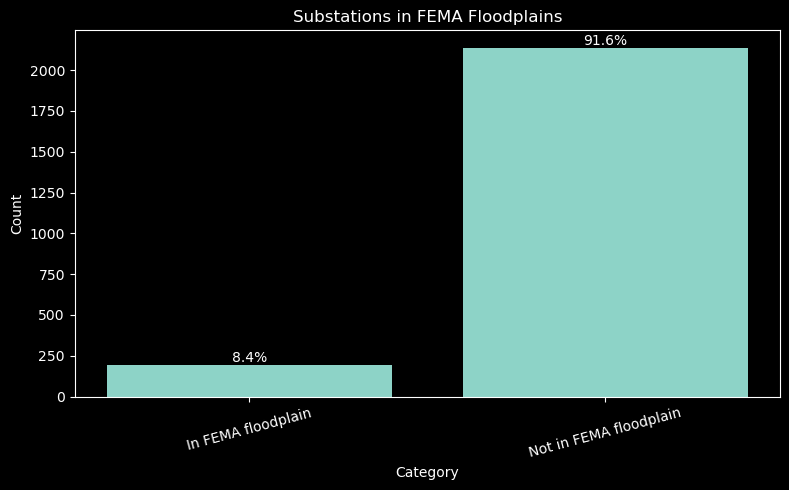

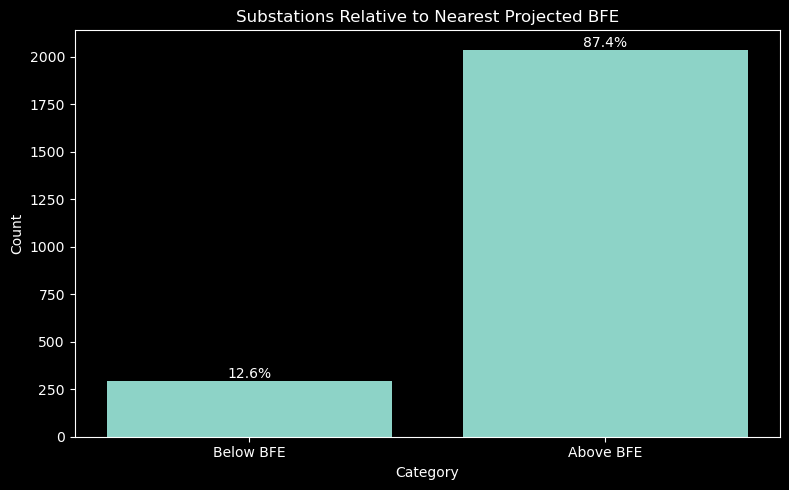

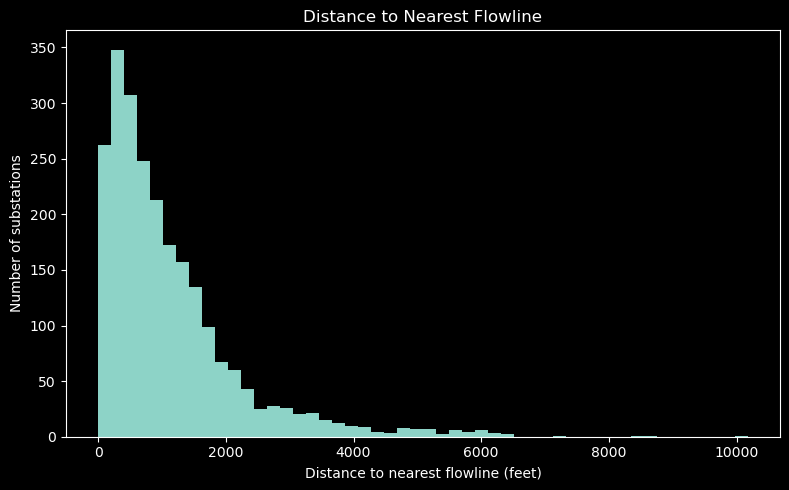

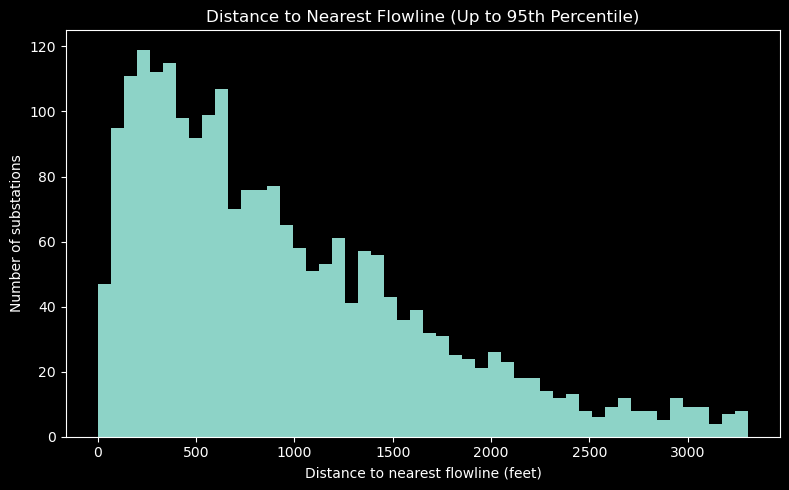

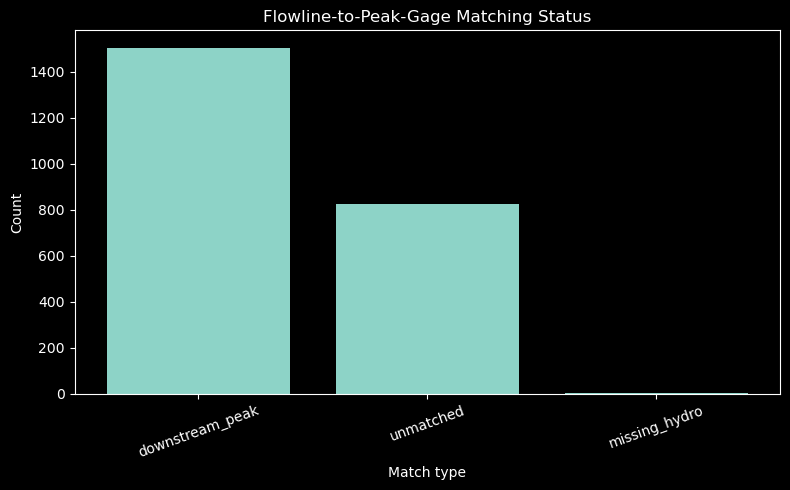

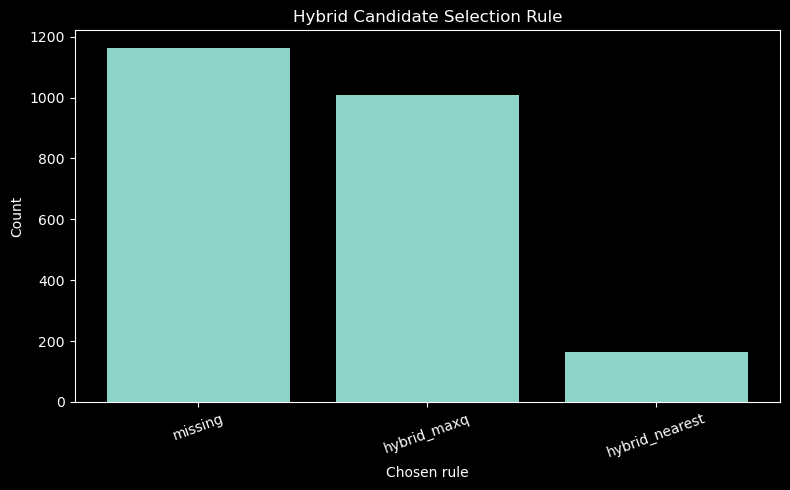

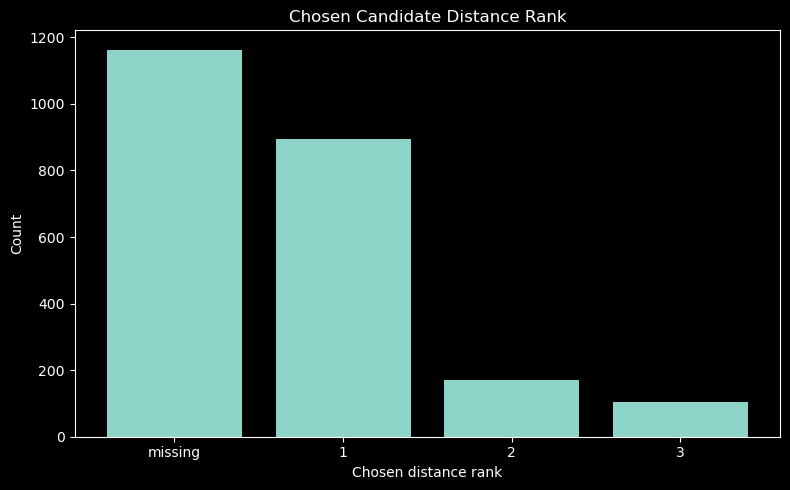

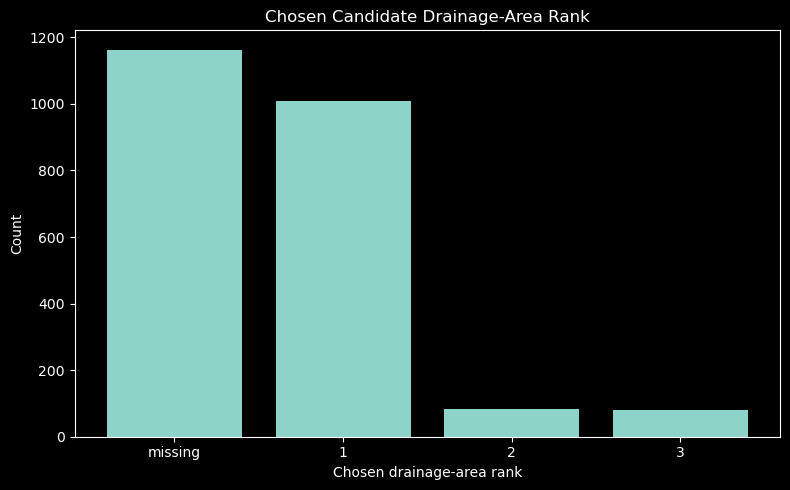


Verification summary:
n_total_substations 2333
n_in_floodplain 196
pct_in_floodplain 8.401200171453064
n_below_bfe 295
pct_below_bfe 12.64466352336048
n_scaled 1504
n_unmatched 824
n_missing_hydro 5


In [112]:
# Step 1 — Load the composite feature class into pandas and create
# the first batch of summary visualizations

import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Confirm the composite feature class path
# ------------------------------------------------------------------
print("Composite exists:", arcpy.Exists(composite_fc))
print("Composite row count:", int(arcpy.management.GetCount(composite_fc)[0]))

# ------------------------------------------------------------------
# 2. Pull composite fields into pandas
# ------------------------------------------------------------------
composite_fields = [field.name for field in arcpy.ListFields(composite_fc)]
print("Number of fields in composite:", len(composite_fields))

composite_records = []
with arcpy.da.SearchCursor(composite_fc, composite_fields) as cursor:
    for row in cursor:
        composite_records.append(row)

composite_df = pd.DataFrame(composite_records, columns=composite_fields)

print("composite_df shape:", composite_df.shape)
print(composite_df.head(3))

# ------------------------------------------------------------------
# 3. Standardize key fields
# ------------------------------------------------------------------
numeric_fields = [
    "fld_join_count",
    "flow_near_dist",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath",
    "match_steps",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "chosen_rank_dist",
    "chosen_rank_tdas",
    "chosen_q_sub_scaled",
    "dem_ft",
    "dem_m",
    "bfe_near_dist",
    "bfe_elev_ft",
    "dem_minus_bfe",
    "cm_n_cand_total",
    "cm_n_cand_match"
]

for field_name in numeric_fields:
    if field_name in composite_df.columns:
        composite_df[field_name] = pd.to_numeric(composite_df[field_name], errors="coerce")

string_fields = [
    "match_type",
    "rarity_stat",
    "chosen_rule",
    "bfe_flag",
    "source_gnis",
    "source_reach",
    "county_name",
    "operator",
    "substation"
]

for field_name in string_fields:
    if field_name in composite_df.columns:
        composite_df[field_name] = composite_df[field_name].replace(["", " ", "<Null>"], np.nan)

# Create a few clean indicator fields
composite_df["in_floodplain"] = composite_df["fld_join_count"].fillna(0) > 0
composite_df["below_bfe"] = composite_df["bfe_flag"] == "below_bfe"
composite_df["is_scaled"] = composite_df["match_type"] == "downstream_peak"
composite_df["is_unmatched"] = composite_df["match_type"] == "unmatched"
composite_df["is_missing_hydro"] = composite_df["match_type"] == "missing_hydro"

print("\nIndicator counts:")
print(composite_df[["in_floodplain", "below_bfe", "is_scaled", "is_unmatched", "is_missing_hydro"]].sum())

# ------------------------------------------------------------------
# 4. Output folder for plots
# ------------------------------------------------------------------
plot_dir = os.path.join(PROJECT_DIR, "plots_composite")
import os
os.makedirs(plot_dir, exist_ok=True)
print("Plot folder:", plot_dir)

# ------------------------------------------------------------------
# 5. Plot A — Percent of substations in FEMA flood plains
# ------------------------------------------------------------------
flood_counts = composite_df["in_floodplain"].value_counts(dropna=False)
flood_plot_df = pd.DataFrame({
    "category": ["In FEMA floodplain", "Not in FEMA floodplain"],
    "count": [
        int(composite_df["in_floodplain"].sum()),
        int((~composite_df["in_floodplain"]).sum())
    ]
})
flood_plot_df["percent"] = 100 * flood_plot_df["count"] / flood_plot_df["count"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(flood_plot_df["category"], flood_plot_df["count"])
ax.set_title("Substations in FEMA Floodplains")
ax.set_ylabel("Count")
ax.set_xlabel("Category")

for index, row_value in flood_plot_df.iterrows():
    ax.text(index, row_value["count"], f'{row_value["percent"]:.1f}%', ha="center", va="bottom")

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_01_floodplain_percent.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 6. Plot B — Percent of substations below defined BFE
# ------------------------------------------------------------------
bfe_plot_df = pd.DataFrame({
    "category": ["Below BFE", "Above BFE"],
    "count": [
        int((composite_df["bfe_flag"] == "below_bfe").sum()),
        int((composite_df["bfe_flag"] == "above_bfe").sum())
    ]
})
bfe_plot_df["percent"] = 100 * bfe_plot_df["count"] / bfe_plot_df["count"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(bfe_plot_df["category"], bfe_plot_df["count"])
ax.set_title("Substations Relative to Nearest Projected BFE")
ax.set_ylabel("Count")
ax.set_xlabel("Category")

for index, row_value in bfe_plot_df.iterrows():
    ax.text(index, row_value["count"], f'{row_value["percent"]:.1f}%', ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_02_bfe_flag_percent.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 7. Plot C — Distribution of distance to nearest flowline
# ------------------------------------------------------------------
flow_dist_df = composite_df.loc[composite_df["flow_near_dist"].notna(), ["flow_near_dist"]].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(flow_dist_df["flow_near_dist"], bins=50)
ax.set_title("Distance to Nearest Flowline")
ax.set_xlabel("Distance to nearest flowline (feet)")
ax.set_ylabel("Number of substations")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_03_flow_near_dist_hist.png"), dpi=300, bbox_inches="tight")
plt.show()

# Optional zoomed version because the right tail may be long
flow_dist_95 = flow_dist_df["flow_near_dist"].quantile(0.95)
flow_dist_zoom_df = flow_dist_df.loc[flow_dist_df["flow_near_dist"] <= flow_dist_95].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(flow_dist_zoom_df["flow_near_dist"], bins=50)
ax.set_title("Distance to Nearest Flowline (Up to 95th Percentile)")
ax.set_xlabel("Distance to nearest flowline (feet)")
ax.set_ylabel("Number of substations")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_04_flow_near_dist_hist_95pct.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 8. Plot D — Match type counts
# ------------------------------------------------------------------
match_type_df = (
    composite_df["match_type"]
    .fillna("missing")
    .value_counts()
    .reset_index()
)
match_type_df.columns = ["match_type", "count"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(match_type_df["match_type"], match_type_df["count"])
ax.set_title("Flowline-to-Peak-Gage Matching Status")
ax.set_xlabel("Match type")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_05_match_type_counts.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 9. Plot E — Chosen rule counts
# Note: 'missing' here mostly means no scaled candidate/hybrid choice
# ------------------------------------------------------------------
chosen_rule_df = (
    composite_df["chosen_rule"]
    .fillna("missing")
    .value_counts()
    .reset_index()
)
chosen_rule_df.columns = ["chosen_rule", "count"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(chosen_rule_df["chosen_rule"], chosen_rule_df["count"])
ax.set_title("Hybrid Candidate Selection Rule")
ax.set_xlabel("Chosen rule")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_06_chosen_rule_counts.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 10. Plot F — Chosen distance-rank counts
# ------------------------------------------------------------------
chosen_rank_dist_df = (
    composite_df["chosen_rank_dist"]
    .fillna(-1)
    .astype(int)
    .replace({-1: "missing"})
    .value_counts()
    .reset_index()
)
chosen_rank_dist_df.columns = ["chosen_rank_dist", "count"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(chosen_rank_dist_df["chosen_rank_dist"].astype(str), chosen_rank_dist_df["count"])
ax.set_title("Chosen Candidate Distance Rank")
ax.set_xlabel("Chosen distance rank")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_07_chosen_rank_dist_counts.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 11. Plot G — Chosen drainage-area-rank counts
# ------------------------------------------------------------------
chosen_rank_tdas_df = (
    composite_df["chosen_rank_tdas"]
    .fillna(-1)
    .astype(int)
    .replace({-1: "missing"})
    .value_counts()
    .reset_index()
)
chosen_rank_tdas_df.columns = ["chosen_rank_tdas", "count"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(chosen_rank_tdas_df["chosen_rank_tdas"].astype(str), chosen_rank_tdas_df["count"])
ax.set_title("Chosen Candidate Drainage-Area Rank")
ax.set_xlabel("Chosen drainage-area rank")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "plot_08_chosen_rank_tdas_counts.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 12. Print compact summary table for verification
# ------------------------------------------------------------------
summary_check = {
    "n_total_substations": int(len(composite_df)),
    "n_in_floodplain": int(composite_df["in_floodplain"].sum()),
    "pct_in_floodplain": 100 * composite_df["in_floodplain"].mean(),
    "n_below_bfe": int(composite_df["below_bfe"].sum()),
    "pct_below_bfe": 100 * composite_df["below_bfe"].mean(),
    "n_scaled": int(composite_df["is_scaled"].sum()),
    "n_unmatched": int(composite_df["is_unmatched"].sum()),
    "n_missing_hydro": int(composite_df["is_missing_hydro"].sum())
}

print("\nVerification summary:")
for summary_name, summary_value in summary_check.items():
    print(summary_name, summary_value)

## Load Layer into a DataFrame

In [115]:
# Rebuild composite_df with unique column names
# and correct flood field usage

import arcpy
import pandas as pd
import numpy as np

composite_fc = fr"{gdb_main}\PA_substations_composite_final"

field_map = [
    ("OBJECTID", "OBJECTID"),
    ("county_name", "county_name"),
    ("name", "name"),
    ("operator", "operator"),
    ("substation", "substation"),
    ("voltage", "voltage"),
    ("fld_join_count", "fld_join_count"),
    ("bfe_flag", "bfe_flag"),
    ("dem_ft", "dem_ft"),
    ("dem_m", "dem_m"),
    ("bfe_elev_ft", "bfe_elev_ft"),
    ("dem_minus_bfe", "dem_minus_bfe"),
    ("flow_near_dist", "flow_near_dist"),
    ("flow_near_fid", "flow_near_fid"),
    ("flow_nhdpid", "flow_nhdpid"),
    ("flow_tdas", "flow_tdas"),
    ("flow_hseq", "flow_hseq"),
    ("flow_lpath", "flow_lpath"),
    ("source_gnis", "source_gnis"),
    ("source_reach", "source_reach"),
    ("source_ftype", "source_ftype"),
    ("source_fcode", "source_fcode"),
    ("match_site8", "match_site8"),
    ("match_nhdpid", "match_nhdpid"),
    ("match_steps", "match_steps"),
    ("match_type", "match_type"),
    ("q_sub_scaled", "q_sub_scaled"),
    ("emp_exceed", "emp_exceed"),
    ("emp_retper", "emp_retper"),
    ("rarity_stat", "rarity_stat"),
    ("chosen_rule", "chosen_rule"),
    ("chosen_rank_dist", "chosen_rank_dist"),
    ("chosen_rank_tdas", "chosen_rank_tdas"),
    ("chosen_q_sub_scaled", "chosen_q_sub_scaled"),
    ("chosen_flow_oid", "chosen_flow_oid"),
    ("chosen_flow_tdas", "chosen_flow_tdas"),
    ("chosen_flow_gnis", "chosen_flow_gnis"),
    ("cm_n_cand_total", "cm_n_cand_total"),
    ("cm_n_cand_match", "cm_n_cand_match"),
    ("SHAPE@X", "x_coord"),
    ("SHAPE@Y", "y_coord")
]

search_fields = [field_name for field_name, column_name in field_map]
column_names = [column_name for field_name, column_name in field_map]

composite_rows = []
with arcpy.da.SearchCursor(composite_fc, search_fields) as cursor:
    for row in cursor:
        composite_rows.append(row)

composite_df = pd.DataFrame(composite_rows, columns=column_names)

numeric_fields = [
    "fld_join_count",
    "dem_ft",
    "dem_m",
    "bfe_elev_ft",
    "dem_minus_bfe",
    "flow_near_dist",
    "flow_near_fid",
    "flow_nhdpid",
    "flow_tdas",
    "flow_hseq",
    "flow_lpath",
    "source_ftype",
    "source_fcode",
    "match_nhdpid",
    "match_steps",
    "q_sub_scaled",
    "emp_exceed",
    "emp_retper",
    "chosen_rank_dist",
    "chosen_rank_tdas",
    "chosen_q_sub_scaled",
    "chosen_flow_oid",
    "chosen_flow_tdas",
    "cm_n_cand_total",
    "cm_n_cand_match",
    "x_coord",
    "y_coord"
]

for field_name in numeric_fields:
    if field_name in composite_df.columns:
        composite_df[field_name] = pd.to_numeric(composite_df[field_name], errors="coerce")

composite_df["in_floodplain"] = np.where(
    composite_df["fld_join_count"].fillna(0) > 0,
    "In floodplain",
    "Not in floodplain"
)

composite_df["below_bfe_flag"] = np.where(
    composite_df["bfe_flag"] == "below_bfe",
    "Below BFE",
    "At/above BFE"
)

composite_df["scaled_flag"] = np.where(
    composite_df["q_sub_scaled"].notna(),
    "Scaled",
    "Not scaled"
)

print("Rows loaded:", len(composite_df))
print("Columns loaded:", len(composite_df.columns))
print("Duplicate column names:", composite_df.columns[composite_df.columns.duplicated()].tolist())
print(composite_df.head())

Rows loaded: 2333
Columns loaded: 44
Duplicate column names: []
   OBJECTID                       county_name  name operator substation  \
0         1  Greene County, Pennsylvania, USA  None     None       None   
1         2  Greene County, Pennsylvania, USA  None     None       None   
2         3  Greene County, Pennsylvania, USA  None     None       None   
3         4  Greene County, Pennsylvania, USA  None     None       None   
4         5  Greene County, Pennsylvania, USA  None     None       None   

        voltage  fld_join_count   bfe_flag       dem_ft   dem_m  ...  \
0  138000;34500               1  above_bfe   998.654888  304.39  ...   
1          None               0  above_bfe  1341.371434  408.85  ...   
2        138000               0  above_bfe  1033.759876  315.09  ...   
3          None               0  above_bfe  1308.923926  398.96  ...   
4          None               0  above_bfe  1298.392430  395.75  ...   

   chosen_flow_oid  chosen_flow_tdas  chosen_flow_gn

In [ ]:
scaled_df = composite_df.loc[composite_df["q_sub_scaled"].notna()].copy()

plt.figure(figsize=(10, 6))
plt.hist(scaled_df["q_sub_scaled"], bins=40)
plt.title("Distribution of Scaled Substation Discharge")
plt.xlabel("Scaled discharge")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

scaled_df["log10_q_sub_scaled"] = np.log10(scaled_df["q_sub_scaled"])

plt.figure(figsize=(10, 6))
plt.hist(scaled_df["log10_q_sub_scaled"], bins=40)
plt.title("Distribution of log10 Scaled Substation Discharge")
plt.xlabel("log10(scaled discharge)")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

scaled_sorted = np.sort(scaled_df["q_sub_scaled"].to_numpy())
scaled_cdf = np.arange(1, len(scaled_sorted) + 1) / len(scaled_sorted)

plt.figure(figsize=(10, 6))
plt.plot(scaled_sorted, scaled_cdf)
plt.title("Empirical Cumulative Distribution of Scaled Substation Discharge")
plt.xlabel("Scaled discharge")
plt.ylabel("Cumulative proportion")
plt.tight_layout()
plt.show()

### Distribution of Scaled Discharge

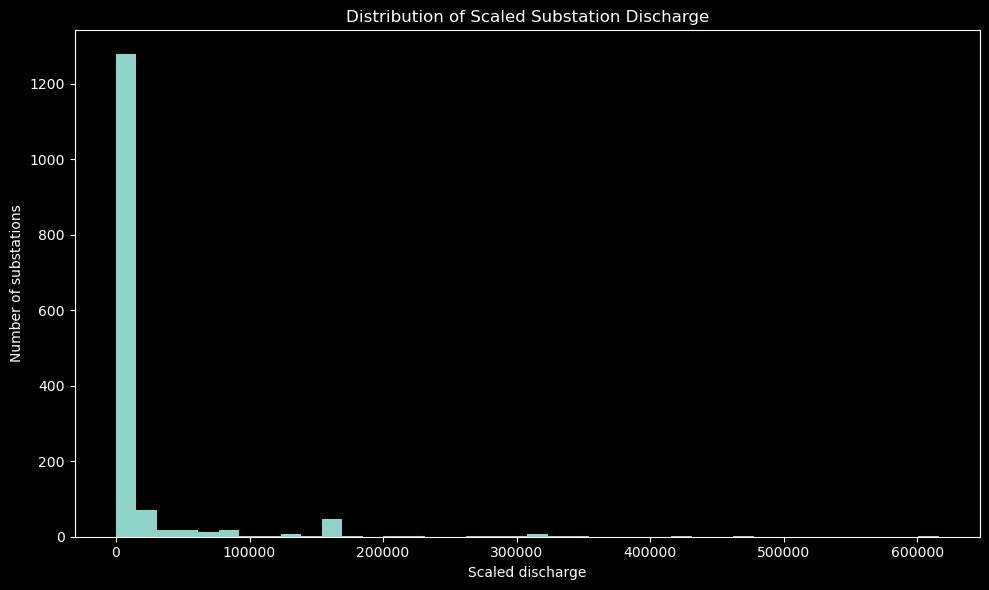

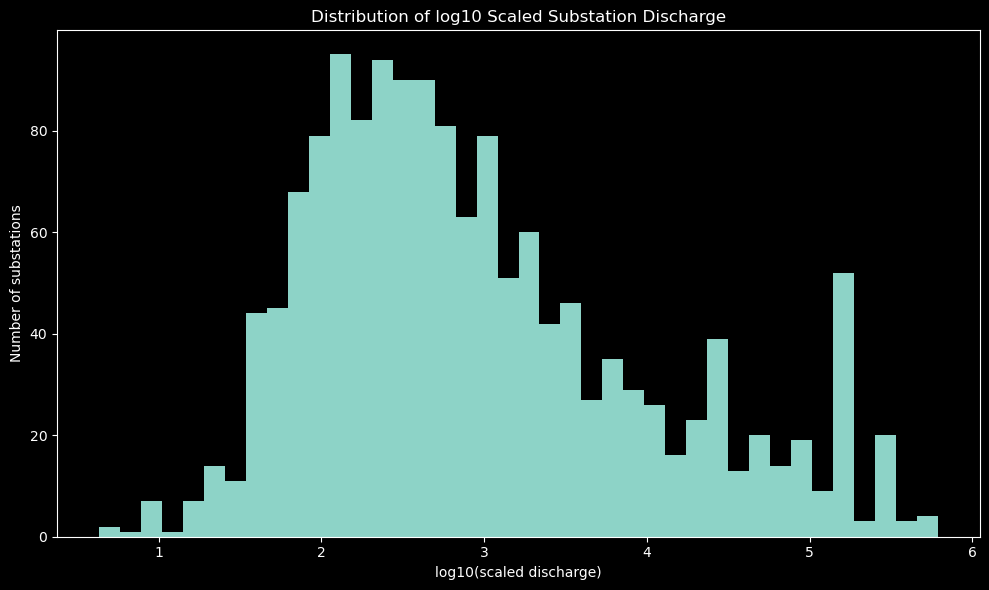

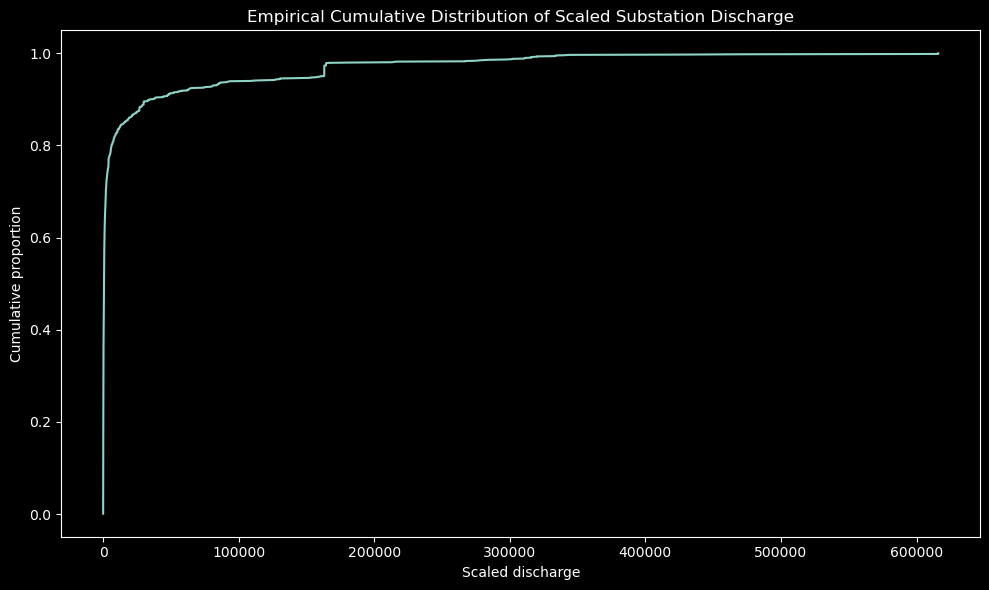

In [116]:
scaled_df = composite_df.loc[composite_df["q_sub_scaled"].notna()].copy()

plt.figure(figsize=(10, 6))
plt.hist(scaled_df["q_sub_scaled"], bins=40)
plt.title("Distribution of Scaled Substation Discharge")
plt.xlabel("Scaled discharge")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

scaled_df["log10_q_sub_scaled"] = np.log10(scaled_df["q_sub_scaled"])

plt.figure(figsize=(10, 6))
plt.hist(scaled_df["log10_q_sub_scaled"], bins=40)
plt.title("Distribution of log10 Scaled Substation Discharge")
plt.xlabel("log10(scaled discharge)")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

scaled_sorted = np.sort(scaled_df["q_sub_scaled"].to_numpy())
scaled_cdf = np.arange(1, len(scaled_sorted) + 1) / len(scaled_sorted)

plt.figure(figsize=(10, 6))
plt.plot(scaled_sorted, scaled_cdf)
plt.title("Empirical Cumulative Distribution of Scaled Substation Discharge")
plt.xlabel("Scaled discharge")
plt.ylabel("Cumulative proportion")
plt.tight_layout()
plt.show()

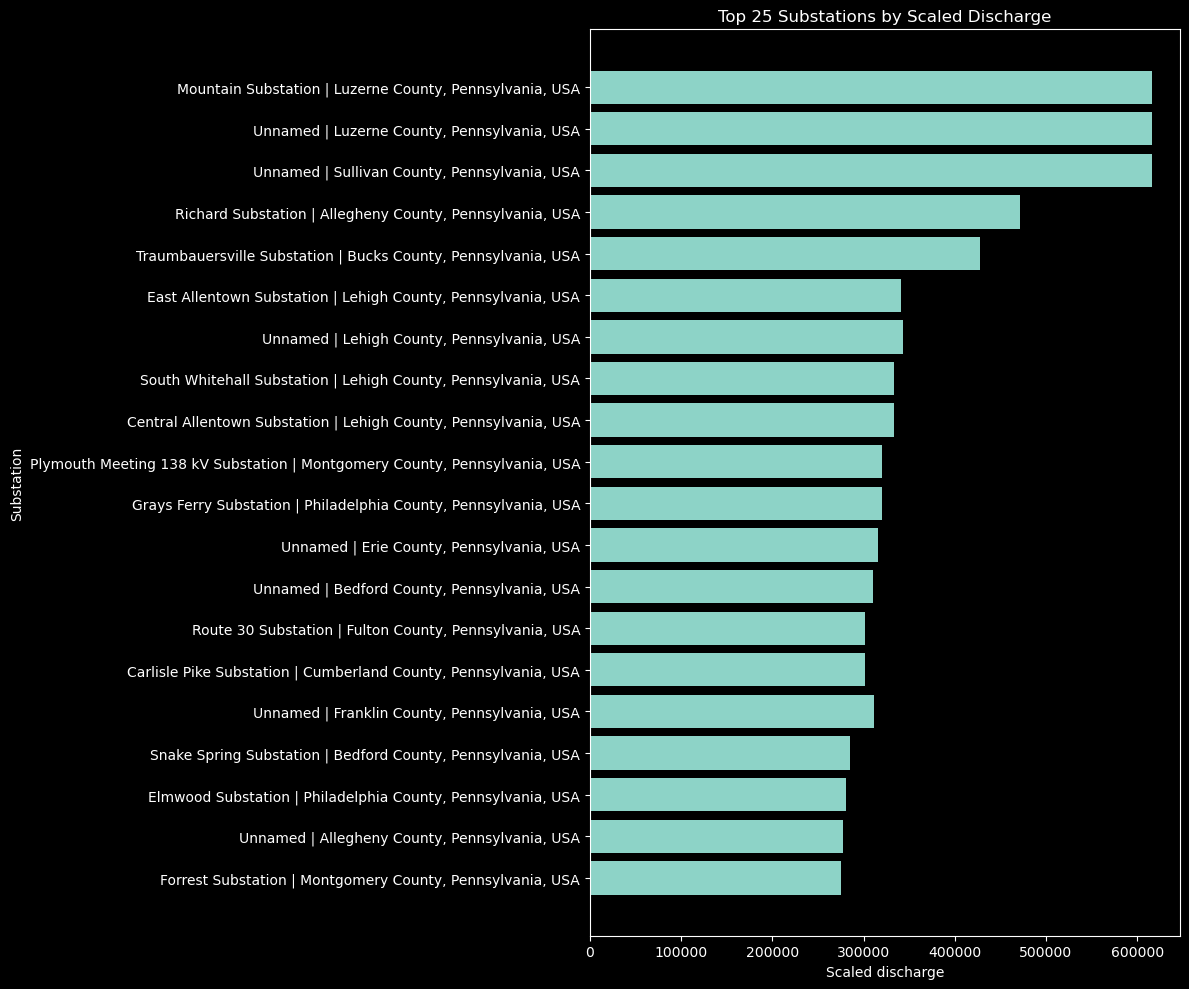

      OBJECTID                             county_name  \
1996      1997       Luzerne County, Pennsylvania, USA   
1997      1998       Luzerne County, Pennsylvania, USA   
1992      1993      Sullivan County, Pennsylvania, USA   
1297      1298     Allegheny County, Pennsylvania, USA   
1263      1264         Bucks County, Pennsylvania, USA   
1469      1470        Lehigh County, Pennsylvania, USA   
1448      1449        Lehigh County, Pennsylvania, USA   
1465      1466        Lehigh County, Pennsylvania, USA   
1452      1453        Lehigh County, Pennsylvania, USA   
1473      1474        Lehigh County, Pennsylvania, USA   
437        438    Montgomery County, Pennsylvania, USA   
457        458  Philadelphia County, Pennsylvania, USA   
2248      2249          Erie County, Pennsylvania, USA   
2249      2250          Erie County, Pennsylvania, USA   
2250      2251          Erie County, Pennsylvania, USA   
254        255      Franklin County, Pennsylvania, USA   
255        256

In [117]:
top_scaled_df = (
    scaled_df[[
        "OBJECTID", "county_name", "name", "operator",
        "substation", "q_sub_scaled", "match_site8",
        "source_gnis", "match_steps"
    ]]
    .sort_values("q_sub_scaled", ascending=False)
    .head(25)
    .copy()
)

top_scaled_df["label_name"] = top_scaled_df["name"].fillna("Unnamed")
top_scaled_df["plot_label"] = (
    top_scaled_df["label_name"]
    + " | "
    + top_scaled_df["county_name"].fillna("Unknown county")
)

plt.figure(figsize=(12, 10))
plt.barh(top_scaled_df["plot_label"][::-1], top_scaled_df["q_sub_scaled"][::-1])
plt.title("Top 25 Substations by Scaled Discharge")
plt.xlabel("Scaled discharge")
plt.ylabel("Substation")
plt.tight_layout()
plt.show()

print(top_scaled_df)

### Regarding Flowlines

In [118]:
chosen_flow_df = composite_df.loc[
    composite_df["chosen_flow_oid"].notna()
].copy()

flowline_summary_df = (
    chosen_flow_df.groupby(
        ["chosen_flow_oid", "chosen_flow_gnis", "chosen_flow_tdas"],
        dropna=False,
        as_index=False
    )
    .agg(
        n_substations=("OBJECTID", "size"),
        n_scaled=("q_sub_scaled", lambda x: x.notna().sum()),
        mean_scaled_q=("q_sub_scaled", "mean"),
        max_scaled_q=("q_sub_scaled", "max")
    )
    .sort_values(["chosen_flow_tdas", "n_substations"], ascending=[False, False])
)

print(flowline_summary_df.head(30))

     chosen_flow_oid   chosen_flow_gnis  chosen_flow_tdas  n_substations  \
874         193592.0    Allegheny River      29090.787899              1   
987         213451.0  Susquehanna River      25217.955696              2   
138          29149.0  Susquehanna River      24881.099396              1   
848         188532.0    Allegheny River      24195.441900              2   
806         177865.0    Allegheny River      24148.801900              1   
136          28754.0  Susquehanna River      23768.814597              1   
133          28581.0  Susquehanna River      23717.904597              1   
807         177930.0    Allegheny River      23289.031899              2   
672         151248.0    Allegheny River      22872.771099              1   
369          74528.0  Susquehanna River      22189.604397              1   
673         151311.0    Allegheny River      21730.829999              1   
179          44285.0  Susquehanna River      20662.043197              1   
332         

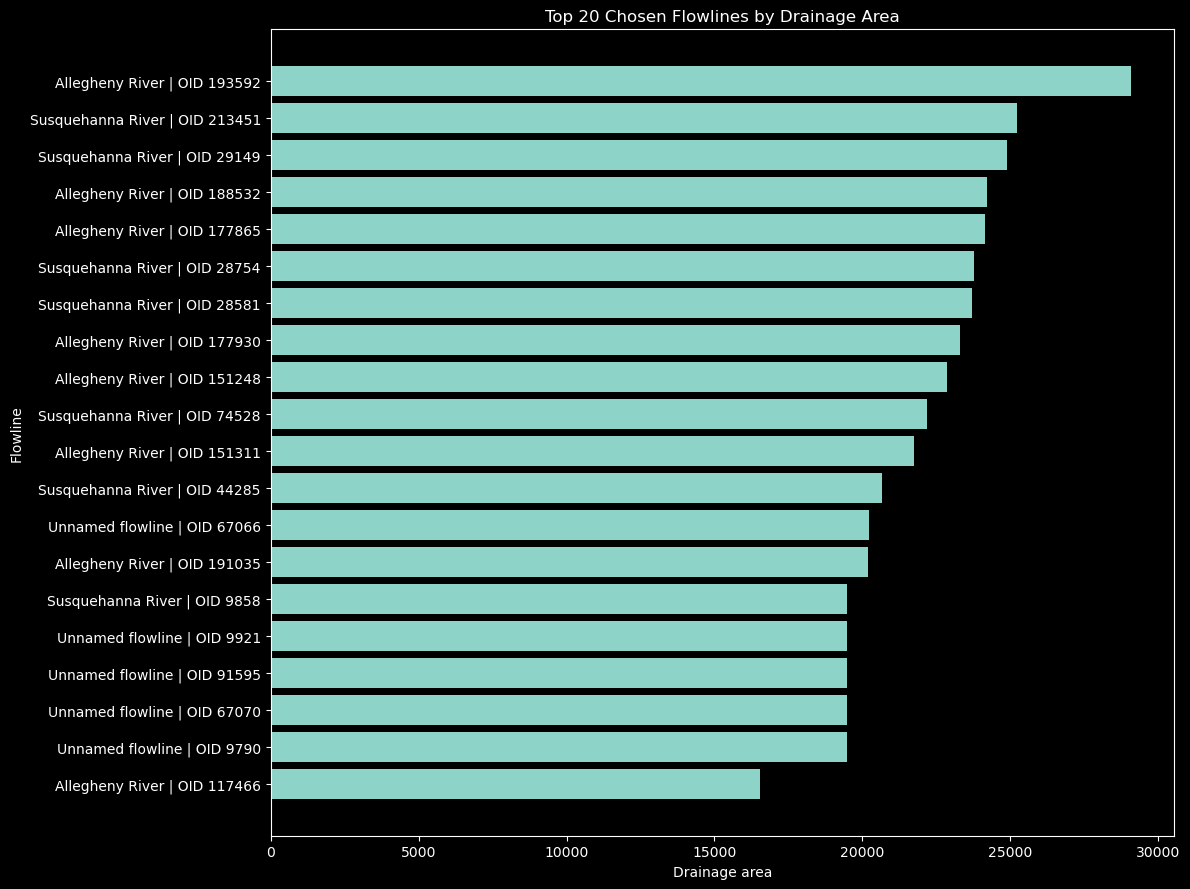

In [119]:
top_drainage_df = flowline_summary_df.head(20).copy()
top_drainage_df["flow_label"] = top_drainage_df["chosen_flow_gnis"].fillna("Unnamed flowline")
top_drainage_df["flow_label"] = (
    top_drainage_df["flow_label"]
    + " | OID "
    + top_drainage_df["chosen_flow_oid"].astype(int).astype(str)
)

plt.figure(figsize=(12, 9))
plt.barh(top_drainage_df["flow_label"][::-1], top_drainage_df["chosen_flow_tdas"][::-1])
plt.title("Top 20 Chosen Flowlines by Drainage Area")
plt.xlabel("Drainage area")
plt.ylabel("Flowline")
plt.tight_layout()
plt.show()

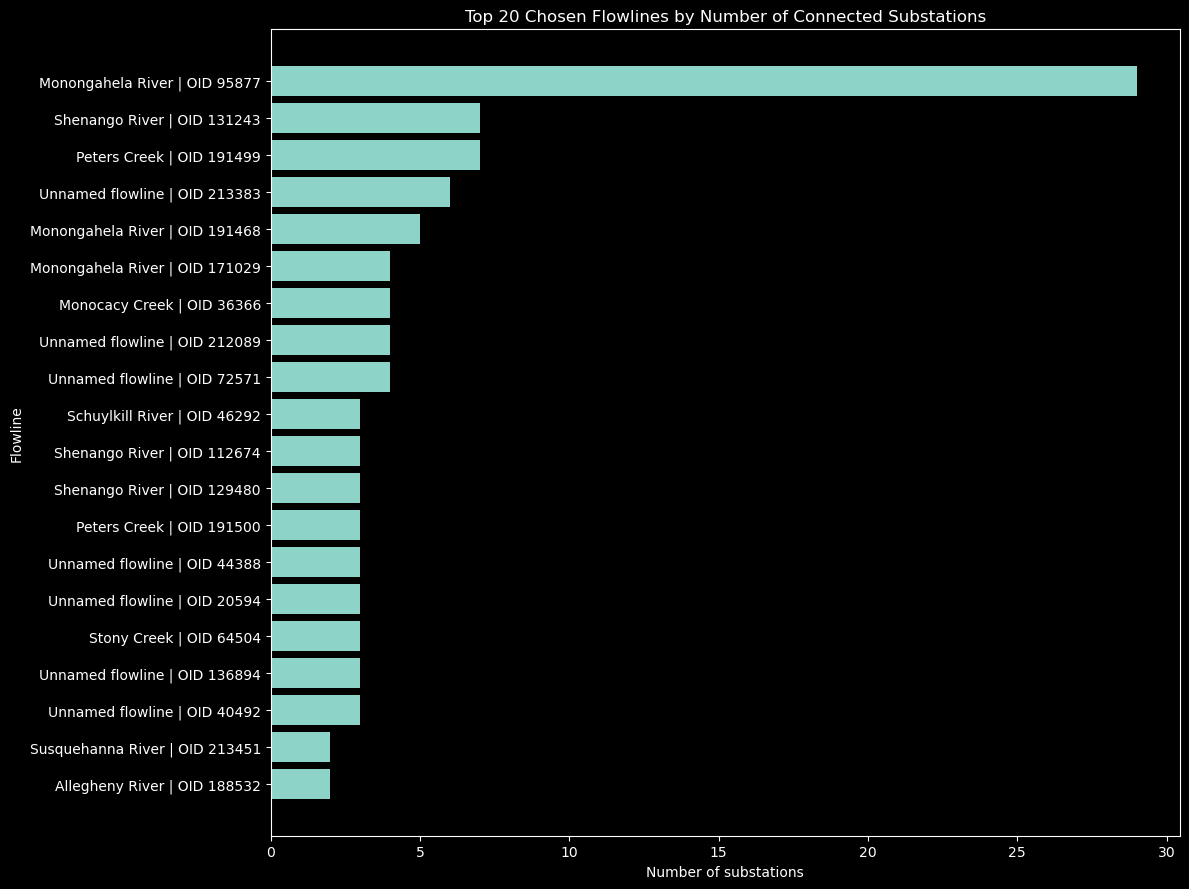

In [120]:
top_connected_df = (
    flowline_summary_df
    .sort_values(["n_substations", "chosen_flow_tdas"], ascending=[False, False])
    .head(20)
    .copy()
)

top_connected_df["flow_label"] = top_connected_df["chosen_flow_gnis"].fillna("Unnamed flowline")
top_connected_df["flow_label"] = (
    top_connected_df["flow_label"]
    + " | OID "
    + top_connected_df["chosen_flow_oid"].astype(int).astype(str)
)

plt.figure(figsize=(12, 9))
plt.barh(top_connected_df["flow_label"][::-1], top_connected_df["n_substations"][::-1])
plt.title("Top 20 Chosen Flowlines by Number of Connected Substations")
plt.xlabel("Number of substations")
plt.ylabel("Flowline")
plt.tight_layout()
plt.show()

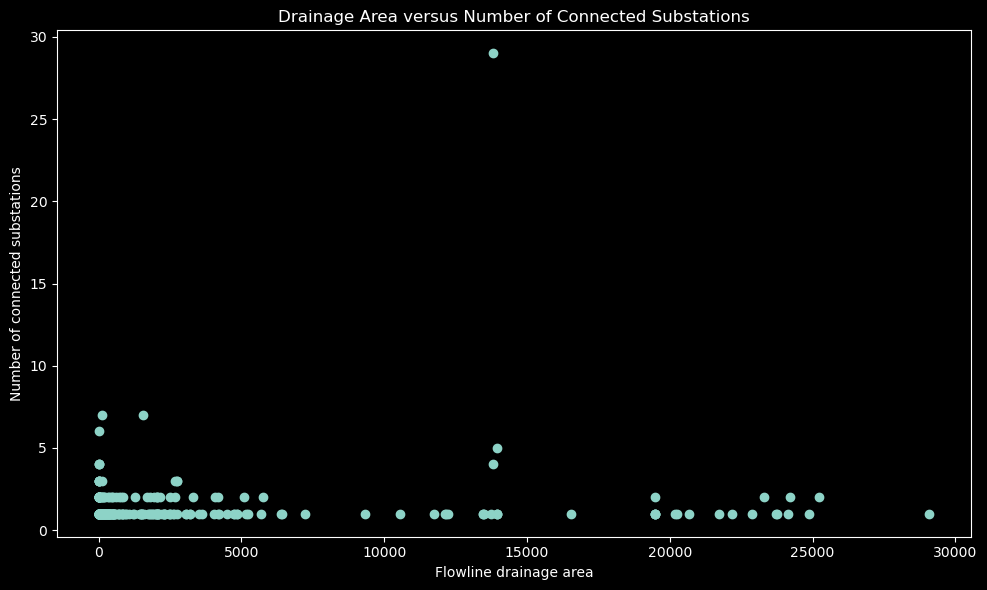

In [121]:
scatter_df = flowline_summary_df.loc[
    flowline_summary_df["chosen_flow_tdas"].notna() &
    flowline_summary_df["n_substations"].notna()
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["chosen_flow_tdas"], scatter_df["n_substations"])
plt.title("Drainage Area versus Number of Connected Substations")
plt.xlabel("Flowline drainage area")
plt.ylabel("Number of connected substations")
plt.tight_layout()
plt.show()

### Exceedence Prob

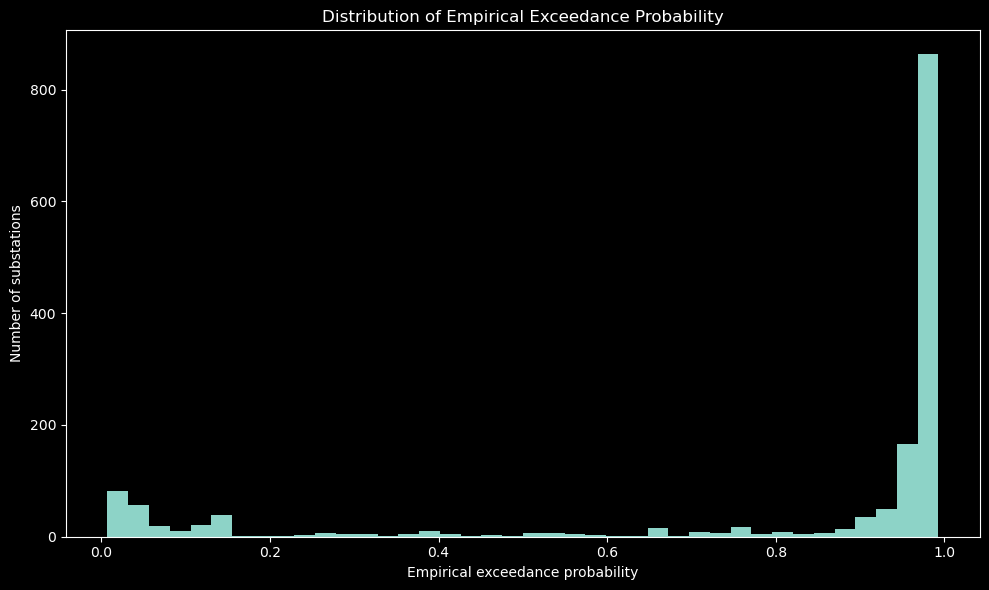

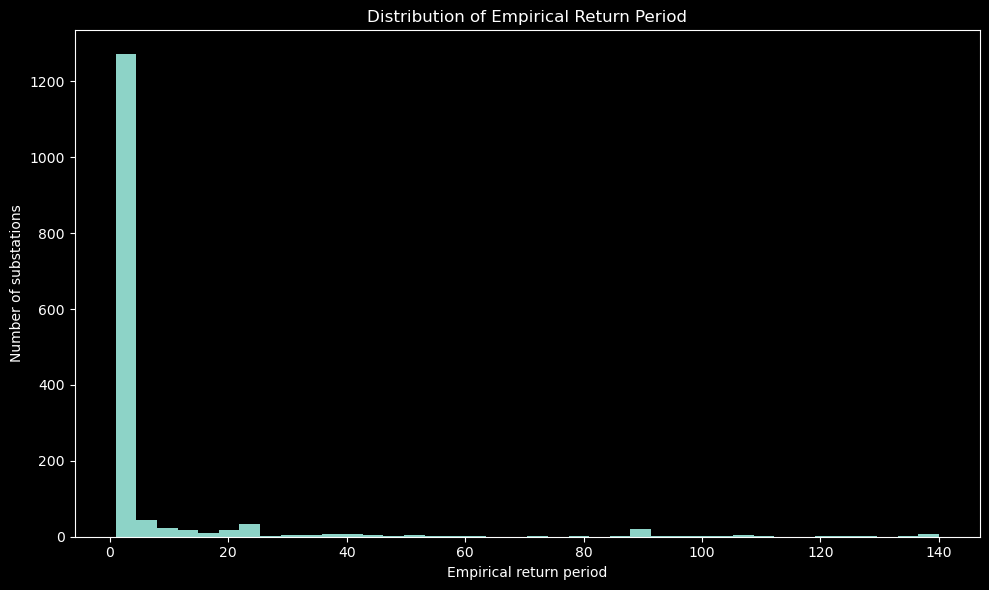

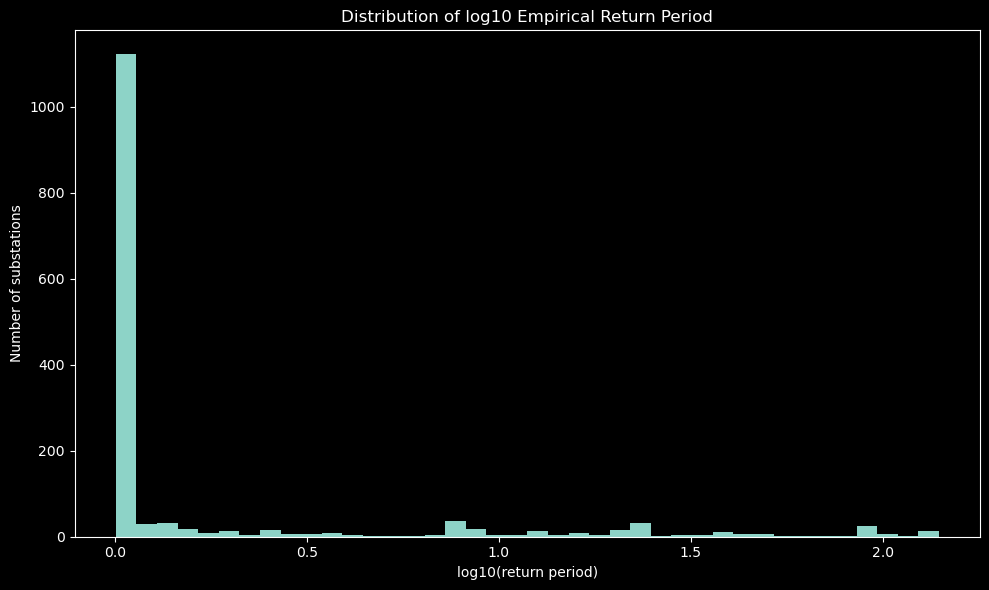

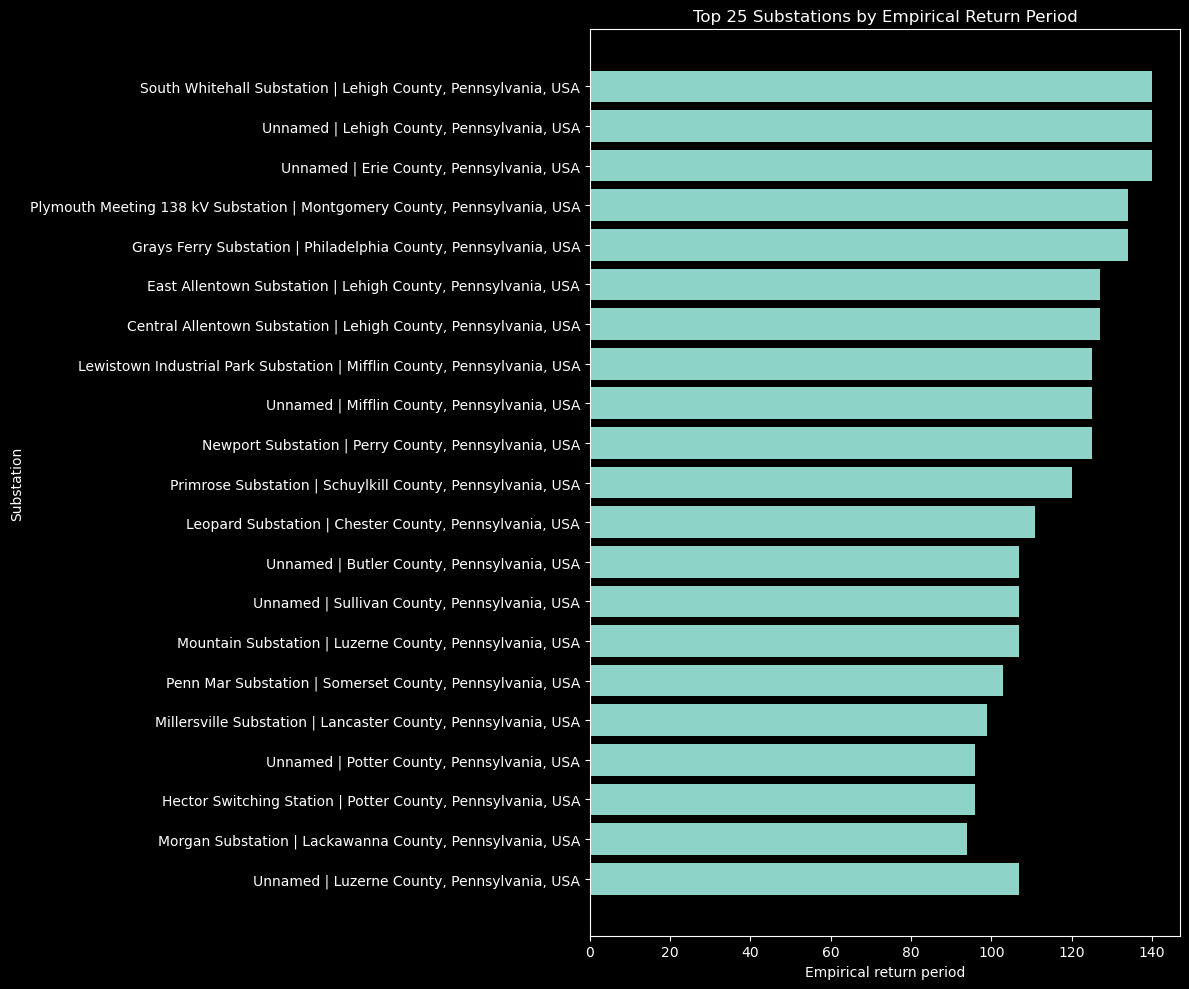

In [122]:
rarity_df = composite_df.loc[
    composite_df["emp_exceed"].notna() &
    composite_df["emp_retper"].notna()
].copy()

plt.figure(figsize=(10, 6))
plt.hist(rarity_df["emp_exceed"], bins=40)
plt.title("Distribution of Empirical Exceedance Probability")
plt.xlabel("Empirical exceedance probability")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(rarity_df["emp_retper"], bins=40)
plt.title("Distribution of Empirical Return Period")
plt.xlabel("Empirical return period")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

rarity_df["log10_emp_retper"] = np.log10(rarity_df["emp_retper"])

plt.figure(figsize=(10, 6))
plt.hist(rarity_df["log10_emp_retper"], bins=40)
plt.title("Distribution of log10 Empirical Return Period")
plt.xlabel("log10(return period)")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

top_retper_df = rarity_df.sort_values("emp_retper", ascending=False).head(25).copy()
top_retper_df["label_name"] = top_retper_df["name"].fillna("Unnamed")
top_retper_df["plot_label"] = (
    top_retper_df["label_name"]
    + " | "
    + top_retper_df["county_name"].fillna("Unknown county")
)

plt.figure(figsize=(12, 10))
plt.barh(top_retper_df["plot_label"][::-1], top_retper_df["emp_retper"][::-1])
plt.title("Top 25 Substations by Empirical Return Period")
plt.xlabel("Empirical return period")
plt.ylabel("Substation")
plt.tight_layout()
plt.show()

### Quadrants

In [123]:
spatial_df = composite_df.loc[
    composite_df["x_coord"].notna() &
    composite_df["y_coord"].notna()
].copy()

x_midpoint = spatial_df["x_coord"].median()
y_midpoint = spatial_df["y_coord"].median()

def assign_quadrant(x_value, y_value, x_midpoint, y_midpoint):
    if x_value <= x_midpoint and y_value > y_midpoint:
        return "Northwest"
    elif x_value > x_midpoint and y_value > y_midpoint:
        return "Northeast"
    elif x_value <= x_midpoint and y_value <= y_midpoint:
        return "Southwest"
    else:
        return "Southeast"

spatial_df["state_quadrant"] = spatial_df.apply(
    lambda row: assign_quadrant(row["x_coord"], row["y_coord"], x_midpoint, y_midpoint),
    axis=1
)

print(spatial_df["state_quadrant"].value_counts(dropna=False))

state_quadrant
Southeast    625
Northwest    625
Southwest    542
Northeast    541
Name: count, dtype: int64


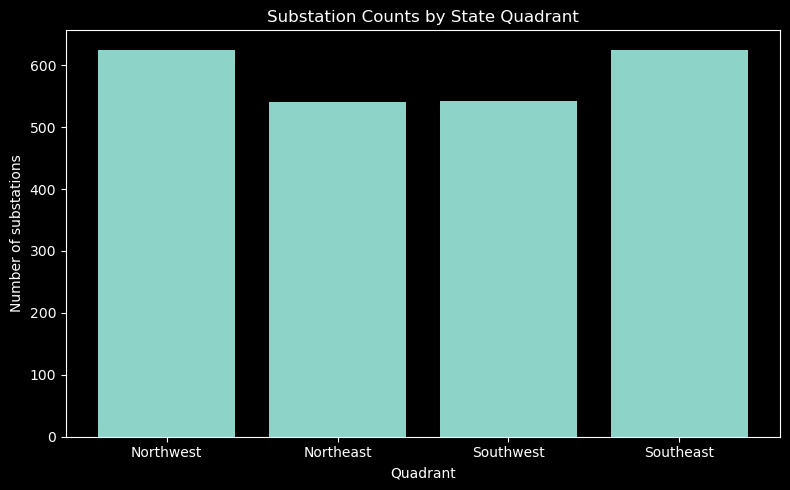

In [124]:
quadrant_counts_df = (
    spatial_df["state_quadrant"]
    .value_counts()
    .rename_axis("state_quadrant")
    .reset_index(name="n_substations")
)

quadrant_order = ["Northwest", "Northeast", "Southwest", "Southeast"]
quadrant_counts_df["state_quadrant"] = pd.Categorical(
    quadrant_counts_df["state_quadrant"],
    categories=quadrant_order,
    ordered=True
)
quadrant_counts_df = quadrant_counts_df.sort_values("state_quadrant")

plt.figure(figsize=(8, 5))
plt.bar(quadrant_counts_df["state_quadrant"], quadrant_counts_df["n_substations"])
plt.title("Substation Counts by State Quadrant")
plt.xlabel("Quadrant")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

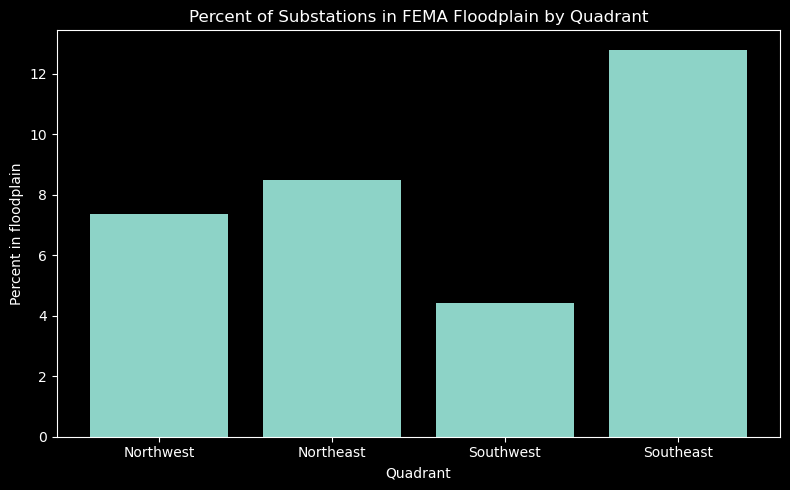

  state_quadrant  n_substations  n_in_floodplain  pct_in_floodplain
1      Northwest            625               46           7.360000
0      Northeast            541               46           8.502773
3      Southwest            542               24           4.428044
2      Southeast            625               80          12.800000


In [125]:
quadrant_flood_df = (
    spatial_df.groupby("state_quadrant", as_index=False)
    .agg(
        n_substations=("OBJECTID", "size"),
        n_in_floodplain=("fld_join_count", lambda x: (x.fillna(0) > 0).sum())
    )
)

quadrant_flood_df["pct_in_floodplain"] = 100 * quadrant_flood_df["n_in_floodplain"] / quadrant_flood_df["n_substations"]
quadrant_flood_df["state_quadrant"] = pd.Categorical(
    quadrant_flood_df["state_quadrant"],
    categories=quadrant_order,
    ordered=True
)
quadrant_flood_df = quadrant_flood_df.sort_values("state_quadrant")

plt.figure(figsize=(8, 5))
plt.bar(quadrant_flood_df["state_quadrant"], quadrant_flood_df["pct_in_floodplain"])
plt.title("Percent of Substations in FEMA Floodplain by Quadrant")
plt.xlabel("Quadrant")
plt.ylabel("Percent in floodplain")
plt.tight_layout()
plt.show()

print(quadrant_flood_df)

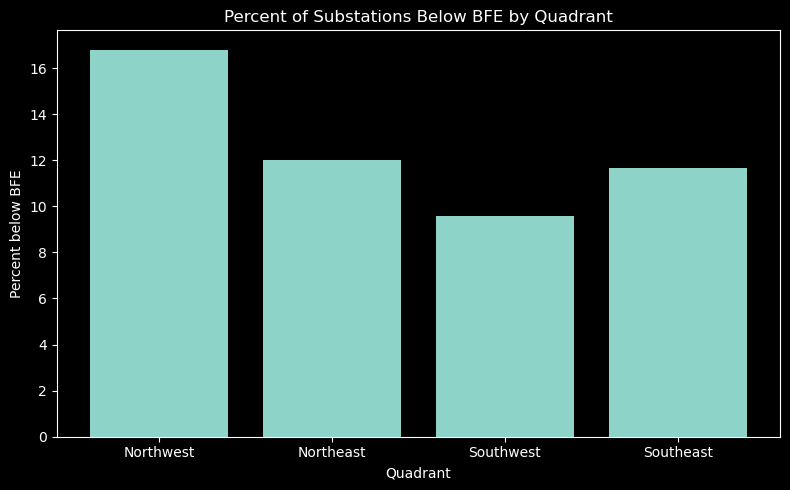

  state_quadrant  n_substations  n_below_bfe  pct_below_bfe
1      Northwest            625          105      16.800000
0      Northeast            541           65      12.014787
3      Southwest            542           52       9.594096
2      Southeast            625           73      11.680000


In [126]:
quadrant_bfe_df = (
    spatial_df.groupby("state_quadrant", as_index=False)
    .agg(
        n_substations=("OBJECTID", "size"),
        n_below_bfe=("bfe_flag", lambda x: (x == "below_bfe").sum())
    )
)

quadrant_bfe_df["pct_below_bfe"] = 100 * quadrant_bfe_df["n_below_bfe"] / quadrant_bfe_df["n_substations"]
quadrant_bfe_df["state_quadrant"] = pd.Categorical(
    quadrant_bfe_df["state_quadrant"],
    categories=quadrant_order,
    ordered=True
)
quadrant_bfe_df = quadrant_bfe_df.sort_values("state_quadrant")

plt.figure(figsize=(8, 5))
plt.bar(quadrant_bfe_df["state_quadrant"], quadrant_bfe_df["pct_below_bfe"])
plt.title("Percent of Substations Below BFE by Quadrant")
plt.xlabel("Quadrant")
plt.ylabel("Percent below BFE")
plt.tight_layout()
plt.show()

print(quadrant_bfe_df)

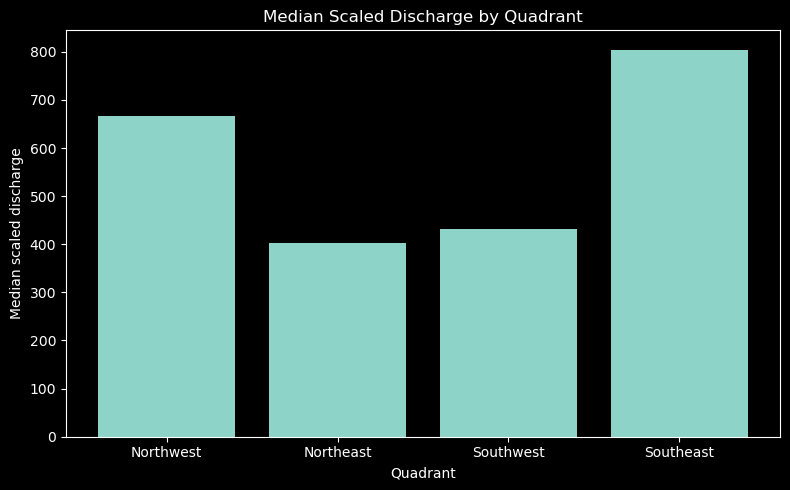

  state_quadrant  n_scaled  median_scaled_q  mean_scaled_q
1      Northwest       410       667.163775   12412.187249
0      Northeast       390       403.118696   17007.134224
3      Southwest       284       432.076429   16063.209202
2      Southeast       420       804.460351   25812.878020


In [127]:
quadrant_scaled_df = (
    spatial_df.groupby("state_quadrant", as_index=False)
    .agg(
        n_scaled=("q_sub_scaled", lambda x: x.notna().sum()),
        median_scaled_q=("q_sub_scaled", "median"),
        mean_scaled_q=("q_sub_scaled", "mean")
    )
)

quadrant_scaled_df["state_quadrant"] = pd.Categorical(
    quadrant_scaled_df["state_quadrant"],
    categories=quadrant_order,
    ordered=True
)
quadrant_scaled_df = quadrant_scaled_df.sort_values("state_quadrant")

plt.figure(figsize=(8, 5))
plt.bar(quadrant_scaled_df["state_quadrant"], quadrant_scaled_df["median_scaled_q"])
plt.title("Median Scaled Discharge by Quadrant")
plt.xlabel("Quadrant")
plt.ylabel("Median scaled discharge")
plt.tight_layout()
plt.show()

print(quadrant_scaled_df)

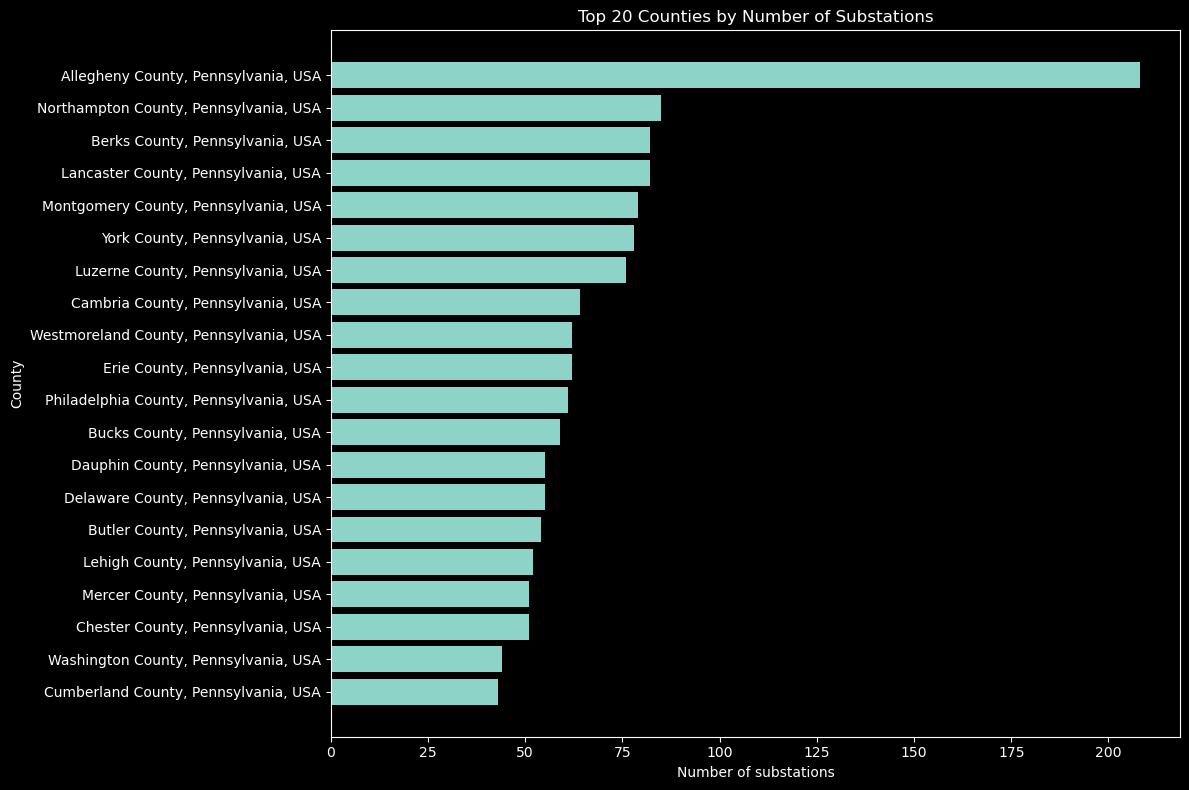

In [128]:
county_count_df = (
    composite_df["county_name"]
    .fillna("Unknown county")
    .value_counts()
    .head(20)
    .rename_axis("county_name")
    .reset_index(name="n_substations")
)

plt.figure(figsize=(12, 8))
plt.barh(county_count_df["county_name"][::-1], county_count_df["n_substations"][::-1])
plt.title("Top 20 Counties by Number of Substations")
plt.xlabel("Number of substations")
plt.ylabel("County")
plt.tight_layout()
plt.show()

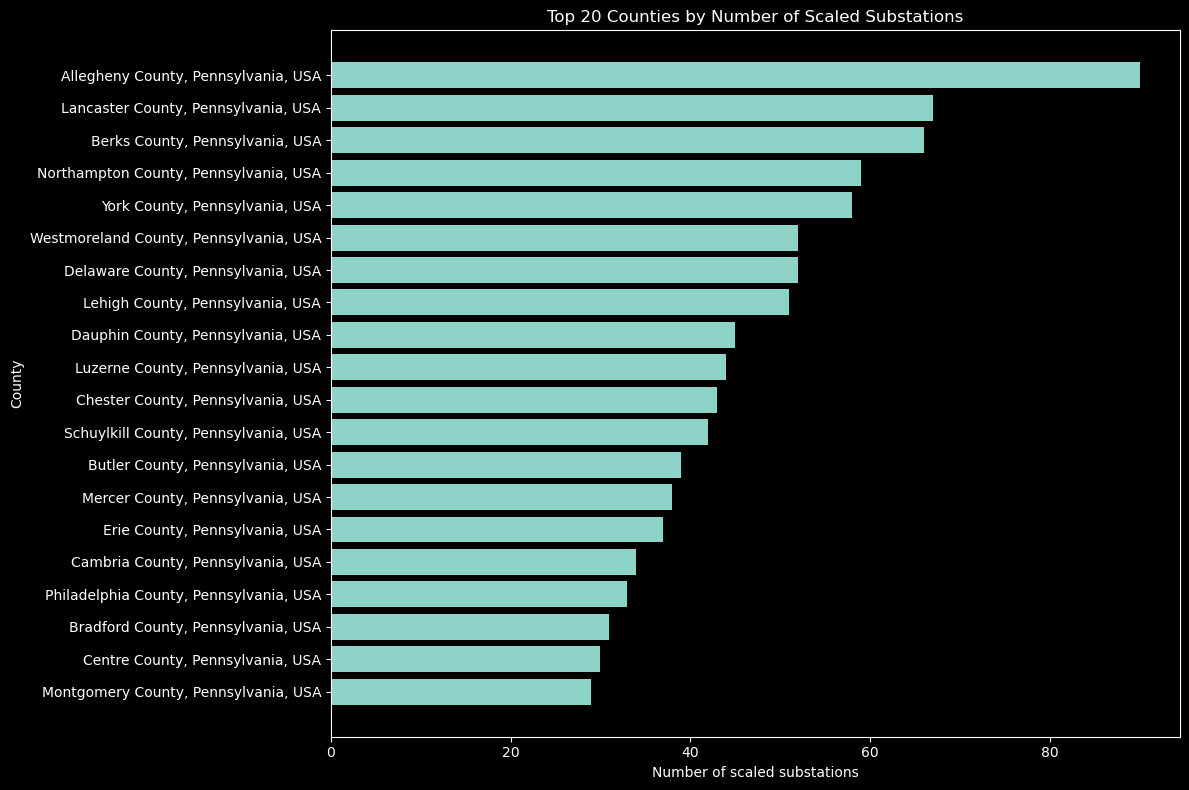

In [129]:
county_scaled_df = (
    composite_df.assign(is_scaled=composite_df["q_sub_scaled"].notna())
    .groupby("county_name", as_index=False)
    .agg(
        n_substations=("OBJECTID", "size"),
        n_scaled=("is_scaled", "sum")
    )
)

county_scaled_df["county_name"] = county_scaled_df["county_name"].fillna("Unknown county")
county_scaled_df = county_scaled_df.sort_values("n_scaled", ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(county_scaled_df["county_name"][::-1], county_scaled_df["n_scaled"][::-1])
plt.title("Top 20 Counties by Number of Scaled Substations")
plt.xlabel("Number of scaled substations")
plt.ylabel("County")
plt.tight_layout()
plt.show()

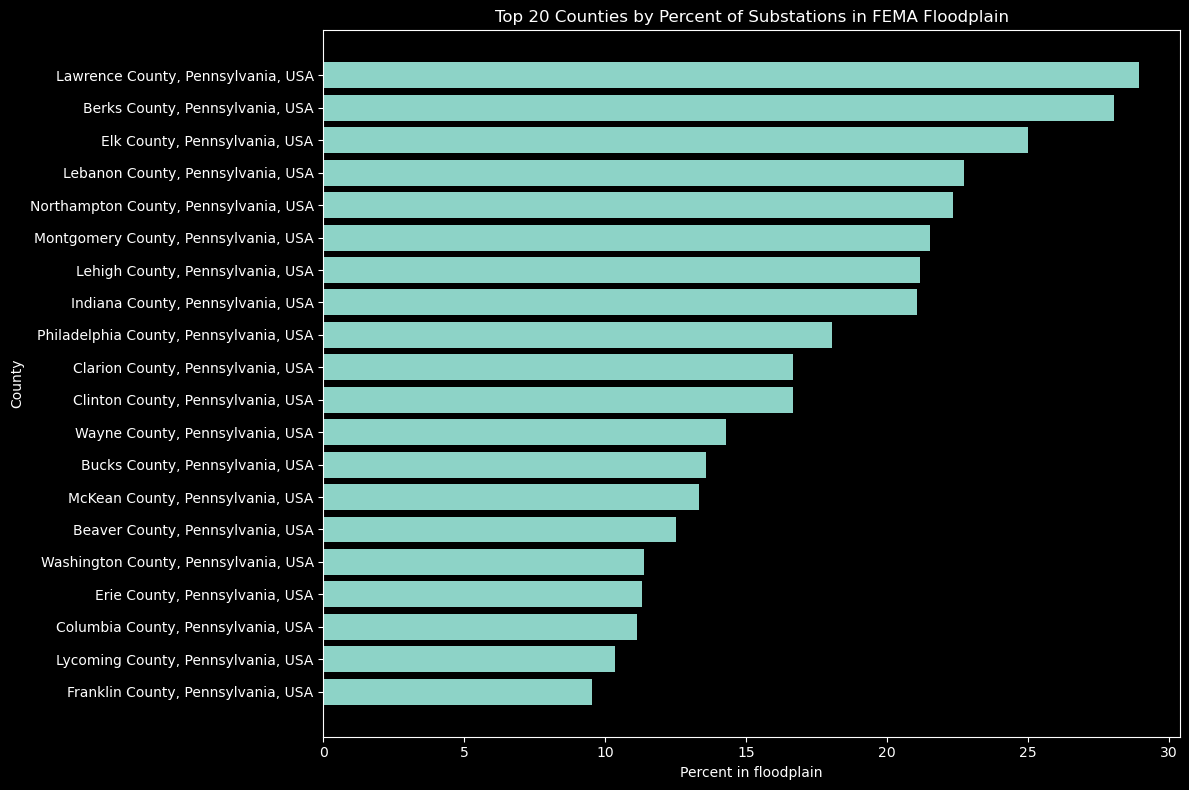

In [130]:
county_flood_df = (
    composite_df.groupby("county_name", as_index=False)
    .agg(
        n_substations=("OBJECTID", "size"),
        n_in_floodplain=("fld_join_count", lambda x: (x.fillna(0) > 0).sum())
    )
)

county_flood_df["county_name"] = county_flood_df["county_name"].fillna("Unknown county")
county_flood_df = county_flood_df.loc[county_flood_df["n_substations"] >= 10].copy()
county_flood_df["pct_in_floodplain"] = 100 * county_flood_df["n_in_floodplain"] / county_flood_df["n_substations"]
county_flood_df = county_flood_df.sort_values("pct_in_floodplain", ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(county_flood_df["county_name"][::-1], county_flood_df["pct_in_floodplain"][::-1])
plt.title("Top 20 Counties by Percent of Substations in FEMA Floodplain")
plt.xlabel("Percent in floodplain")
plt.ylabel("County")
plt.tight_layout()
plt.show()

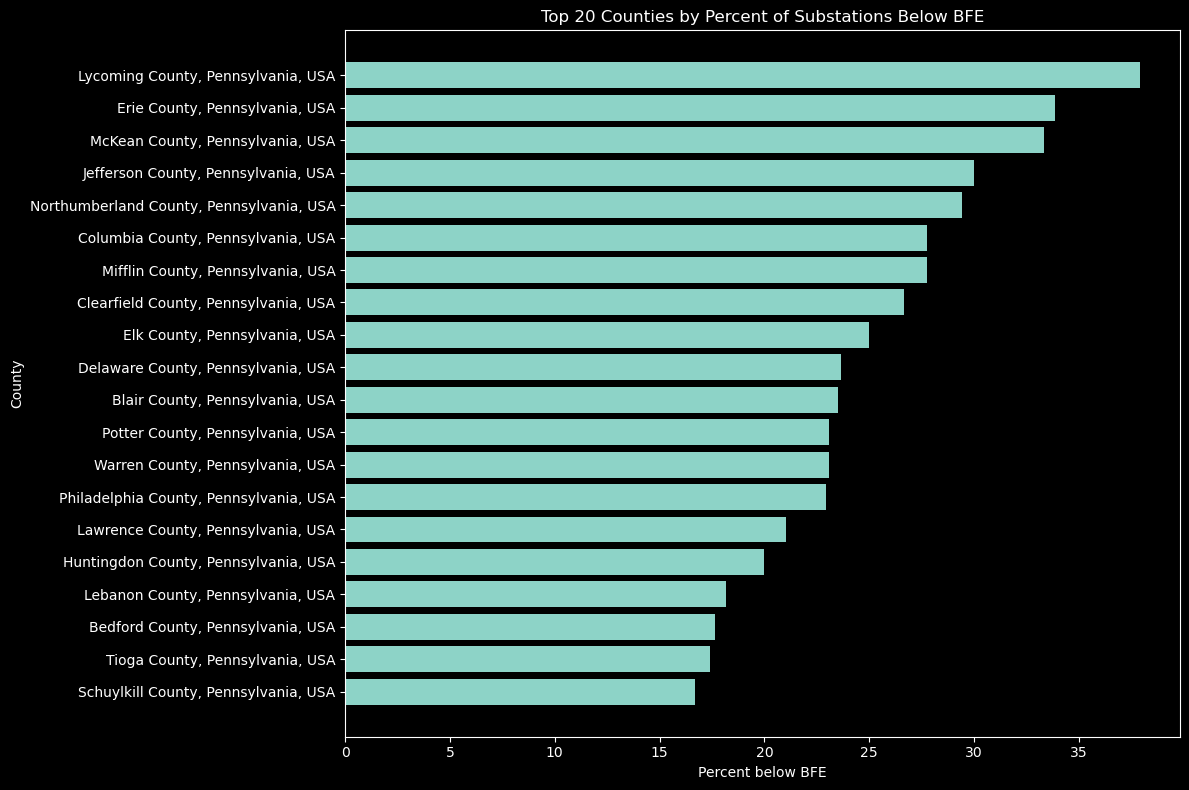

In [131]:
county_bfe_df = (
    composite_df.groupby("county_name", as_index=False)
    .agg(
        n_substations=("OBJECTID", "size"),
        n_below_bfe=("bfe_flag", lambda x: (x == "below_bfe").sum())
    )
)

county_bfe_df["county_name"] = county_bfe_df["county_name"].fillna("Unknown county")
county_bfe_df = county_bfe_df.loc[county_bfe_df["n_substations"] >= 10].copy()
county_bfe_df["pct_below_bfe"] = 100 * county_bfe_df["n_below_bfe"] / county_bfe_df["n_substations"]
county_bfe_df = county_bfe_df.sort_values("pct_below_bfe", ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(county_bfe_df["county_name"][::-1], county_bfe_df["pct_below_bfe"][::-1])
plt.title("Top 20 Counties by Percent of Substations Below BFE")
plt.xlabel("Percent below BFE")
plt.ylabel("County")
plt.tight_layout()
plt.show()

### Candidate 

  chosen_rank_dist  n_substations
0          Missing           1163
1                1            895
2                2            170
3                3            105


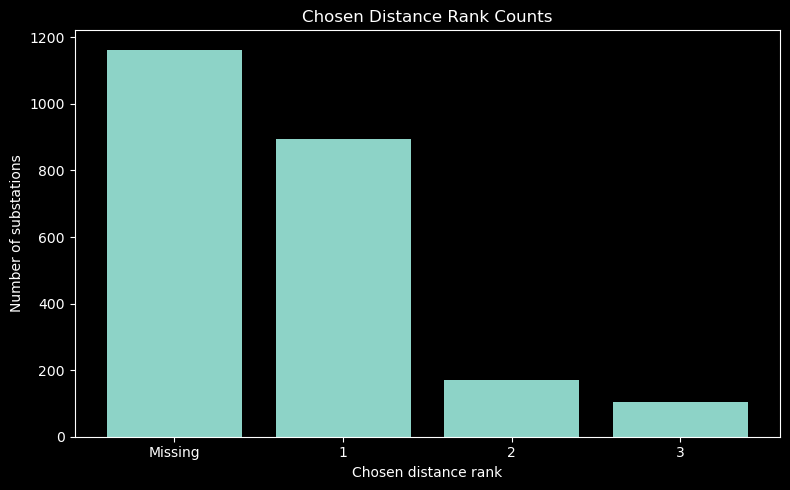

In [132]:
chosen_rank_dist_df = (
    composite_df["chosen_rank_dist"]
    .fillna(-1)
    .astype(int)
    .replace({-1: "Missing"})
    .value_counts()
    .rename_axis("chosen_rank_dist")
    .reset_index(name="n_substations")
)

print(chosen_rank_dist_df)

plt.figure(figsize=(8, 5))
plt.bar(chosen_rank_dist_df["chosen_rank_dist"].astype(str), chosen_rank_dist_df["n_substations"])
plt.title("Chosen Distance Rank Counts")
plt.xlabel("Chosen distance rank")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

  chosen_rank_tdas  n_substations
0          Missing           1163
1                1           1009
2                2             82
3                3             79


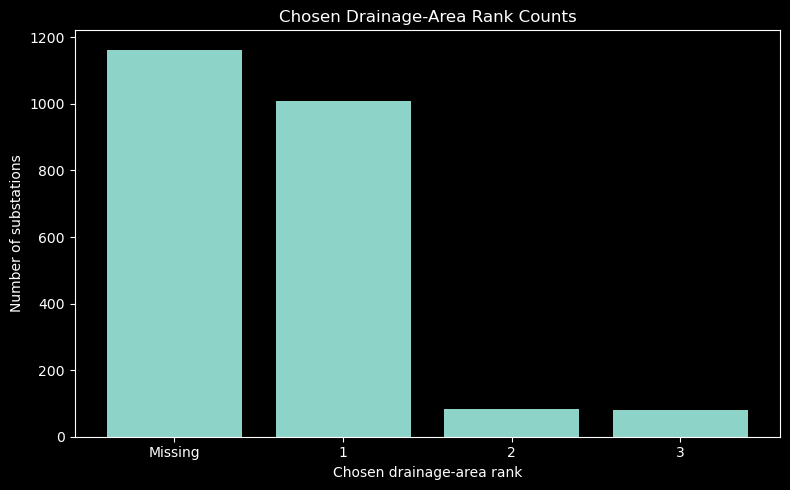

In [133]:
chosen_rank_tdas_df = (
    composite_df["chosen_rank_tdas"]
    .fillna(-1)
    .astype(int)
    .replace({-1: "Missing"})
    .value_counts()
    .rename_axis("chosen_rank_tdas")
    .reset_index(name="n_substations")
)

print(chosen_rank_tdas_df)

plt.figure(figsize=(8, 5))
plt.bar(chosen_rank_tdas_df["chosen_rank_tdas"].astype(str), chosen_rank_tdas_df["n_substations"])
plt.title("Chosen Drainage-Area Rank Counts")
plt.xlabel("Chosen drainage-area rank")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

      chosen_rule  n_substations
0         Missing           1163
1     hybrid_maxq           1007
2  hybrid_nearest            163


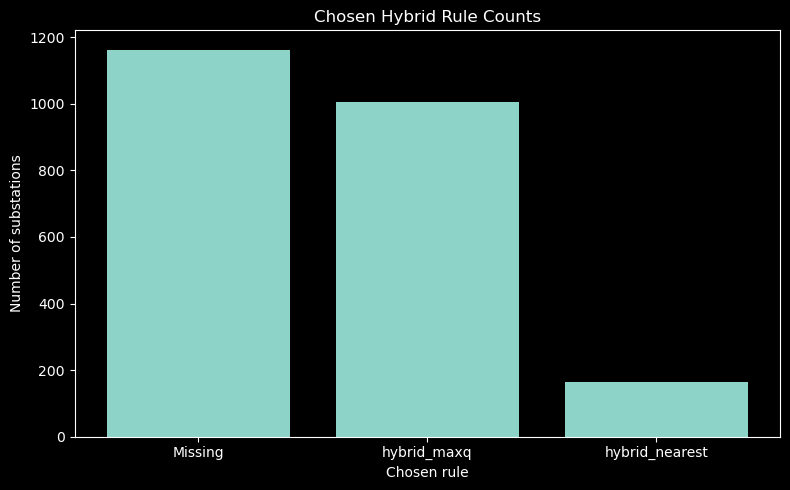

In [134]:
chosen_rule_df = (
    composite_df["chosen_rule"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("chosen_rule")
    .reset_index(name="n_substations")
)

print(chosen_rule_df)

plt.figure(figsize=(8, 5))
plt.bar(chosen_rule_df["chosen_rule"], chosen_rule_df["n_substations"])
plt.title("Chosen Hybrid Rule Counts")
plt.xlabel("Chosen rule")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.show()

In [135]:
report_top_scaled_df = (
    composite_df.loc[composite_df["q_sub_scaled"].notna(), [
        "OBJECTID", "county_name", "name", "operator", "substation",
        "q_sub_scaled", "emp_exceed", "emp_retper", "match_steps",
        "source_gnis", "source_reach", "chosen_rule",
        "chosen_rank_dist", "chosen_rank_tdas"
    ]]
    .sort_values("q_sub_scaled", ascending=False)
    .head(25)
)

report_top_flowlines_df = (
    flowline_summary_df[[
        "chosen_flow_oid", "chosen_flow_gnis", "chosen_flow_tdas",
        "n_substations", "n_scaled", "mean_scaled_q", "max_scaled_q"
    ]]
    .head(25)
)

print("Top scaled substations:")
print(report_top_scaled_df)

print("\nTop chosen flowlines by drainage area:")
print(report_top_flowlines_df)

Top scaled substations:
      OBJECTID                             county_name  \
1996      1997       Luzerne County, Pennsylvania, USA   
1997      1998       Luzerne County, Pennsylvania, USA   
1992      1993      Sullivan County, Pennsylvania, USA   
1297      1298     Allegheny County, Pennsylvania, USA   
1263      1264         Bucks County, Pennsylvania, USA   
1469      1470        Lehigh County, Pennsylvania, USA   
1448      1449        Lehigh County, Pennsylvania, USA   
1465      1466        Lehigh County, Pennsylvania, USA   
1452      1453        Lehigh County, Pennsylvania, USA   
1473      1474        Lehigh County, Pennsylvania, USA   
437        438    Montgomery County, Pennsylvania, USA   
457        458  Philadelphia County, Pennsylvania, USA   
2248      2249          Erie County, Pennsylvania, USA   
2249      2250          Erie County, Pennsylvania, USA   
2250      2251          Erie County, Pennsylvania, USA   
254        255      Franklin County, Pennsylvani